# Neural decoding of ultrasonic call types in mouse mPFC

**Question.** A male mouse meeting a female produces ultrasonic vocalizations (USVs)
that differ in duration and frequency modulation. We ask whether mPFC population
activity *in the moments before a call* carries information about which acoustic
call type the animal is about to produce.

There is no ground-truth call-type label for mice, so the target is built in two
steps: acoustic categories are first defined from the audio alone by clustering,
and the neural model is then asked to predict those categories from spike counts.

**Pipeline.**

| § | stage |
|---|---|
| 1 | Setup and configuration |
| 2 | Sessions: loading and inventory |
| 3 | Time alignment between the audio and neural clocks |
| 4 | Bout segmentation |
| 5 | Background noise and the cleaning strategy |
| 6 | Acoustic feature extraction and quality control |
| 7 | Feature-set selection |
| 8 | Clustering: K-Means vs. GMM, and the choice of K |
| 9 | What the clusters are |
| 10 | Building the neural design matrix |
| 11 | Evaluation protocol and model selection |
| 12 | Positive controls |
| 13 | Significance and robustness |
| 14 | Summary and limitations |
| 15 | Appendix (A1-A7) |

Every stage below states the decision it makes, makes it from a number computed in
the notebook, and carries that decision forward. Nothing is hard-coded from a
previous run.

## 1. Setup and configuration

All tunable choices live in the single cell below and are read from there
everywhere else, so the printed text and what actually runs can never disagree.

In [212]:
from __future__ import annotations

import collections
import hashlib
import itertools
import json
import time
import warnings
import wave
from dataclasses import dataclass
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from scipy import signal, stats
from scipy.io import loadmat

from sklearn.base import clone
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, adjusted_rand_score,
                             calinski_harabasz_score, confusion_matrix,
                             davies_bouldin_score, f1_score, silhouette_score)
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")
%matplotlib inline

In [213]:
# ----------------------------------------------------------------- paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MAT_DIR   = PROJECT_ROOT / "data"
WAV_DIR   = PROJECT_ROOT / "vocal_data"
OUT_DIR   = PROJECT_ROOT / "outputs"
FIG_DIR   = OUT_DIR / "figures"
CACHE_DIR = OUT_DIR / "cache"
for d in (OUT_DIR, FIG_DIR, CACHE_DIR):
    d.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 0

# ----------------------------------------------------------------- audio
SR_EXPECTED    = 250_000        # verified per file in §2
USV_LOW_HZ     = 30_000         # USV band; everything outside is filtered out
USV_HIGH_HZ    = 110_000
STFT_FRAME_MS  = 2.0            # -> 500 Hz frequency resolution at 250 kHz
STFT_HOP_MS    = 0.5            # -> 0.5 ms time resolution

# Background spectrum estimated from short windows that contain no call.
N_QUIET_WINDOWS         = 15
QUIET_WINDOW_S          = 1.0
QUIET_EXCLUSION_MARGIN_S = 0.25
BACKGROUND_SMOOTH_HZ     = 2000.0
STATIC_PEAK_Z            = 6.0   # robust z-score for calling a spectral line "static"
MAX_STATIC_PEAKS         = 5

# Per-call search and ridge tracking. Thresholds are multiples of each session's
# own quiet-period statistics, never absolute power values.
CALL_SEARCH_HALF_WIN_S     = 0.08
CALL_ANCHOR_SEARCH_RADIUS_S = 0.04
CALL_HIGH_THR_MULT   = 2.5
CALL_FLOOR_THR_MULT  = 0.6
CALL_MAX_FREQ_JUMP_KHZ = 8.0
CALL_MAX_STRIKES     = 5
CALL_MAX_DURATION_S  = 0.2
CALL_MIN_DURATION_MS = 3.0
CALL_MIN_CONTOUR_PTS = 4
CALL_SNR_FRAC_MULT   = 1.5
CALL_LOW_SNR_FRAC    = 0.3
NOISE_REF_MARGIN_BEFORE_FIRST_CALL_S = 20.0
NOISE_REF_MAX_DURATION_S             = 60.0
NOISE_REF_MIN_START_S                = 5.0

# ----------------------------------------------------------------- bouts
# The silence separating two bouts is not fixed here. Section 4 derives it from
# the knee of the bout-count curve over this candidate grid, and the value found
# there is what the rest of the notebook uses.
BOUT_GAP_CANDIDATES = (0.05, 0.075, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40,
                       0.50, 0.60, 0.75, 1.00, 1.25, 1.50, 2.00)
BOUT_GAP_SENSITIVITY = (0.30, 0.40, 0.60)   # decoding re-run at these, appendix A5

# ----------------------------------------------------------------- clustering
FEATURES_FULL = ["duration_ms", "fm_intercept_khz", "fm_slope_khz_per_s",
                 "freq_min_khz", "freq_max_khz"]
FEATURES_CORE = ["duration_ms", "fm_intercept_khz", "fm_slope_khz_per_s"]
COLLINEARITY_R        = 0.80    # feature-set rule, applied before K is chosen (§7)
K_RANGE               = range(2, 8)
N_STABILITY_RESAMPLES = 30
N_CLUSTER_PERMUTATIONS = 200
SNR_TIERS = ((0.60, "high quality only"),
             (CALL_LOW_SNR_FRAC, "analysis threshold"),
             (0.00, "every tracked call"))

# ----------------------------------------------------------------- decoding
LOOK_BACK_S   = 1.0     # neural window ends at call onset
N_BINS        = 2       # sub-bins within that window
LOOK_BACK_SWEEP = ((0.5, 1), (1.0, 2), (2.0, 4))
STATE_WINDOW_S = 0.5    # positive control: window tiling used for call vs. quiet
MIN_EVENTS_FOR_DECODING = 100
CV_SPLITS     = 5
CV_GAP_MARGIN_S = 0.2
N_NULL_SHUFFLES = 1000
DECODING_K_SWEEP = (2, 3, 4)

# Hyperparameters are selected by a nested inner CV on training folds only
# (section 12), never on the folds a reported score comes from.
INNER_CV_SPLITS = 3
PCA_GRID = (5, 10, 20)
PARAM_GRID = {
    "logistic":      {"C": (0.01, 0.1, 1.0, 10.0)},
    "random_forest": {"max_depth": (None, 5, 10)},
    "svm_rbf":       {"C": (0.1, 1.0, 10.0)},
}
PCA_COMPONENTS = 10          # default, replaced by the nested search in section 12

# Appendix A3: cells grouped by recording target. The two animals were implanted
# in different regions, so grouping is by area-name prefix, not the raw label.
PFC_PREFIXES = ("PL", "ILA", "ACAd")

# Appendices A1 and A4
EMBEDDING_NEIGHBORS = 15
TRUSTWORTHINESS_K = 15
MIN_PER_CLASS_FOR_DECODING = 30   # appendix A4 only, never the main analysis

# ----------------------------------------------------------------- caching
# Two slow stages: the pass over the audio, and the permutation/null tests.
# Both are cached to outputs/cache so a re-run of the notebook is quick.
# Set either flag to True (or delete outputs/cache) to recompute from scratch.
RECOMPUTE_FEATURES = True
RECOMPUTE_ANALYSIS = True


def _fingerprint(**params):
    """Short hash of the parameters a cached result depends on. It goes into the
    cache file name, so changing any of them produces a new key and forces a
    recomputation instead of silently returning a result from the old settings."""
    return hashlib.md5(json.dumps(params, sort_keys=True).encode()).hexdigest()[:8]


# The audio pass does not depend on the bout threshold: bout ids are joined on
# afterwards, so section 4 can derive that threshold without invalidating this cache.
AUDIO_HASH = _fingerprint(low=USV_LOW_HZ, high=USV_HIGH_HZ, frame=STFT_FRAME_MS,
                          hop=STFT_HOP_MS, quiet_n=N_QUIET_WINDOWS, quiet_s=QUIET_WINDOW_S,
                          smooth=BACKGROUND_SMOOTH_HZ, half_win=CALL_SEARCH_HALF_WIN_S,
                          high_thr=CALL_HIGH_THR_MULT, floor_thr=CALL_FLOOR_THR_MULT,
                          jump=CALL_MAX_FREQ_JUMP_KHZ, strikes=CALL_MAX_STRIKES,
                          max_dur=CALL_MAX_DURATION_S, min_dur=CALL_MIN_DURATION_MS,
                          min_pts=CALL_MIN_CONTOUR_PTS, snr_mult=CALL_SNR_FRAC_MULT,
                          seed=RANDOM_SEED)


def analysis_hash():
    return _fingerprint(audio=AUDIO_HASH, snr=CALL_LOW_SNR_FRAC, coll=COLLINEARITY_R,
                        ks=list(K_RANGE), bout_gap=round(float(BOUT_GAP_S), 4),
                        look_back=LOOK_BACK_S, n_bins=N_BINS, state=STATE_WINDOW_S,
                        min_events=MIN_EVENTS_FOR_DECODING, splits=CV_SPLITS,
                        gap=CV_GAP_MARGIN_S, shuffles=N_NULL_SHUFFLES, seed=RANDOM_SEED)


BOUT_GAP_S = None        # derived in section 4
ANALYSIS_HASH = None     # set in section 4, once the threshold is known

FEATURES_CACHE = CACHE_DIR / f"acoustic_features_{AUDIO_HASH}.csv"


def cached(name, fn):
    """Run fn() once, store the result, and load it on later runs. The parameter
    fingerprint is part of the file name, so a changed setting can never be served
    from a stale cache."""
    import pickle
    p = CACHE_DIR / f"{name}__{ANALYSIS_HASH}.pkl"
    if p.exists() and not RECOMPUTE_ANALYSIS:
        return pickle.loads(p.read_bytes())
    value = fn()
    p.write_bytes(pickle.dumps(value))
    return value


np.random.seed(RANDOM_SEED)
print(f"project root: {PROJECT_ROOT.name}/   |  seed {RANDOM_SEED}   |  "
      f"audio cache {AUDIO_HASH}")

project root: NeuralScienceProject/   |  seed 0   |  audio cache 0c835d12


In [214]:
# One plotting style for every figure in the notebook.
PALETTE = {
    "cluster": ["#3B6EA5", "#C4622D", "#4E8A6B", "#8A5FA8"],
    "observed": "#C4622D",     # anything measured on the real data
    "null": "#9AA5B1",         # null distributions
    "null_alt": "#5A6470",     # a second null on the same axes
    "muted": "#6B7280",        # reference lines, secondary curves
    "accent": "#3B6EA5",
    "segment": "#4E8A6B",      # detected call segment in a spectrogram
}
LINESTYLES = ["-", "--", "-.", ":"]
MARKERS = ["o", "s", "^", "D", "v", "P", "X"]


def apply_paper_style():
    """Apply a clean report style while keeping all figure text readable."""
    mpl.rcdefaults()
    mpl.rcParams.update({
        "font.size": 8, "axes.labelsize": 8,
        "xtick.labelsize": 7, "ytick.labelsize": 7, "legend.fontsize": 7,
        "font.family": "sans-serif",
        "text.color": "black",
        "axes.labelcolor": "black",
        "axes.titlecolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "legend.labelcolor": "black",
        "axes.edgecolor": "black",
        "lines.linewidth": 1.2, "lines.markersize": 4,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.spines.left": True, "axes.spines.bottom": True,
        "axes.grid": False,
        "figure.dpi": 120, "savefig.dpi": 300,
        "figure.facecolor": "white", "axes.facecolor": "white",
        "savefig.facecolor": "white", "savefig.edgecolor": "none",
        "figure.frameon": False, "legend.frameon": False,
        "figure.constrained_layout.use": True,
    })


def make_readable(fig=None):
    """Force figure titles, labels, ticks, legends, and primary spines to be visible."""
    fig = plt.gcf() if fig is None else fig
    fig.patch.set_facecolor("white")
    for ax in fig.axes:
        ax.xaxis.label.set_color("black")
        ax.yaxis.label.set_color("black")
        ax.title.set_color("black")
        ax.tick_params(axis="both", which="both", colors="black", labelcolor="black")
        for tick_label in list(ax.get_xticklabels()) + list(ax.get_yticklabels()):
            tick_label.set_color("black")
            tick_label.set_visible(True)
        for spine_name in ("left", "bottom"):
            if spine_name in ax.spines:
                ax.spines[spine_name].set_visible(True)
                ax.spines[spine_name].set_color("black")
        legend = ax.get_legend()
        if legend is not None:
            for text in legend.get_texts():
                text.set_color("black")
                text.set_visible(True)
            legend.get_title().set_color("black")
    return fig


def save_fig(fig, name):
    make_readable(fig)
    fig.canvas.draw()

    for ext in ("png", "pdf"):
        fig.savefig(
            FIG_DIR / f"{name}.{ext}",
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.15,
            facecolor="white",
            edgecolor="none"
        )


def cluster_color(i):
    return PALETTE["cluster"][int(i) % len(PALETTE["cluster"])]


def style_for(i):
    """Colour, line style and marker together, so series stay distinguishable
    in greyscale and for colour-blind readers."""
    return dict(color=PALETTE["cluster"][i % len(PALETTE["cluster"])],
                linestyle=LINESTYLES[i % len(LINESTYLES)],
                marker=MARKERS[i % len(MARKERS)])


def label_only(ax, text, loc="upper right", color="black"):
    """Compatibility helper: use a real axes title instead of a label-only legend."""
    title_loc = {"upper left": "left", "upper right": "right"}.get(loc, "center")
    return ax.set_title(text, loc=title_loc, color=color)


# ----------------------------------------------------------------- p-values
def p_floor(n_draws):
    """Smallest p a permutation test with this many draws can return."""
    return 1.0 / (n_draws + 1)


def fmt_p(value, floor=None):
    """Never print a p-value as 0.000. A value at the resolution floor of its
    test is shown as an inequality, and a genuinely tiny value in scientific
    notation, so the two cases cannot be confused."""
    if value is None or (isinstance(value, float) and np.isnan(value)):
        return "n/a"
    if floor is not None and value <= floor + 1e-12:
        return f"<{floor:.4f}"
    if value < 1e-4:
        return f"{value:.2e}"
    return f"{value:.4f}"


def show(df, floor=None, decimals=3):
    """Display a table with p- and q-columns run through `fmt_p`."""
    out = df.copy()
    for c in out.columns:
        if isinstance(c, str) and (c.startswith(("p_", "q_")) or c in ("p", "q")):
            out[c] = out[c].map(lambda v: fmt_p(v, floor))
        elif pd.api.types.is_float_dtype(out[c]):
            out[c] = out[c].round(decimals)
    display(out)


apply_paper_style()


## 2. Sessions: loading and inventory

Each `.mat` file is one recording session and holds `sessionParams` (metadata) and
`data` (the three modalities). Only female-encounter sessions are used: male
encounters contain almost no vocalizations, so they cannot support a call-type
analysis. `M2_Female_4` is left out because it has no matching audio file.

Two modalities are used here. The neural side is `spikeCounts100ms` — spike counts
per cell in 100 ms windows, already aligned frame-by-frame to the video/DLC time
axis. The audio side is the raw `.wav` plus `vocalizationTimes`, the detected call
onsets. DLC tracking is not used as a model input.

In [162]:
@dataclass(frozen=True)
class SessionSpec:
    label: str
    mat_filename: str
    wav_filename: str

    @property
    def mat_path(self): return MAT_DIR / self.mat_filename

    @property
    def wav_path(self): return WAV_DIR / self.wav_filename


SESSION_SPECS = [
    SessionSpec("M2_F1", "M2_Female_1.mat", "M2_prb4_Free_Female1_usv.wav"),
    SessionSpec("M2_F2", "M2_Female_2.mat", "M2_prb4_Free_Female2_usv.wav"),
    SessionSpec("M2_F3", "M2_Female_3.mat", "M2_prb4_Free_Female3_usv.wav"),
    SessionSpec("M3_F1", "M3_Female_1.mat", "M3_prb5_Free_Female1_usv.wav"),
    SessionSpec("M3_F2", "M3_Female_2.mat", "M3_prb5_Free_Female2_usv.wav"),
    SessionSpec("M3_F3", "M3_Female_3.mat", "M3_prb5_Free_Female3_usv.wav"),
    SessionSpec("M3_F4", "M3_Female_4.mat", "M3_prb5_Free_Female4_usv.wav"),
    SessionSpec("M6_F1", "M6_Female_1.mat", "M6_prb7_Free_Female1_usv.wav"),
    SessionSpec("M7_F1", "M7_Female_1.mat", "M7_Prb7_Freefemale1_usv.wav"),
    SessionSpec("M7_F2", "M7_Female_2.mat", "M7_Prb7_FreeFemale2_usv.wav"),
    SessionSpec("M7_F3", "M7_Female_3.mat", "M7_Prb7_FreeFemale3_usv.wav"),
    SessionSpec("M7_F4", "M7_Female_4.mat", "M7_Prb7_FreeFemale4_usv.wav"),
    SessionSpec("M8_F1", "M8_Female_1.mat", "M8_Prb8_FreeFemale1_usv.wav"),
    SessionSpec("M8_F2", "M8_Female_2.mat", "M8_Prb8_FreeFemale2_usv.wav"),
    SessionSpec("M8_F3", "M8_Female_3.mat", "M8_Prb8_FreeFemale3_usv.wav"),
    SessionSpec("M8_F4", "M8_Female_4.mat", "M8_Prb8_FreeFemale4_usv.wav"),
]

missing = [f"{s.label}: {p}" for s in SESSION_SPECS
           for p in (s.mat_path, s.wav_path) if not p.exists()]
if missing:
    raise FileNotFoundError("missing files:\n  " + "\n  ".join(missing))
print(f"{len(SESSION_SPECS)} sessions, all .mat and .wav files present")

16 sessions, all .mat and .wav files present


In [163]:
@dataclass
class Session:
    label: str
    mouse: str
    stim: str
    index: int
    voc_sync_time: float          # s; offset between the two clocks (see §3)
    call_times: np.ndarray        # call onsets on the neural/DLC clock, sorted
    spikes: np.ndarray            # cells x frames, spikeCounts100ms
    frame_t: np.ndarray           # s, neural/DLC clock; one entry per frame
    cell_area: np.ndarray
    wav_path: Path
    sr: int
    wav_duration_s: float


def wav_info(path):
    with wave.open(str(path), "rb") as w:
        return w.getframerate(), w.getnframes()


def load_session(spec: SessionSpec) -> Session:
    m = loadmat(spec.mat_path, squeeze_me=True, struct_as_record=False)
    sp, d = m["sessionParams"], m["data"]
    ct = np.atleast_1d(d.vocalizationTimes).astype(float)
    ct = np.sort(ct[~np.isnan(ct)])
    sr, n_samples = wav_info(spec.wav_path)
    return Session(
        label=spec.label, mouse=str(sp.mouse), stim=str(sp.stim), index=int(sp.index),
        voc_sync_time=float(sp.vocSyncTime), call_times=ct,
        spikes=np.asarray(d.spikeCounts100ms, dtype=float),
        frame_t=np.asarray(d.dlcData.t, dtype=float),
        cell_area=np.atleast_1d(d.cells.brainArea),
        wav_path=spec.wav_path, sr=sr, wav_duration_s=n_samples / sr,
    )


sessions = {s.label: load_session(s) for s in SESSION_SPECS}

inventory = pd.DataFrame([dict(
    session=s.label, mouse=s.mouse, stim=s.stim, index=s.index,
    n_calls=len(s.call_times), n_cells=s.spikes.shape[0], n_frames=s.spikes.shape[1],
    rec_min=round(s.frame_t[-1] / 60, 1), wav_min=round(s.wav_duration_s / 60, 1),
    sr_khz=s.sr // 1000, voc_sync_s=round(s.voc_sync_time, 3),
) for s in sessions.values()])
display(inventory)

print(f"\n{inventory['n_calls'].sum()} calls over {len(inventory)} sessions, "
      f"{inventory['mouse'].nunique()} mice.")
print("calls per mouse: " + ", ".join(
    f"{m} {n}" for m, n in inventory.groupby("mouse")["n_calls"].sum().items()))
assert set(inventory["sr_khz"]) == {SR_EXPECTED // 1000}, "unexpected sample rate"

,session,mouse,stim,index,n_calls,n_cells,n_frames,rec_min,wav_min,sr_khz,voc_sync_s
0,M2_F1,M2,Female,1,14,114,27169,15.1,16.0,250,5.05
1,M2_F2,M2,Female,2,8,136,26957,14.9,16.0,250,0.82
2,M2_F3,M2,Female,3,0,118,27468,15.2,16.0,250,5.78
3,M3_F1,M3,Female,1,0,68,27159,15.1,16.0,250,7.05
4,M3_F2,M3,Female,2,2,63,26132,14.5,16.0,250,2.80
5,M3_F3,M3,Female,3,0,62,26800,14.9,15.3,250,5.68
6,M3_F4,M3,Female,4,5,68,26967,15.0,15.3,250,4.47
7,M6_F1,M6,Female,1,32,233,27104,15.0,15.8,250,1.01
8,M7_F1,M7,Female,1,779,166,27281,15.1,14.2,250,1.65
9,M7_F2,M7,Female,2,941,177,26981,15.0,15.0,250,1.90



3984 calls over 16 sessions, 5 mice.
calls per mouse: M2 22, M3 7, M6 32, M7 2979, M8 944


## 3. Time alignment between the audio and neural clocks

Two clocks are involved. Spike counts and DLC frames share one time axis; the raw
`.wav` file has its own. `vocalizationTimes` is given on the **neural/DLC clock**,
and `vocSyncTime` — a per-session constant in `sessionParams` — is the offset
between them:

$$t_{\text{audio}} = t_{\text{DLC}} + \text{vocSyncTime}, \qquad
  t_{\text{DLC}} = t_{\text{audio}} - \text{vocSyncTime}$$

The offset matters only when audio is read back from the `.wav` for a call whose
time is known on the neural clock. Spike counts need no further alignment: they are
already one column per DLC frame.

Getting the sign wrong would silently extract audio from the wrong place and every
acoustic feature downstream would be noise, so the convention is tested rather than
assumed. For each session we measure the USV-band energy in a short window centred
on each call time under three alignment conventions — the correct one, no offset at
all, and the sign flipped — and compare it against energy at randomly drawn control
times. If the convention is right, only the correct one should show call energy far
above control.

In [164]:
def read_wav_window(path, t0_audio, dur_s):
    """Read `dur_s` of raw audio starting at `t0_audio` on the audio clock.
    Seeks directly; the 850 s files are never loaded whole. Clamps at file edges."""
    with wave.open(str(path), "rb") as w:
        sr, n = w.getframerate(), w.getnframes()
        start = min(max(0, int(round(t0_audio * sr))), n)
        n_read = max(0, min(int(round(dur_s * sr)), n - start))
        w.setpos(start)
        raw = w.readframes(n_read)
    return np.frombuffer(raw, dtype=np.int16).astype(float), sr


def dlc_to_audio(t_dlc, voc_sync_time):
    return t_dlc + voc_sync_time


def read_audio_at_call(session, call_time_dlc, half_win_s):
    """Audio window centred on a call time given on the neural clock."""
    centre = dlc_to_audio(call_time_dlc, session.voc_sync_time)
    return read_wav_window(session.wav_path, centre - half_win_s, 2 * half_win_s)


def bandpass(x, sr, low=USV_LOW_HZ, high=USV_HIGH_HZ):
    sos = signal.butter(4, [low, high], btype="band", fs=sr, output="sos")
    return signal.sosfiltfilt(sos, x)


def band_spectrogram(x, sr, frame_ms=STFT_FRAME_MS, hop_ms=STFT_HOP_MS):
    nperseg = max(8, int(round(frame_ms / 1000 * sr)))
    hop = max(1, int(round(hop_ms / 1000 * sr)))
    f, t, S = signal.spectrogram(x, fs=sr, nperseg=nperseg,
                                 noverlap=nperseg - hop, mode="psd")
    band = (f >= USV_LOW_HZ) & (f <= USV_HIGH_HZ)
    return t, f[band] / 1000.0, S[band]

In [165]:
def band_energy_at(session, times_dlc, offset_s, half_win_s=0.02):
    """Median peak in-band power in a window centred on each time, using
    `t_audio = t_dlc + offset_s` as the alignment convention."""
    vals = []
    for t in times_dlc:
        x, sr = read_wav_window(session.wav_path, t + offset_s - half_win_s, 2 * half_win_s)
        if len(x) < 256:
            continue
        f, P = signal.welch(x, fs=sr, nperseg=min(1024, len(x)))
        band = (f >= USV_LOW_HZ) & (f <= USV_HIGH_HZ)
        vals.append(P[band].max())
    return float(np.median(vals)) if vals else np.nan


def compute_sync_check():
    rng = np.random.default_rng(RANDOM_SEED)
    rows = []
    for s in sessions.values():
        if len(s.call_times) < 20:
            continue
        calls = rng.choice(s.call_times, size=min(120, len(s.call_times)), replace=False)
        # control times: drawn inside the encounter, at least 0.25 s from any call
        lo, hi = s.call_times.min(), s.call_times.max()
        ctrl = []
        while len(ctrl) < len(calls):
            t = rng.uniform(lo, hi)
            if np.min(np.abs(s.call_times - t)) > 0.25:
                ctrl.append(t)
        base = band_energy_at(s, np.array(ctrl), s.voc_sync_time)
        rows.append(dict(
            session=s.label, voc_sync_s=s.voc_sync_time,
            correct=band_energy_at(s, calls, +s.voc_sync_time) / base,
            no_offset=band_energy_at(s, calls, 0.0) / base,
            sign_flipped=band_energy_at(s, calls, -s.voc_sync_time) / base,
        ))
    return pd.DataFrame(rows)


sync_check = cached("sync_check", compute_sync_check)
show(sync_check, decimals=2)

sync_wins = ((sync_check["correct"] > sync_check["no_offset"])
             & (sync_check["correct"] > sync_check["sign_flipped"]))
print(f"\nCall-to-control energy ratio, median across sessions: "
      f"correct convention {sync_check['correct'].median():.1f}x, "
      f"no offset {sync_check['no_offset'].median():.1f}x, "
      f"sign flipped {sync_check['sign_flipped'].median():.1f}x.")
print(f"The documented convention gives the highest ratio in {sync_wins.sum()}/"
      f"{len(sync_wins)} sessions.")
if sync_wins.all():
    print("Alignment convention confirmed on every session; used everywhere below.")
else:
    print("WARNING: the convention does not win in every session -- inspect the "
          "sessions above before trusting their acoustic features.")

,session,voc_sync_s,correct,no_offset,sign_flipped
0,M6_F1,1.01,80.42,1.04,1.04
1,M7_F1,1.65,7.18,1.08,1.07
2,M7_F2,1.90,4.93,1.05,1.02
3,M7_F3,1.02,4.99,1.18,1.15
4,M7_F4,4.33,83.66,1.07,1.05
5,M8_F2,2.62,3.60,1.05,1.05
6,M8_F3,0.20,3.05,1.09,1.04
7,M8_F4,1.01,4.11,1.01,0.99



Call-to-control energy ratio, median across sessions: correct convention 5.0x, no offset 1.1x, sign flipped 1.0x.
The documented convention gives the highest ratio in 8/8 sessions.
Alignment convention confirmed on every session; used everywhere below.


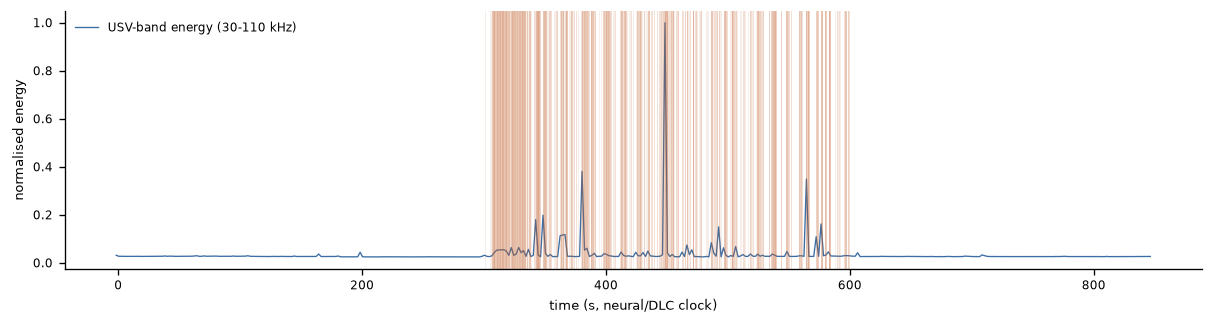

M7_F1: vertical lines are detected call times; the encounter runs 301-599 s, which is exactly where the ultrasonic energy is. Everything before that is the pre-encounter baseline.


In [166]:
# Sanity figure: USV-band energy over one session with call times overlaid.
def usv_band_envelope(session, win_s=1.0, hop_s=2.0):
    times, power, pos = [], [], 0.0
    while pos + win_s <= session.wav_duration_s:
        x, sr = read_wav_window(session.wav_path, pos, win_s)
        f, P = signal.welch(x, fs=sr, nperseg=min(4096, len(x)))
        band = (f >= USV_LOW_HZ) & (f <= USV_HIGH_HZ)
        power.append(P[band].mean()); times.append(pos); pos += hop_s
    return np.array(times), np.array(power)

_s = sessions["M7_F1"]
t_audio_env, p_env = usv_band_envelope(_s)
t_dlc_env = t_audio_env - _s.voc_sync_time

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.plot(t_dlc_env, p_env / p_env.max(), color=PALETTE["accent"], lw=0.8,
        label="USV-band energy (30-110 kHz)")
for ct in _s.call_times:
    ax.axvline(ct, color=PALETTE["observed"], alpha=0.10, lw=0.6)
ax.set_xlabel("time (s, neural/DLC clock)")
ax.set_ylabel("normalised energy")
ax.legend(loc="upper left")
save_fig(fig, "01_sync_check")
plt.show()
print(f"{_s.label}: vertical lines are detected call times; the encounter runs "
      f"{_s.call_times.min():.0f}-{_s.call_times.max():.0f} s, which is exactly where "
      f"the ultrasonic energy is. Everything before that is the pre-encounter baseline.")

## 4. Bout segmentation

Mice do not call at a steady rate: calls arrive in short trains separated by
longer silences. Two things downstream depend on this. Calls inside one train
share the neural window that precedes them and tend to be acoustically similar,
so they must never be split across training and test folds. And the length of a
train describes the vocal episode.

A bout is a run of calls in which no two consecutive calls are separated by more
than `gap_s` seconds of silence. The threshold is derived below rather than
chosen, and the derivation starts by ruling out the textbook justification.

**There is no natural threshold in this data, and that has to be said first.**
The usual argument for a bout threshold is that inter-call intervals are
bimodal — a mode of short within-train gaps, a mode of long between-train gaps,
and a low-density valley in between to cut at. The pooled interval distribution
here, on a log scale, has a **single** mode and no valley. Any threshold is
therefore a convention, not a boundary the data hands over.

What remains is to pick the convention defensibly. Below a certain silence the
segmentation collapses — almost every call becomes its own bout and the grouping
carries no information. The bout count falls steeply through that regime and
then flattens. The knee of that curve, located as the point of greatest
perpendicular distance from the chord joining its two ends, is the value used,
and it is computed here rather than typed in. Appendix A5 then re-runs the
decoding at thresholds on either side of it to show the conclusions do not
depend on the choice.

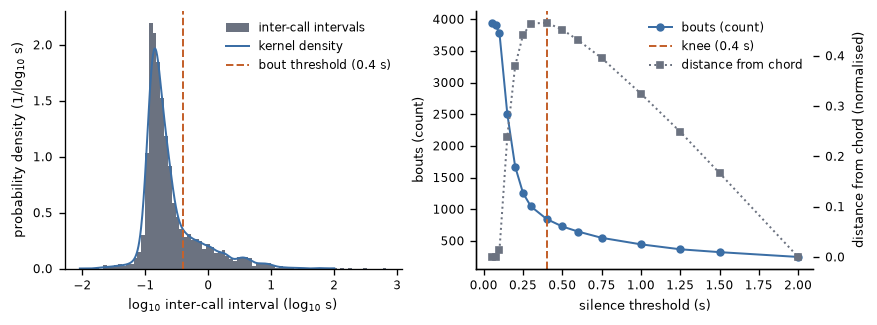

,gap_s,n_bouts,knee_distance
0,0.050,3945,0.000
1,0.075,3902,0.001
2,0.100,3782,0.013
3,0.150,2504,0.239
4,0.200,1672,0.380
5,0.250,1255,0.442
6,0.300,1044,0.464
7,0.400,845,0.466
8,0.500,727,0.452
9,0.600,647,0.431


Inter-call intervals, pooled over sessions: 1 density peak(s) at 0.14 s; 0 valley(s).
A single mode and no valley: the distribution offers no natural cut point, so the threshold below is a convention chosen for stability, not a boundary read off the data.

Knee of the bout-count curve: 0.4 s. Below it the count falls from 3945 bouts at 0.05 s to 1255 at 0.25 s; above it the curve flattens toward 246 at 2 s.
79% of all inter-call intervals fall below this threshold, i.e. that fraction of consecutive call pairs is assigned to the same bout.

Analysis cache fingerprint for this threshold: d51a2ea1


In [221]:
def compute_ici(call_times):
    return np.diff(np.sort(np.asarray(call_times, dtype=float)))


def label_calls_by_bout(call_times, gap_s):
    """Per-call bout id, aligned 1:1 with sorted(call_times)."""
    ct = np.sort(np.asarray(call_times, dtype=float))
    if len(ct) == 0:
        return pd.DataFrame(dict(call_time=[], bout_id=[], is_bout_onset=[]))
    starts = np.concatenate(([0], np.where(np.diff(ct) > gap_s)[0] + 1))
    bout_id = np.zeros(len(ct), dtype=int)
    for b, s0 in enumerate(starts):
        bout_id[s0:] = b
    is_onset = np.zeros(len(ct), dtype=bool)
    is_onset[starts] = True
    return pd.DataFrame(dict(call_time=ct, bout_id=bout_id, is_bout_onset=is_onset))


def total_bouts(gap_s):
    return int(sum(1 + int((compute_ici(s.call_times) > gap_s).sum())
                   for s in sessions.values() if len(s.call_times) > 0))


def knee_distance(x, y):
    """Perpendicular distance of each point from the chord joining the first and
    last point, on min-max normalised axes. Its maximum is the knee."""
    x, y = np.asarray(x, float), np.asarray(y, float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y - y.min()) / (y.max() - y.min())
    p1, p2 = np.array([xn[0], yn[0]]), np.array([xn[-1], yn[-1]])
    d = (p2 - p1) / np.linalg.norm(p2 - p1)
    pts = np.column_stack([xn, yn])
    proj = p1 + ((pts - p1) @ d)[:, None] * d
    return np.linalg.norm(pts - proj, axis=1)


ici_pooled = np.concatenate([compute_ici(s.call_times) for s in sessions.values()
                             if len(s.call_times) > 1])
ici_pooled = ici_pooled[ici_pooled > 0]

gaps = np.array(BOUT_GAP_CANDIDATES, dtype=float)
n_bouts = np.array([total_bouts(g) for g in gaps], dtype=float)
dist = knee_distance(gaps, n_bouts)
BOUT_GAP_S = float(gaps[int(np.argmax(dist))])
ANALYSIS_HASH = analysis_hash()

# Is the interval distribution bimodal, as the textbook argument assumes?
log_ici = np.log10(ici_pooled)
kde = stats.gaussian_kde(log_ici, bw_method=0.15)
grid = np.linspace(log_ici.min(), min(log_ici.max(), 2.0), 600)
dens = kde(grid)
kde_peaks, _ = signal.find_peaks(dens, prominence=0.02)
kde_valleys, _ = signal.find_peaks(-dens, prominence=0.02)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.6))

ax = axes[0]
ax.hist(log_ici, bins=80, density=True, color=PALETTE["muted"], edgecolor="none",
        label="inter-call intervals")
ax.plot(grid, dens, color=PALETTE["accent"], linestyle="-", label="kernel density")
ax.axvline(np.log10(BOUT_GAP_S), color=PALETTE["observed"], linestyle="--",
           label=f"bout threshold ({BOUT_GAP_S:g} s)")
ax.set_xlabel("log$_{10}$ inter-call interval (log$_{10}$ s)")
ax.set_ylabel("probability density (1/log$_{10}$ s)")
ax.legend(loc="upper right")

ax = axes[1]
ax.plot(gaps, n_bouts, color=PALETTE["accent"], linestyle="-", marker="o",
        label="bouts (count)")
ax2 = ax.twinx()
ax2.plot(gaps, dist, color=PALETTE["muted"], linestyle=":", marker="s",
         label="distance from chord")
ax2.spines["top"].set_visible(False)
ax.axvline(BOUT_GAP_S, color=PALETTE["observed"], linestyle="--",
           label=f"knee ({BOUT_GAP_S:g} s)")
ax.set_xlabel("silence threshold (s)")
ax.set_ylabel("bouts (count)")
ax2.set_ylabel("distance from chord (normalised)")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right")
save_fig(fig, "02_bout_threshold")
plt.show()

sweep = pd.DataFrame(dict(gap_s=gaps, n_bouts=n_bouts.astype(int),
                          knee_distance=np.round(dist, 3)))
show(sweep)

print(f"Inter-call intervals, pooled over sessions: {len(kde_peaks)} density peak(s) at "
      + ", ".join(f"{10**grid[i]:.2f} s" for i in kde_peaks)
      + f"; {len(kde_valleys)} valley(s)"
      + ("." if len(kde_valleys) == 0 else
         " at " + ", ".join(f"{10**grid[i]:.2f} s" for i in kde_valleys) + "."))
if len(kde_valleys) == 0:
    print("A single mode and no valley: the distribution offers no natural cut point, "
          "so the threshold below is a convention chosen for stability, not a boundary "
          "read off the data.")

print(f"\nKnee of the bout-count curve: {BOUT_GAP_S:g} s. Below it the count falls from "
      f"{int(n_bouts[0])} bouts at {gaps[0]:g} s to {int(n_bouts[len(gaps)//3])} at "
      f"{gaps[len(gaps)//3]:g} s; above it the curve flattens toward "
      f"{int(n_bouts[-1])} at {gaps[-1]:g} s.")
print(f"{(ici_pooled < BOUT_GAP_S).mean():.0%} of all inter-call intervals fall below "
      "this threshold, i.e. that fraction of consecutive call pairs is assigned to the "
      "same bout.")
print(f"\nAnalysis cache fingerprint for this threshold: {ANALYSIS_HASH}")

**Interpretation.** The pooled inter-call-interval distribution has a single mode
and no low-density valley (left panel), so the data offer no natural silence
duration to cut at — any bout threshold is a convention, not a boundary. The
convention adopted is the **knee of the bout-count curve** (right panel): the
silence value past which allowing longer gaps stops merging away many further
bouts, taken as the point of greatest perpendicular distance from the chord
joining the curve's two ends. `BOUT_GAP_S` is set to that knee automatically and
every later stage reads it from there. Its job is to keep temporally dependent
calls — ones that share a look-back window and tend to share a call type — out of
separate cross-validation folds. Appendix A5 re-runs the decoding at neighbouring
thresholds and the conclusion is unchanged.


## 5. Background noise and the cleaning strategy

The recordings contain non-vocal energy inside the USV band: equipment tones,
ventilation, screens, contact with the arena. Acoustic features are read off a
spectrogram, so any stationary line in the band biases them.

The treatment used here is **per-session background subtraction**. Fifteen
one-second windows containing no call are drawn across each recording, a Welch
spectrum is computed for each, and the median across windows gives a background
power spectrum robust to a single contaminated window. That spectrum is smoothed
across frequency, and every call's spectrogram is normalised against the smoothed
version bin by bin, subtracting and clipping at zero.

Being precise about what this does and does not remove, since the two are often
conflated. Smoothing removes narrow spectral lines by construction, so what gets
subtracted is the **broad noise floor**, not the narrow static tones detected
below. The tones are neutralised by a different mechanism: every detection
threshold used by the contour tracker is calibrated on quiet audio that has passed
through the *same* normalisation, so a surviving tone is built into the threshold
itself and a frame containing only that tone cannot clear it. The check printed in
§6 confirms the outcome — calls do not pile up at the tone frequencies.

**What a notch filter is, and why it was the first idea.** A notch filter is a
band-stop that removes a narrow slice of the spectrum around one fixed
frequency, leaving everything else untouched — the standard tool for a steady
electrical or mechanical tone. The obvious first approach here was exactly that:
find the one frequency at which the equipment hums, and remove it from every
recording. It is simple, it is cheap, and it needs only a single number.

That approach was rejected, and the two checks below are what decide it:

1. **Are the contaminating peaks the same across sessions?** If each session has its
   own tone, no single notch frequency can serve all of them, and a notch placed
   inside the range where calls actually live would remove real signal.
2. **Is a peak stationary or is it the call itself?** A peak present at the same
   level whether or not a mouse is calling is background and can be subtracted. A
   peak that appears only around calls is vocal signal, and removing it would be a
   mistake. This is checked by overlaying the quiet-window spectrum with a spectrum
   built the same way from windows centred on real calls.

In [168]:
@dataclass
class Background:
    freqs_khz: np.ndarray
    log_psd: np.ndarray
    log_psd_smooth: np.ndarray
    residual: np.ndarray
    mad: float


def _median_spectrum(wav_path, starts_audio, window_s=QUIET_WINDOW_S,
                     smooth_hz=BACKGROUND_SMOOTH_HZ) -> Background:
    psds, freqs = [], None
    for t0 in starts_audio:
        x, sr = read_wav_window(wav_path, max(0.0, t0), window_s)
        if len(x) < 256:
            continue
        f, P = signal.welch(x, fs=sr, nperseg=min(4096, len(x)))
        band = (f >= USV_LOW_HZ) & (f <= USV_HIGH_HZ)
        freqs = f[band]
        psds.append(P[band])
    if not psds:
        raise RuntimeError(f"no usable windows in {wav_path}")
    log_psd = 10 * np.log10(np.median(np.vstack(psds), axis=0) + 1e-20)
    bin_hz = float(np.median(np.diff(freqs)))
    k = max(3, int(round(smooth_hz / bin_hz)) | 1)
    k = min(k, len(log_psd) if len(log_psd) % 2 == 1 else len(log_psd) - 1)
    smooth = signal.medfilt(log_psd, kernel_size=k)
    resid = log_psd - smooth
    return Background(freqs / 1000.0, log_psd, smooth, resid,
                      float(np.median(np.abs(resid - np.median(resid)))))


def quiet_window_starts(session, n=N_QUIET_WINDOWS, window_s=QUIET_WINDOW_S,
                        margin=QUIET_EXCLUSION_MARGIN_S, seed=RANDOM_SEED):
    calls_audio = dlc_to_audio(session.call_times, session.voc_sync_time)
    r = np.random.default_rng(seed)
    max_start = max(0.0, session.wav_duration_s - window_s)
    starts, tries = [], 0
    while len(starts) < n and tries < n * 200:
        tries += 1
        t0 = float(r.uniform(0, max_start))
        if len(calls_audio) and np.any((calls_audio > t0 - margin) &
                                       (calls_audio < t0 + window_s + margin)):
            continue
        starts.append(t0)
    return starts or [0.0]


def call_window_starts(session, n=N_QUIET_WINDOWS, window_s=QUIET_WINDOW_S, seed=RANDOM_SEED):
    r = np.random.default_rng(seed)
    chosen = r.choice(session.call_times, size=min(n, len(session.call_times)), replace=False)
    return [float(t - window_s / 2) for t in dlc_to_audio(chosen, session.voc_sync_time)]


def estimate_background(session):
    return _median_spectrum(session.wav_path, quiet_window_starts(session))


def estimate_call_spectrum(session):
    return _median_spectrum(session.wav_path, call_window_starts(session))


def detect_static_peaks(bg: Background, label=""):
    mad = bg.mad if bg.mad > 1e-9 else float(np.std(bg.residual) + 1e-9)
    z = bg.residual / (1.4826 * mad)
    peaks, _ = signal.find_peaks(z, height=STATIC_PEAK_Z, prominence=STATIC_PEAK_Z / 2)
    rows = []
    for i in np.argsort(-z[peaks])[:MAX_STATIC_PEAKS]:
        idx = peaks[i]
        rows.append(dict(session=label, peak_khz=round(float(bg.freqs_khz[idx]), 1),
                         z=round(float(z[idx]), 1)))
    return pd.DataFrame(rows, columns=["session", "peak_khz", "z"])


def normalize_spectrogram(S, f_khz, bg: Background):
    """Subtract the interpolated background power per frequency bin, clip at 0.
    Subtraction rather than division: division explodes wherever the background
    estimate is near zero, fabricating loud bins in the quietest part of the band."""
    bg_lin = 10 ** (bg.log_psd_smooth / 10)
    return np.maximum(S - np.interp(f_khz, bg.freqs_khz, bg_lin)[:, None], 0.0)

In [169]:
t0 = time.time()
backgrounds = {lab: estimate_background(s) for lab, s in sessions.items()}
static_peaks = pd.concat([detect_static_peaks(bg, lab) for lab, bg in backgrounds.items()],
                         ignore_index=True)
print(f"background spectra for {len(backgrounds)} sessions in {time.time()-t0:.0f}s\n")
display(static_peaks.pivot_table(index="session", values="peak_khz",
                                 aggfunc=lambda v: ", ".join(f"{x:.1f}" for x in v))
        .rename(columns={"peak_khz": "static peaks (kHz)"}))

_top = static_peaks.sort_values("z", ascending=False).groupby("session").head(1)
_spread = _top["peak_khz"]
print(f"\nStrongest static peak per session ranges {_spread.min():.1f}-{_spread.max():.1f} kHz "
      f"across {len(_top)} sessions ({_spread.nunique()} distinct frequencies). "
      "The contamination is session-specific, so no single notch frequency fits all "
      "sessions, and several of these peaks sit inside the frequency range where the "
      "calls themselves live. Per-session subtraction adapts to each recording instead.")

background spectra for 16 sessions in 42s



,static peaks (kHz)
session,
M2_F1,"65.8, 92.1, 102.7, 51.4, 48.1"
M2_F2,"65.7, 47.9, 59.3"
M2_F3,"67.9, 102.5, 54.6, 48.1"
M3_F2,"67.0, 102.2, 51.8"
M3_F3,"66.8, 63.2, 54.5, 102.4, 51.8"
M3_F4,"68.6, 58.5"
M6_F1,"66.8, 50.4, 103.6, 83.9, 96.1"
M7_F1,"67.0, 104.0, 49.9, 95.9, 46.0"
M7_F2,"50.5, 66.2, 103.6, 64.7, 58.2"



Strongest static peak per session ranges 47.9-68.6 kHz across 15 sessions (11 distinct frequencies). The contamination is session-specific, so no single notch frequency fits all sessions, and several of these peaks sit inside the frequency range where the calls themselves live. Per-session subtraction adapts to each recording instead.


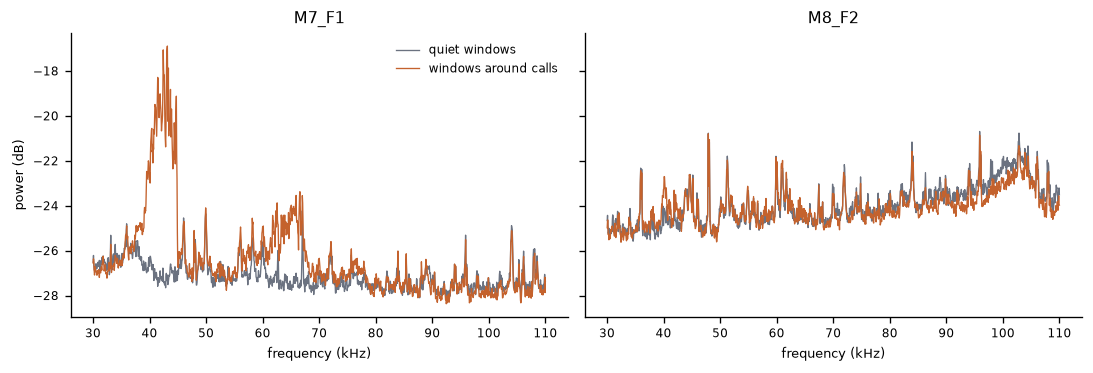

Where the two curves sit on top of each other, the energy is present with or without a call: stationary background, safe to subtract. Where the call curve rises above the quiet curve, that is vocal signal and is left alone by a subtraction that clips at zero.


In [170]:
# Is a detected peak stationary background, or is it the call?
QC_SESSIONS = ["M7_F1", "M8_F2"]
fig, axes = plt.subplots(1, len(QC_SESSIONS), figsize=(9, 3), sharey=True)
for ax, lab in zip(np.atleast_1d(axes), QC_SESSIONS):
    bg, cs = backgrounds[lab], estimate_call_spectrum(sessions[lab])
    ax.plot(bg.freqs_khz, bg.log_psd, color=PALETTE["muted"], lw=0.8, label="quiet windows")
    ax.plot(cs.freqs_khz, cs.log_psd, color=PALETTE["observed"], lw=0.8, label="windows around calls")
    ax.set_title(lab); ax.set_xlabel("frequency (kHz)")
np.atleast_1d(axes)[0].set_ylabel("power (dB)")
np.atleast_1d(axes)[0].legend()
save_fig(fig, "03_background_vs_call_spectrum")
plt.show()
print("Where the two curves sit on top of each other, the energy is present with or "
      "without a call: stationary background, safe to subtract. Where the call curve "
      "rises above the quiet curve, that is vocal signal and is left alone by a "
      "subtraction that clips at zero.")

## 6. Acoustic feature extraction and quality control

A detected call time is only an anchor. Around each anchor we compute a background-
normalised spectrogram, find the call's own energy inside it, and follow its
frequency contour frame by frame; features are then read off that contour, not off
the whole surrounding window.

The contour is found by a ridge tracker. It seeds on the frame nearest the anchor
whose in-band power clearly exceeds the session's quiet-period level, then walks
outwards in both directions for as long as the power stays above a floor and the
peak frequency moves continuously. Both thresholds are multiples of that session's
own quiet-period statistics, because the noise floor differs between recordings.

Features per call: `duration_ms`, the straight-line fit to the contour
(`fm_intercept_khz`, a starting-pitch summary, and `fm_slope_khz_per_s`, the
frequency modulation), the contour's frequency extremes (`freq_min_khz`,
`freq_max_khz`), and descriptive extras kept for QC. Amplitude is deliberately not
a feature: with a single fixed microphone the recorded level depends on where the
animal is and which way it is facing as much as on the call.

Every call gets a row. A call is flagged low quality if the tracker found no
confident anchor, ran into the window edge, hit the duration cap, produced too few
contour points to fit a slope, or spent too little of its length clearly above the
noise floor. Only high-quality calls are clustered and decoded.

In [171]:
@dataclass
class NoiseRef:
    p999: float
    median: float


def estimate_noise_reference(session, background):
    """Peak in-band power statistics from a quiet stretch that ends just before the
    first call. Anchored to the encounter rather than to the start of the file:
    recordings can contain handling noise in the first seconds, which would inflate
    every threshold downstream. The same background normalisation is applied here
    as to the calls, so the multipliers stay meaningful."""
    end_dlc = (session.call_times.min() - NOISE_REF_MARGIN_BEFORE_FIRST_CALL_S
               if len(session.call_times) else session.frame_t.max())
    start_dlc = max(NOISE_REF_MIN_START_S, end_dlc - NOISE_REF_MAX_DURATION_S)
    dur = max(5.0, end_dlc - start_dlc)
    x, sr = read_wav_window(session.wav_path, dlc_to_audio(start_dlc, session.voc_sync_time), dur)
    _, f_khz, S = band_spectrogram(bandpass(x, sr), sr)
    S = normalize_spectrogram(S, f_khz, background)
    e = S.max(axis=0)
    return NoiseRef(p999=float(np.percentile(e, 99.9)), median=float(np.median(e)))


def _track_ridge(e, f_peak, tc, noise: NoiseRef):
    high_thr = CALL_HIGH_THR_MULT * noise.p999
    floor_thr = CALL_FLOOR_THR_MULT * noise.median
    dt = tc[1] - tc[0]
    zero = int(np.argmin(np.abs(tc)))
    radius = int(round(CALL_ANCHOR_SEARCH_RADIUS_S / dt))
    lo_s, hi_s = max(0, zero - radius), min(len(tc), zero + radius + 1)
    cand = np.where(e[lo_s:hi_s] > high_thr)[0]
    if len(cand) == 0:
        return None
    anchor = lo_s + cand[np.argmin(np.abs(cand + lo_s - zero))]
    max_frames = int(round(CALL_MAX_DURATION_S / dt))

    def walk(step):
        i, strikes, last_good = anchor, 0, anchor
        keep = {anchor}
        while abs(i - anchor) < max_frames:
            j = i + step
            if j < 0 or j >= len(e):
                break
            ok = (e[j] > floor_thr) and (abs(f_peak[j] - f_peak[last_good]) <= CALL_MAX_FREQ_JUMP_KHZ)
            if ok:
                last_good, strikes, i = j, 0, j
                keep.add(j)
            else:
                strikes, i = strikes + 1, j
                if strikes > CALL_MAX_STRIKES:
                    break
        return last_good, keep

    hi, keep_hi = walk(+1)
    lo, keep_lo = walk(-1)
    hit_cap = (hi - anchor >= max_frames - 1) or (anchor - lo >= max_frames - 1)
    return dict(lo=lo, hi=hi, good=np.array(sorted(keep_lo | keep_hi)), hit_cap=hit_cap)


_EMPTY = dict(duration_ms=np.nan, peak_freq_khz=np.nan, mean_freq_khz=np.nan,
              bandwidth_khz=np.nan, fm_slope_khz_per_s=np.nan, fm_intercept_khz=np.nan,
              fm_r2=np.nan, freq_min_khz=np.nan, freq_max_khz=np.nan,
              n_contour_points=0, snr_frac=np.nan)


def call_spectrogram(session, call_time, background=None):
    x, sr = read_audio_at_call(session, call_time, CALL_SEARCH_HALF_WIN_S)
    if len(x) < 0.9 * 2 * CALL_SEARCH_HALF_WIN_S * sr:
        return None
    t, f_khz, S = band_spectrogram(bandpass(x, sr), sr)
    if background is not None:
        S = normalize_spectrogram(S, f_khz, background)
    return t - CALL_SEARCH_HALF_WIN_S, f_khz, S


def extract_call_features(session, call_time, noise, background):
    out = call_spectrogram(session, call_time, background)
    if out is None:
        return dict(quality="file_edge", **_EMPTY)
    tc, f_khz, S = out
    e = S.max(axis=0)
    f_peak = f_khz[np.argmax(S, axis=0)]
    seg = _track_ridge(e, f_peak, tc, noise)
    if seg is None:
        return dict(quality="no_anchor", **_EMPTY)

    lo, hi, good = seg["lo"], seg["hi"], seg["good"]
    duration_ms = float((tc[hi] - tc[lo]) * 1000)
    agg = S[:, lo:hi + 1].sum(axis=1)
    w = agg / (agg.sum() + 1e-30)
    mean_f = float((w * f_khz).sum())
    feats = dict(
        duration_ms=duration_ms,
        peak_freq_khz=float(f_khz[np.argmax(agg)]),
        mean_freq_khz=mean_f,
        bandwidth_khz=float(np.sqrt((w * (f_khz - mean_f) ** 2).sum())),
        snr_frac=float(np.mean(e[lo:hi + 1] > CALL_SNR_FRAC_MULT * noise.p999)),
        n_contour_points=len(good),
        fm_slope_khz_per_s=np.nan, fm_intercept_khz=np.nan, fm_r2=np.nan,
        freq_min_khz=np.nan, freq_max_khz=np.nan,
    )

    if len(good) >= CALL_MIN_CONTOUR_PTS:
        ct, cf = tc[good], f_peak[good]
        k = min(3, len(good) if len(good) % 2 == 1 else len(good) - 1)
        cf_s = signal.medfilt(cf, kernel_size=k) if k >= 3 else cf
        slope, intercept = np.polyfit(ct, cf_s, deg=1)
        resid = cf_s - (slope * ct + intercept)
        ss_tot = float(np.sum((cf_s - cf_s.mean()) ** 2))
        feats.update(fm_slope_khz_per_s=float(slope), fm_intercept_khz=float(intercept),
                     fm_r2=float(1 - np.sum(resid ** 2) / ss_tot) if ss_tot > 1e-12 else 1.0,
                     freq_min_khz=float(cf.min()), freq_max_khz=float(cf.max()))

    quality = "ok"
    if seg["hit_cap"]:
        quality = "duration_cap"
    elif lo == 0 or hi == len(tc) - 1:
        quality = "edge_truncated"
    elif duration_ms < CALL_MIN_DURATION_MS:
        quality = "too_short"
    elif len(good) < CALL_MIN_CONTOUR_PTS:
        quality = "too_few_contour_points"
    return dict(quality=quality, **feats)


def plot_call_panel(ax, session, call_time, noise, background, label="",
                    show_contour=True):
    """One call's spectrogram with the tracker's own output drawn on it: the
    nominal onset, the segment the tracker accepted, and the frequency contour
    the features were read from. The colour scale is clipped to the 80th-99.9th
    percentile of the panel so the call stands out of the noise floor instead of
    being flattened by a few very loud bins."""
    out = call_spectrogram(session, call_time, background)
    if out is None:
        ax.axis("off")
        return
    tc, f_khz, S = out
    S_db = 10 * np.log10(S + 1e-12)
    ax.pcolormesh(tc * 1000, f_khz, S_db, shading="auto", cmap="magma",
                  vmin=np.percentile(S_db, 80), vmax=np.percentile(S_db, 99.9))
    handles = []
    ax.axvline(0, color=PALETTE["observed"], lw=1.0)
    handles.append(mpl.lines.Line2D([], [], color=PALETTE["observed"], lw=1.0,
                                    label="nominal onset"))
    if show_contour:
        seg = _track_ridge(S.max(axis=0), f_khz[np.argmax(S, axis=0)], tc, noise)
        if seg is not None:
            lo, hi = seg["lo"], seg["hi"]
            ax.axvspan(tc[lo] * 1000, tc[hi] * 1000, color=PALETTE["segment"], alpha=0.15)
            ax.axvline(tc[lo] * 1000, color=PALETTE["segment"], lw=1.0)
            ax.axvline(tc[hi] * 1000, color=PALETTE["segment"], lw=1.0)
            ax.plot(tc[seg["good"]] * 1000, f_khz[np.argmax(S, axis=0)][seg["good"]],
                    ".", color=PALETTE["cluster"][0], ms=2.5)
            handles += [mpl.patches.Patch(color=PALETTE["segment"], alpha=0.3,
                                          label="accepted segment"),
                        mpl.lines.Line2D([], [], color=PALETTE["cluster"][0], marker=".",
                                         linestyle="none", label="tracked contour")]
    if label:
        handles.append(mpl.lines.Line2D([], [], linestyle="none", label=label))
    ax.set_xlabel("time from nominal onset (ms)")
    ax.set_ylabel("frequency (kHz)")
    ax.legend(handles=handles, loc="upper left", labelcolor="black", fontsize=6)

In [172]:
def session_feature_table(label):
    """One row per detected call in a session. Cached per session, so adding a
    session or interrupting the run does not force the whole audio pass again."""
    cache = CACHE_DIR / f"features_{label}_{AUDIO_HASH}.csv"
    if cache.exists() and cache.stat().st_size > 2 and not RECOMPUTE_FEATURES:
        return pd.read_csv(cache)
    s, bg = sessions[label], backgrounds[label]
    if len(s.call_times) == 0:
        return pd.DataFrame()
    t0 = time.time()
    noise = estimate_noise_reference(s, bg)
    rows = [dict(session=label, mouse=s.mouse, call_index=i, call_time=ct,
                 **extract_call_features(s, ct, noise, bg))
            for i, ct in enumerate(s.call_times)]
    df = pd.DataFrame(rows)
    df.to_csv(cache, index=False)
    print(f"  {label}: {len(df):5d} calls extracted in {time.time()-t0:5.1f}s")
    return df


features = pd.concat([session_feature_table(lab) for lab in sessions],
                     ignore_index=True)
features["is_low_quality"] = ((features["quality"] != "ok")
                              | (features["snr_frac"] < CALL_LOW_SNR_FRAC)
                              | features["snr_frac"].isna())

# Bout ids are joined on here rather than baked into the audio pass, so the
# threshold derived in section 4 can change without re-reading any audio.
features = features.sort_values(["session", "call_time"]).reset_index(drop=True)
bout_cols = []
for lab, grp in features.groupby("session", sort=False):
    b = label_calls_by_bout(grp["call_time"].values, BOUT_GAP_S)
    b.index = grp.index
    bout_cols.append(b[["bout_id", "is_bout_onset"]])
features = features.join(pd.concat(bout_cols))
features.to_csv(FEATURES_CACHE, index=False)
print(f"{len(features)} calls in the feature table "
      f"(set RECOMPUTE_FEATURES = True to rebuild from the audio)")

  M2_F1:    14 calls extracted in   6.4s
  M2_F2:     8 calls extracted in   0.6s
  M3_F2:     2 calls extracted in  25.5s
  M3_F4:     5 calls extracted in  19.2s
  M6_F1:    32 calls extracted in  16.4s
  M7_F1:   779 calls extracted in  58.8s
  M7_F2:   941 calls extracted in  59.1s
  M7_F3:  1125 calls extracted in  60.4s
  M7_F4:   134 calls extracted in  11.2s
  M8_F1:     1 calls extracted in  11.1s
  M8_F2:   370 calls extracted in  47.4s
  M8_F3:   362 calls extracted in  45.6s
  M8_F4:   211 calls extracted in  31.3s
3984 calls in the feature table (set RECOMPUTE_FEATURES = True to rebuild from the audio)


In [173]:
qc = (features.groupby("session")
      .agg(n_calls=("quality", "size"),
           n_ok=("is_low_quality", lambda v: int((~v).sum())))
      .assign(pct_ok=lambda d: (100 * d["n_ok"] / d["n_calls"]).round(1)))
display(qc)

reasons = (features.loc[features["is_low_quality"], "quality"]
           .replace({"ok": "low_snr"}).value_counts())
print(f"\n{len(features)} detected calls, {int((~features['is_low_quality']).sum())} usable "
      f"({100*(~features['is_low_quality']).mean():.1f}%).")
print("Reasons for exclusion: " + ", ".join(f"{k} {v}" for k, v in reasons.items())
      + f". `low_snr` means the contour was tracked cleanly but under "
      f"{CALL_LOW_SNR_FRAC:.0%} of its length sat clearly above the noise floor.")
print("\nRetention differs a lot between sessions. A session where the tracker fails on "
      "most detections is a session whose acoustic features should not be trusted, which "
      "is why the decoding-inclusion rule in §10 counts usable calls, not detected ones.")


ok = features[~features["is_low_quality"]].reset_index(drop=True)

# Check 1: is the USV bandpass cutting into real calls? If it were, calls would pile
# up against the filter edges instead of tapering away from them.
_lo_edge = int((ok["freq_min_khz"] < USV_LOW_HZ / 1000 + 3).sum())
_hi_edge = int((ok["freq_max_khz"] > USV_HIGH_HZ / 1000 - 3).sum())
print(f"\nBandpass edges: {_lo_edge} of {len(ok)} usable calls reach within 3 kHz of the "
      f"{USV_LOW_HZ/1000:.0f} kHz lower cut, {_hi_edge} within 3 kHz of the "
      f"{USV_HIGH_HZ/1000:.0f} kHz upper cut "
      f"(observed range {ok['freq_min_khz'].min():.1f}-{ok['freq_max_khz'].max():.1f} kHz). "
      "No pile-up at either edge, so the filter is not removing call energy.")

# Check 2: did the static tones survive normalisation strongly enough to be tracked
# as calls? If so, peak frequencies would cluster at each session's tone.
_tone_rows = []
for _lab, _grp in static_peaks.sort_values("z", ascending=False).groupby("session"):
    _tone = float(_grp.iloc[0]["peak_khz"])
    _pk = ok.loc[ok["session"] == _lab, "peak_freq_khz"].dropna()
    if len(_pk) < 50:
        continue
    _near = float(((_pk > _tone - 1) & (_pk < _tone + 1)).mean())
    _wide = float(((_pk > _tone - 5) & (_pk < _tone + 5)).mean())
    _tone_rows.append(dict(session=_lab, tone_khz=_tone,
                           pct_within_1khz=round(100 * _near, 1),
                           ratio_vs_local=round(_near / (_wide / 5), 2) if _wide else np.nan))
tone_check = pd.DataFrame(_tone_rows)
display(tone_check)
print("`ratio_vs_local` compares the share of calls peaking within 1 kHz of the session's "
      "strongest static tone against the share expected from the surrounding 10 kHz. "
      f"Values here run {tone_check['ratio_vs_local'].min():.2f}-"
      f"{tone_check['ratio_vs_local'].max():.2f}; a contaminating tone being tracked as a "
      "call would show up as a value far above 1.")

,n_calls,n_ok,pct_ok
session,,,
M2_F1,14,2,14.3
M2_F2,8,1,12.5
M3_F2,2,1,50.0
M3_F4,5,3,60.0
M6_F1,32,29,90.6
M7_F1,779,574,73.7
M7_F2,941,727,77.3
M7_F3,1125,841,74.8
M7_F4,134,129,96.3



3984 detected calls, 2692 usable (67.6%).
Reasons for exclusion: low_snr 849, no_anchor 256, edge_truncated 182, too_short 5. `low_snr` means the contour was tracked cleanly but under 30% of its length sat clearly above the noise floor.

Retention differs a lot between sessions. A session where the tracker fails on most detections is a session whose acoustic features should not be trusted, which is why the decoding-inclusion rule in §10 counts usable calls, not detected ones.

Bandpass edges: 11 of 2692 usable calls reach within 3 kHz of the 30 kHz lower cut, 0 within 3 kHz of the 110 kHz upper cut (observed range 30.5-99.0 kHz). No pile-up at either edge, so the filter is not removing call energy.


,session,tone_khz,pct_within_1khz,ratio_vs_local
0,M7_F1,67.0,5.7,0.74
1,M7_F2,50.5,0.3,0.77
2,M7_F3,66.5,8.0,0.97
3,M7_F4,66.0,0.8,0.42
4,M8_F2,47.9,0.0,0.00
5,M8_F3,48.1,0.0,0.00
6,M8_F4,47.9,3.1,0.77


`ratio_vs_local` compares the share of calls peaking within 1 kHz of the session's strongest static tone against the share expected from the surrounding 10 kHz. Values here run 0.00-0.97; a contaminating tone being tracked as a call would show up as a value far above 1.


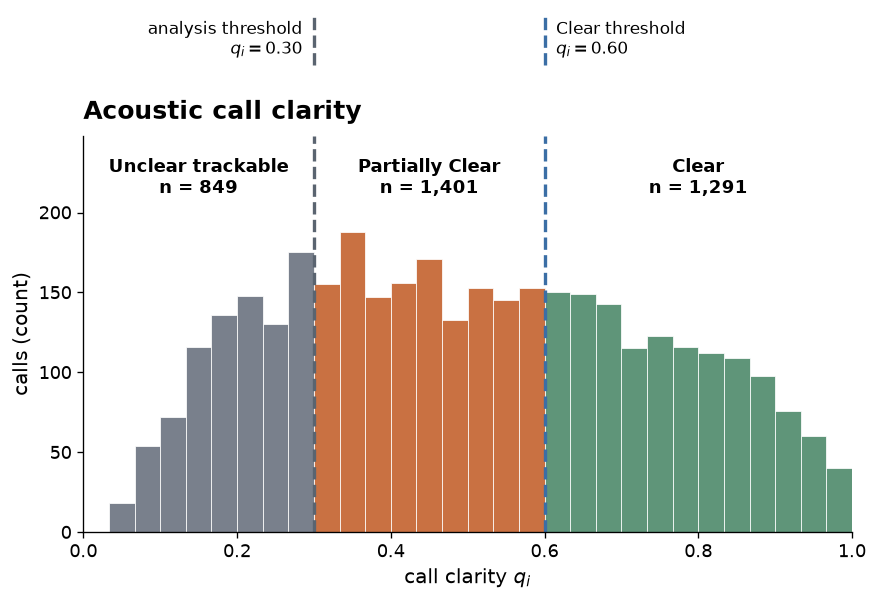

Trackable calls: 3,541. Unclear trackable: 849; Partially Clear: 1,401; Clear: 1,291; structural-QC failures: 443.


In [174]:
# ================================================================
# MAIN FIGURE 1 — Acoustic call clarity
# ================================================================

trackable_q = (
    features.loc[
        (features["quality"] == "ok") &
        features["snr_frac"].notna(),
        "snr_frac"
    ]
    .astype(float)
    .to_numpy()
)

analysis_thr = float(CALL_LOW_SNR_FRAC)     # 0.30
clear_thr = float(SNR_TIERS[0][0])          # 0.60

n_structural_fail = int(
    (features["quality"] != "ok").sum()
)

m_unclear = trackable_q < analysis_thr
m_partial = (
    (trackable_q >= analysis_thr) &
    (trackable_q < clear_thr)
)
m_clear = trackable_q >= clear_thr

n_unclear = int(m_unclear.sum())
n_partial = int(m_partial.sum())
n_clear = int(m_clear.sum())

CLARITY_COLORS = {
    "Unclear": PALETTE["muted"],
    "Partially Clear": PALETTE["observed"],
    "Clear": PALETTE["segment"],
}

bins = np.linspace(0, 1, 31)

# ================================================================
# Layout
#
# Header is physically separate from histogram.
# Structural-QC note has reserved footer space.
# ================================================================

fig = plt.figure(
    figsize=(7.2, 4.9),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[0.15, 1.0],
    left=0.12,
    right=0.98,
    bottom=0.19,
    top=0.91,
    hspace=0.10
)

ax_head = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])

ax_head.set_xlim(0, 1)
ax_head.set_ylim(0, 1)
ax_head.axis("off")

# Threshold keys aligned to their actual x positions
ax_head.axvline(
    analysis_thr,
    ymin=0.10,
    ymax=0.90,
    color=PALETTE["null_alt"],
    linestyle="--",
    linewidth=2
)

ax_head.text(
    analysis_thr - 0.015,
    0.52,
    r"analysis threshold" "\n" r"$q_i=0.30$",
    ha="right",
    va="center",
    fontsize=10
)

ax_head.axvline(
    clear_thr,
    ymin=0.10,
    ymax=0.90,
    color=PALETTE["accent"],
    linestyle="--",
    linewidth=2
)

ax_head.text(
    clear_thr + 0.015,
    0.52,
    r"Clear threshold" "\n" r"$q_i=0.60$",
    ha="left",
    va="center",
    fontsize=10
)

# ================================================================
# Histogram
# ================================================================

ax.hist(
    trackable_q[m_unclear],
    bins=bins,
    color=CLARITY_COLORS["Unclear"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90
)

ax.hist(
    trackable_q[m_partial],
    bins=bins,
    color=CLARITY_COLORS["Partially Clear"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90
)

ax.hist(
    trackable_q[m_clear],
    bins=bins,
    color=CLARITY_COLORS["Clear"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90
)

ax.axvline(
    analysis_thr,
    color=PALETTE["null_alt"],
    linestyle="--",
    linewidth=2
)

ax.axvline(
    clear_thr,
    color=PALETTE["accent"],
    linestyle="--",
    linewidth=2
)

# Reserve vertical whitespace for count labels
hist_n, _ = np.histogram(trackable_q, bins=bins)
y_data_max = float(hist_n.max())

ax.set_ylim(
    0,
    y_data_max * 1.32
)

category_annotations = [
    (0.15, "Unclear trackable", n_unclear),
    (0.45, "Partially Clear", n_partial),
    (0.80, "Clear", n_clear),
]

for xpos, label, n in category_annotations:
    ax.text(
        xpos,
        y_data_max * 1.18,
        f"{label}\nn = {n:,}",
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )

ax.set_title(
    "Acoustic call clarity",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    r"call clarity $q_i$",
    fontsize=12
)

ax.set_ylabel(
    "calls (count)",
    fontsize=12
)

ax.set_xlim(0, 1)

ax.tick_params(
    axis="both",
    labelsize=10.5
)
save_fig(
    fig,
    "main_call_clarity"
)

plt.show()

print(
    f"Trackable calls: {len(trackable_q):,}. "
    f"Unclear trackable: {n_unclear:,}; "
    f"Partially Clear: {n_partial:,}; "
    f"Clear: {n_clear:,}; "
    f"structural-QC failures: {n_structural_fail:,}."
)

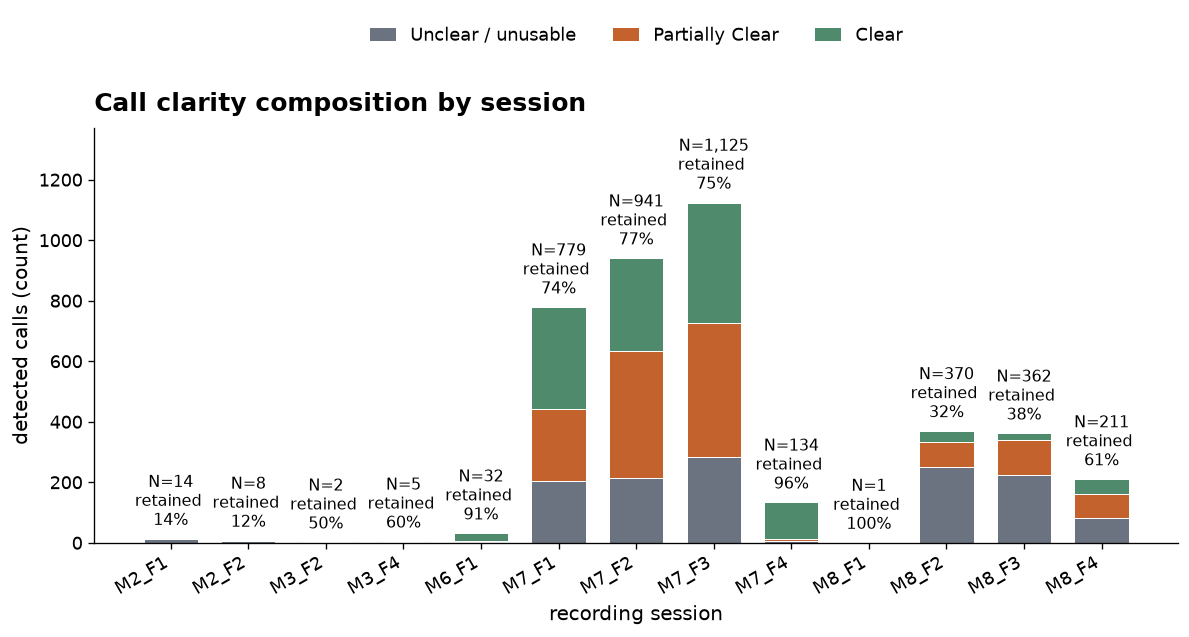

clarity_category,Unclear / unusable,Partially Clear,Clear
session,,,
M2_F1,12,2,0
M2_F2,7,1,0
M3_F2,1,0,1
M3_F4,2,2,1
M6_F1,3,4,25
M7_F1,205,238,336
M7_F2,214,422,305
M7_F3,284,444,397
M7_F4,5,8,121


In [175]:
# ================================================================
# SUPPLEMENT — Call clarity by session
# ================================================================

analysis_thr = float(CALL_LOW_SNR_FRAC)
clear_thr = float(SNR_TIERS[0][0])

clarity_df = features[
    ["session", "quality", "snr_frac"]
].copy()

clarity_df["clarity_category"] = "Unclear / unusable"

trackable = (
    clarity_df["quality"].eq("ok") &
    clarity_df["snr_frac"].notna()
)

clarity_df.loc[
    trackable &
    clarity_df["snr_frac"].ge(analysis_thr) &
    clarity_df["snr_frac"].lt(clear_thr),
    "clarity_category"
] = "Partially Clear"

clarity_df.loc[
    trackable &
    clarity_df["snr_frac"].ge(clear_thr),
    "clarity_category"
] = "Clear"

category_order = [
    "Unclear / unusable",
    "Partially Clear",
    "Clear"
]

CLARITY_COLORS = {
    "Unclear / unusable": PALETTE["muted"],
    "Partially Clear": PALETTE["observed"],
    "Clear": PALETTE["segment"],
}

session_order = sorted(
    clarity_df["session"].unique(),
    key=lambda s: (
        int(s.split("_")[0][1:]),
        int(s.split("_")[1][1:])
    )
)

counts = pd.crosstab(
    clarity_df["session"],
    clarity_df["clarity_category"]
).reindex(
    index=session_order,
    columns=category_order,
    fill_value=0
)

totals = counts.sum(axis=1)

retained_pct = (
    100 *
    (
        counts["Partially Clear"] +
        counts["Clear"]
    ) /
    totals
)

# ================================================================
# Layout
# ================================================================

fig = plt.figure(
    figsize=(9.8, 5.2),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 1,
    height_ratios=[0.12, 1],
    left=0.09,
    right=0.98,
    bottom=0.15,
    top=0.95,
    hspace=0.10
)

ax_leg = fig.add_subplot(gs[0, 0])
ax = fig.add_subplot(gs[1, 0])

ax_leg.axis("off")

legend_handles = [
    Patch(
        facecolor=CLARITY_COLORS[c],
        edgecolor="none",
        label=c
    )
    for c in category_order
]

ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    frameon=False,
    fontsize=11,
    handlelength=1.4,
    columnspacing=2.0
)

# ================================================================
# Count bars
# ================================================================

x = np.arange(len(session_order))
bottom = np.zeros(len(session_order))

for cat in category_order:

    vals = counts[cat].to_numpy()

    ax.bar(
        x,
        vals,
        bottom=bottom,
        width=0.70,
        color=CLARITY_COLORS[cat],
        edgecolor="white",
        linewidth=0.6
    )

    bottom += vals

max_total = float(totals.max())

ax.set_ylim(
    0,
    max_total * 1.22
)

for i, session in enumerate(session_order):

    ax.text(
        x[i],
        totals.iloc[i] + max_total * 0.025,
        f"N={int(totals.iloc[i]):,}\n"
        f"retained \n{retained_pct.iloc[i]:.0f}%",
        ha="center",
        va="bottom",
        fontsize=9.5
    )

ax.set_title(
    "Call clarity composition by session",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax.set_xlabel(
    "recording session",
    fontsize=12
)

ax.set_ylabel(
    "detected calls (count)",
    fontsize=12
)

ax.set_xticks(x)
ax.set_xticklabels(
    session_order,
    rotation=30,
    ha="right",
    fontsize=10.5
)

ax.tick_params(
    axis="y",
    labelsize=10.5
)

save_fig(
    fig,
    "supp_clarity_by_session"
)

plt.show()

display(counts)

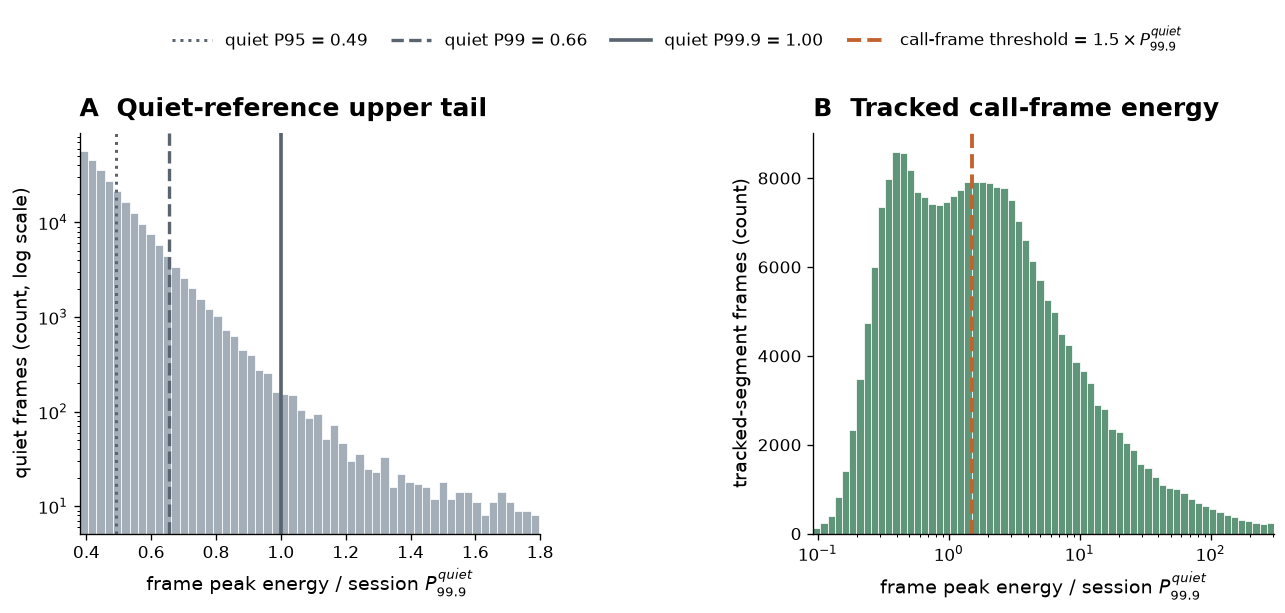

Quiet normalized percentiles: P95=0.491, P99=0.656, P99.9=1.000.
51.9% of tracked-segment frames exceed the 1.5 x P99.9 criterion.


In [176]:
# ================================================================
# SUPPLEMENT — Quiet-reference diagnostic
# ================================================================

from matplotlib.lines import Line2D


def quiet_reference_peak_energy(session, background):

    end_dlc = (
        session.call_times.min() -
        NOISE_REF_MARGIN_BEFORE_FIRST_CALL_S
        if len(session.call_times)
        else session.frame_t.max()
    )

    start_dlc = max(
        NOISE_REF_MIN_START_S,
        end_dlc - NOISE_REF_MAX_DURATION_S
    )

    dur = max(
        5.0,
        end_dlc - start_dlc
    )

    x, sr = read_wav_window(
        session.wav_path,
        dlc_to_audio(start_dlc, session.voc_sync_time),
        dur
    )

    _, f_khz, S = band_spectrogram(
        bandpass(x, sr),
        sr
    )

    S = normalize_spectrogram(
        S,
        f_khz,
        background
    )

    return S.max(axis=0)


# ================================================================
# Quiet reference
# ================================================================

quiet_norm = []
noise_by_session = {}

for lab, session in sessions.items():

    noise = estimate_noise_reference(
        session,
        backgrounds[lab]
    )

    noise_by_session[lab] = noise

    if noise.p999 <= 0:
        continue

    e = quiet_reference_peak_energy(
        session,
        backgrounds[lab]
    )

    e = np.asarray(e, dtype=float)
    e = e[np.isfinite(e)]

    quiet_norm.extend(
        e / noise.p999
    )

quiet_norm = np.asarray(
    quiet_norm,
    dtype=float
)

p95 = float(np.percentile(quiet_norm, 95))
p99 = float(np.percentile(quiet_norm, 99))
p999 = float(np.percentile(quiet_norm, 99.9))


# ================================================================
# Tracked call-frame energy
# ================================================================

call_norm = []

trackable = features.loc[
    features["quality"] == "ok",
    ["session", "call_time"]
]

for lab, grp in trackable.groupby(
    "session",
    sort=False
):

    session = sessions[lab]
    bg = backgrounds[lab]
    noise = noise_by_session[lab]

    if noise.p999 <= 0:
        continue

    for call_time in grp["call_time"].to_numpy():

        out = call_spectrogram(
            session,
            float(call_time),
            bg
        )

        if out is None:
            continue

        tc, f_khz, S = out

        e = S.max(axis=0)

        f_peak = f_khz[
            np.argmax(S, axis=0)
        ]

        seg = _track_ridge(
            e,
            f_peak,
            tc,
            noise
        )

        if seg is None:
            continue

        lo = seg["lo"]
        hi = seg["hi"]

        frame_e = e[lo:hi + 1]
        frame_e = frame_e[
            np.isfinite(frame_e) &
            (frame_e > 0)
        ]

        call_norm.extend(
            frame_e / noise.p999
        )

call_norm = np.asarray(
    call_norm,
    dtype=float
)

threshold = float(
    CALL_SNR_FRAC_MULT
)


# ================================================================
# Display ranges
# ================================================================

quiet_xmin = max(
    0.0,
    float(np.percentile(quiet_norm, 85))
)

quiet_xmax = min(
    1.8,
    max(
        1.20,
        float(np.percentile(quiet_norm, 99.99))
    )
)

positive_call = call_norm[
    call_norm > 0
]

call_xmin = max(
    0.03,
    float(np.percentile(positive_call, 0.1))
)

call_xmax = max(
    threshold * 2,
    float(np.percentile(positive_call, 99.5))
)


# ================================================================
# Colors
# ================================================================

QUIET_COLOR = PALETTE["null"]
CALL_COLOR = PALETTE["segment"]
PERCENTILE_COLOR = PALETTE["null_alt"]
THRESHOLD_COLOR = PALETTE["observed"]


# ================================================================
# Layout
#
# Top row = legend only.
# ================================================================

fig = plt.figure(
    figsize=(10.6, 5.0),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[0.14, 1],
    left=0.085,
    right=0.98,
    bottom=0.16,
    top=0.96,
    wspace=0.28,
    hspace=0.10
)

ax_leg = fig.add_subplot(
    gs[0, :]
)

ax_a = fig.add_subplot(
    gs[1, 0]
)

ax_b = fig.add_subplot(
    gs[1, 1]
)

ax_leg.axis("off")


# ================================================================
# A. Quiet upper tail
# ================================================================

quiet_visible = quiet_norm[
    (quiet_norm >= quiet_xmin) &
    (quiet_norm <= quiet_xmax)
]

ax_a.hist(
    quiet_visible,
    bins=55,
    color=QUIET_COLOR,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90
)

ax_a.set_yscale("log")

for xval, ls, lw in [
    (p95, ":", 1.8),
    (p99, "--", 2.0),
    (p999, "-", 2.2),
]:
    ax_a.axvline(
        xval,
        color=PERCENTILE_COLOR,
        linestyle=ls,
        linewidth=lw
    )

ax_a.set_xlim(
    quiet_xmin,
    quiet_xmax
)

ax_a.set_title(
    "A  Quiet-reference upper tail",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_a.set_xlabel(
    r"frame peak energy / session $P_{99.9}^{quiet}$",
    fontsize=11.5
)

ax_a.set_ylabel(
    "quiet frames (count, log scale)",
    fontsize=11.5
)

ax_a.tick_params(
    axis="both",
    labelsize=10
)


# ================================================================
# B. Tracked call-frame energy
# ================================================================

log_bins = np.logspace(
    np.log10(call_xmin),
    np.log10(call_xmax),
    65
)

visible_call = positive_call[
    positive_call <= call_xmax
]

ax_b.hist(
    visible_call,
    bins=log_bins,
    color=CALL_COLOR,
    edgecolor="white",
    linewidth=0.5,
    alpha=0.90
)

ax_b.set_xscale("log")

ax_b.axvline(
    threshold,
    color=THRESHOLD_COLOR,
    linestyle="--",
    linewidth=2.3
)

ax_b.set_xlim(
    call_xmin,
    call_xmax
)

ax_b.set_title(
    "B  Tracked call-frame energy",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_b.set_xlabel(
    r"frame peak energy / session $P_{99.9}^{quiet}$",
    fontsize=11.5
)

ax_b.set_ylabel(
    "tracked-segment frames (count)",
    fontsize=11.5
)

ax_b.tick_params(
    axis="both",
    labelsize=10
)


# ================================================================
# Legend lives in its OWN AXIS
# ================================================================

handles = [
    Line2D(
        [0], [0],
        color=PERCENTILE_COLOR,
        linestyle=":",
        linewidth=1.8,
        label=f"quiet P95 = {p95:.2f}"
    ),
    Line2D(
        [0], [0],
        color=PERCENTILE_COLOR,
        linestyle="--",
        linewidth=2.0,
        label=f"quiet P99 = {p99:.2f}"
    ),
    Line2D(
        [0], [0],
        color=PERCENTILE_COLOR,
        linestyle="-",
        linewidth=2.2,
        label=f"quiet P99.9 = {p999:.2f}"
    ),
    Line2D(
        [0], [0],
        color=THRESHOLD_COLOR,
        linestyle="--",
        linewidth=2.3,
        label=r"call-frame threshold = $1.5\times P_{99.9}^{quiet}$"
    )
]

ax_leg.legend(
    handles=handles,
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=10,
    handlelength=2.4,
    columnspacing=1.4
)

save_fig(
    fig,
    "supp_quiet_reference_diagnostic"
)

plt.show()

print(
    f"Quiet normalized percentiles: "
    f"P95={p95:.3f}, P99={p99:.3f}, P99.9={p999:.3f}."
)

print(
    f"{100*np.mean(call_norm > threshold):.1f}% "
    "of tracked-segment frames exceed the 1.5 x P99.9 criterion."
)

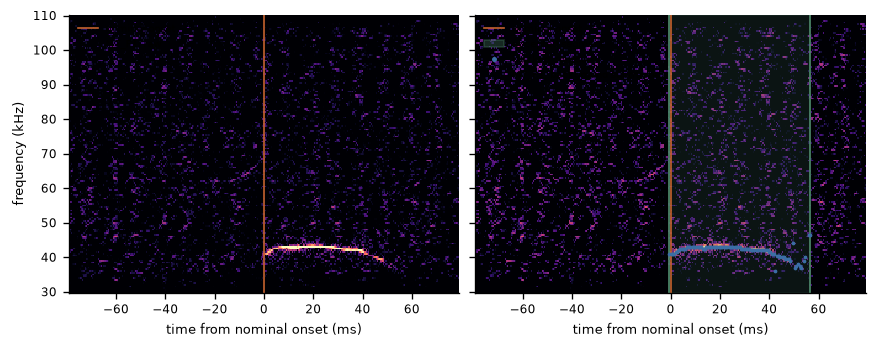

M7_F1, call at t = 415.20 s on the neural clock. The blue points are the frames the tracker accepted; every feature for this call is computed from those points only. The orange line is the detected call time the lab supplied, and the shaded band is what the tracker decided the call actually spans.


In [177]:
# One call, before and after background subtraction.
_lab = "M7_F1"
_s, _bg = sessions[_lab], backgrounds[_lab]
_noise = estimate_noise_reference(_s, _bg)
_cand = ok[ok["session"] == _lab].sort_values("snr_frac", ascending=False)
_ct = float(_cand.iloc[len(_cand) // 4]["call_time"])

fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharey=True)
plot_call_panel(axes[0], _s, _ct, _noise, None, label=f"{_lab}, raw", show_contour=False)
plot_call_panel(axes[1], _s, _ct, _noise, _bg, label=f"{_lab}, background subtracted")
axes[1].set_ylabel("")
save_fig(fig, "04_call_before_after_cleaning")
plt.show()
print(f"{_lab}, call at t = {_ct:.2f} s on the neural clock. The blue points are the "
      "frames the tracker accepted; every feature for this call is computed from those "
      "points only. The orange line is the detected call time the lab supplied, and the "
      "shaded band is what the tracker decided the call actually spans.")

## 7. Feature-set selection

Clustering uses Euclidean distance on standardised features, so redundant features
are not free: two features carrying the same information are counted twice in the
distance and quietly reweight the whole partition without anyone deciding to.

Two candidate sets:

- **full (5)**: `duration_ms`, `fm_intercept_khz`, `fm_slope_khz_per_s`,
  `freq_min_khz`, `freq_max_khz`
- **core (3)**: `duration_ms`, `fm_intercept_khz`, `fm_slope_khz_per_s` — one
  duration term, one pitch term, one modulation term, no two describing the same
  property

**The decision is made here, before K is chosen, and on a fact that does not depend
on K.** Whether two features are near-duplicates of each other is a property of the
data, measurable without committing to any number of clusters: if a pair exceeds
|r| = 0.80, the set containing that redundancy is not used for a distance-based
clustering. Doing it the other way round — picking a feature set by comparing
partitions at some particular K, then choosing K afterwards — is circular, because
each decision then depends on the other.

Below the decision, the agreement between the two sets is reported across the whole
K range. That is a robustness report, not the criterion: it says how much the
partition would have changed had the other set been used, and it is worth reading
even when the choice is already made.

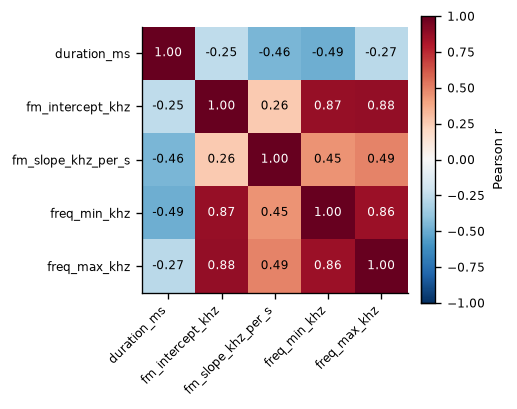

Feature pairs with |r| >= 0.80: fm_intercept_khz / freq_min_khz = 0.87; fm_intercept_khz / freq_max_khz = 0.88; freq_min_khz / freq_max_khz = 0.86

3 redundant pair(s) found, all involving freq_max_khz, freq_min_khz. Standardised Euclidean distance would count that shared property once per feature, so the core 3-feature set is used for clustering.
Features used for clustering: ['duration_ms', 'fm_intercept_khz', 'fm_slope_khz_per_s']


,k,ari_full_vs_core
0,2,0.385
1,3,0.910
2,4,0.568
3,5,0.750
4,6,0.787
5,7,0.834


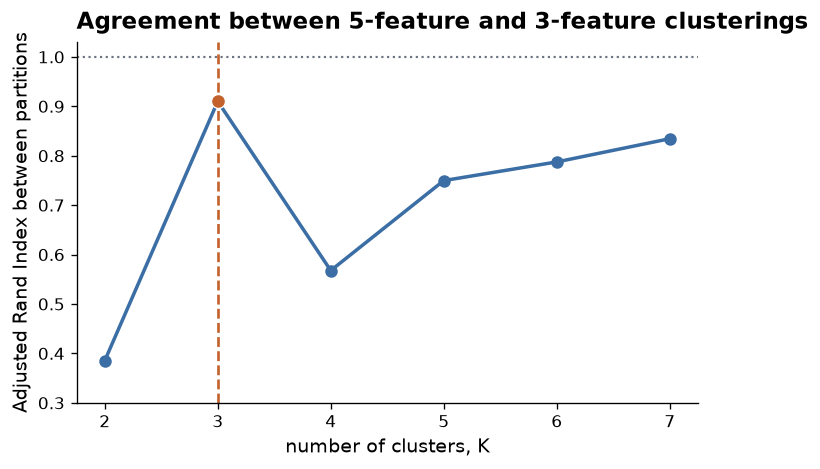

Agreement between the two feature sets ranges 0.39-0.91 across K = 2-7, and is not stable: the two sets give nearly the same grouping at some K and clearly different groupings at others. That instability is itself the reason the choice cannot be made by comparing partitions -- the answer would depend on which K it was measured at.

For context, on the full set PC1 alone carries 64% of the variance and its three largest loadings are freq_min_khz, freq_max_khz, fm_intercept_khz -- the frequency triple. That is the axis the redundancy creates, and a two-way split of that cloud falls along it.


In [178]:
def prepare_matrix(df, cols):
    sub = df[cols].dropna()
    scaler = StandardScaler()
    return scaler.fit_transform(sub.values), scaler, sub.index


corr = ok[FEATURES_FULL].corr()
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(FEATURES_FULL)), FEATURES_FULL, rotation=45, ha="right")
ax.set_yticks(range(len(FEATURES_FULL)), FEATURES_FULL)
for i in range(len(FEATURES_FULL)):
    for j in range(len(FEATURES_FULL)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i, j]) > 0.6 else "black")
fig.colorbar(im, ax=ax, shrink=0.8, label="Pearson r")
save_fig(fig, "05_feature_correlation")
plt.show()

pairs = [(a, b, corr.loc[a, b]) for a, b in itertools.combinations(FEATURES_FULL, 2)]
strong = [pr for pr in pairs if abs(pr[2]) >= COLLINEARITY_R]
print(f"Feature pairs with |r| >= {COLLINEARITY_R:.2f}: " +
      ("; ".join(f"{a} / {b} = {r:.2f}" for a, b, r in strong) if strong else "none"))

if strong:
    CLUSTER_FEATURES, ALT_FEATURES = FEATURES_CORE, FEATURES_FULL
    redundant = sorted({f for a, b, _ in strong for f in (a, b)} - set(FEATURES_CORE))
    print(f"\n{len(strong)} redundant pair(s) found, all involving {', '.join(redundant)}. "
          "Standardised Euclidean distance would count that shared property once per "
          "feature, so the core 3-feature set is used for clustering.")
else:
    CLUSTER_FEATURES, ALT_FEATURES = FEATURES_FULL, FEATURES_CORE
    print("\nNo pair exceeds the threshold, so the full 5-feature set is used.")
print("Features used for clustering:", CLUSTER_FEATURES)

# How much does that choice matter? Reported across the whole K range, not at one K.
X_full, _, idx_full = prepare_matrix(ok, FEATURES_FULL)
X_core, _, idx_core = prepare_matrix(ok, FEATURES_CORE)
common = idx_full.intersection(idx_core)
pos_full = pd.Index(idx_full).get_indexer(common)
pos_core = pd.Index(idx_core).get_indexer(common)
set_agreement = pd.DataFrame([dict(
    k=k,
    ari_full_vs_core=adjusted_rand_score(
        KMeans(k, n_init=10, random_state=RANDOM_SEED).fit_predict(X_full)[pos_full],
        KMeans(k, n_init=10, random_state=RANDOM_SEED).fit_predict(X_core)[pos_core]),
) for k in K_RANGE])
show(set_agreement)

# ================================================================
# Supplement — feature-set sensitivity
# ================================================================

k_agree = set_agreement["k"].to_numpy(dtype=int)
ari_agree = set_agreement["ari_full_vs_core"].to_numpy(dtype=float)

fig, ax = plt.subplots(
    figsize=(5.8, 3.8),
    constrained_layout=False
)

fig.subplots_adjust(
    left=0.16,
    right=0.97,
    bottom=0.19,
    top=0.87
)

# Main ARI curve
ax.plot(
    k_agree,
    ari_agree,
    color=PALETTE["accent"],
    marker="o",
    markersize=6.5,
    linewidth=2.1
)

# Reference for identical partitions
ax.axhline(
    1.0,
    color=PALETTE["muted"],
    linestyle=":",
    linewidth=1.3
)

# Final selected K
ax.axvline(
    3,
    color=PALETTE["observed"],
    linestyle="--",
    linewidth=1.6
)

# Highlight K = 3
k3_idx = np.where(k_agree == 3)[0][0]

ax.scatter(
    [k_agree[k3_idx]],
    [ari_agree[k3_idx]],
    s=70,
    color=PALETTE["observed"],
    edgecolor="white",
    linewidth=0.8,
    zorder=4
)

ax.set_title(
    "Agreement between 5-feature and 3-feature clusterings",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)

ax.set_xlabel(
    "number of clusters, K",
    fontsize=11.5
)

ax.set_ylabel(
    "Adjusted Rand Index between partitions",
    fontsize=11.5
)

ax.set_xticks(
    k_agree
)

# Tight range around the actual results while retaining ARI = 1 reference
ax.set_ylim(
    0.30,
    1.03
)

ax.set_xlim(
    k_agree.min() - 0.25,
    k_agree.max() + 0.25
)

ax.tick_params(
    axis="both",
    labelsize=10
)

# No legend and no explanatory text inside the figure.

save_fig(
    fig,
    "supp_feature_set_sensitivity"
)

plt.show()

_a = set_agreement["ari_full_vs_core"]
print(f"Agreement between the two feature sets ranges {_a.min():.2f}-{_a.max():.2f} across "
      f"K = {min(K_RANGE)}-{max(K_RANGE)}, and is not stable: the two sets give nearly the "
      "same grouping at some K and clearly different groupings at others. That instability "
      "is itself the reason the choice cannot be made by comparing partitions -- the answer "
      "would depend on which K it was measured at.")

# PCA is used only to describe where the variance sits, not to transform the data.
_pca_desc = PCA().fit(X_full)
_load = pd.Series(np.abs(_pca_desc.components_[0]), index=FEATURES_FULL).sort_values(ascending=False)
print(f"\nFor context, on the full set PC1 alone carries "
      f"{_pca_desc.explained_variance_ratio_[0]:.0%} of the variance and its three largest "
      f"loadings are {', '.join(_load.index[:3])} -- the frequency triple. That is the axis "
      "the redundancy creates, and a two-way split of that cloud falls along it.")

**Interpretation.** The feature set is fixed here, before K, on collinearity
alone: if any feature pair exceeds |r| = 0.80 the set holding that redundancy is
rejected for a distance-based clustering, because standardised Euclidean distance
would otherwise count the shared property more than once. On this data the
frequency terms are collinear, so the 3-feature *core* set — one duration term,
one starting-pitch term, one FM-slope term — is used. The agreement between the
two feature sets across the K range (table) is reported only as robustness; it is
itself unstable across K, which is why the choice cannot be made by comparing
partitions — the answer would depend on the K it was measured at.


## 8. Clustering: K-Means vs. GMM, and the choice of K

Two questions, and they are not the same question, so they are decided by different
criteria.

**How many clusters?** Judged by internal validity indices computed on the K-Means
labels: silhouette (higher is better), Davies-Bouldin (lower is better) and
Calinski-Harabasz (higher is better). Silhouette is the primary criterion; the other
two are reported so that K can be chosen where the indices agree rather than from
one number in isolation.

**K-Means or a Gaussian mixture?** Silhouette cannot settle this: it rewards
compact, spherical, centroid-defined clusters, which is K-Means's own objective, so
using it here would be scoring one model on its own loss function. BIC is the
principled criterion for a mixture model, and it is exactly the "are the extra
parameters worth it" question — a full-covariance GMM fits `k*d*(d+1)/2` covariance
parameters against K-Means's `k*d` centroid parameters. Both models get ten random
restarts so the comparison is not decided by which one was allowed more tries.

Covariance type is tested rather than assumed: a diagonal-covariance GMM is fit
alongside the full-covariance one at every K. A diagonal covariance assumes the
features are independent within a cluster, which the correlation matrix in §7 shows
is false, so full covariance is expected to win — but the BIC comparison is what
decides it.

**BIC is not used to choose K, and the table below shows why the distinction
matters.** BIC falls monotonically across the whole range swept: with thousands of
points, every extra mixture component buys more likelihood than the parameter
penalty costs, so the criterion keeps rewarding more components and never turns
around. That is expected behaviour for a mixture model at this sample size, not a
vote for the largest K on the grid. K is chosen by the internal validity indices;
BIC answers only the two model-form questions above.

clustering matrix: 2692 calls x 3 standardised features


,k,silhouette,davies_bouldin,calinski_harabasz,bic_gmm_full,bic_gmm_diag,ari_km_vs_gmm,n_params_kmeans,n_params_gmm_full
0,2,0.377,1.077,1786.628,19815.302,20155.018,0.828,6,19
1,3,0.394,1.010,1791.753,17449.071,18246.138,0.693,9,29
2,4,0.365,0.960,1734.211,17002.436,17766.333,0.436,12,39
3,5,0.351,0.950,1717.557,16720.213,17452.043,0.489,15,49
4,6,0.358,0.951,1698.868,16588.552,17225.663,0.561,18,59
5,7,0.356,0.928,1665.280,16573.552,17151.268,0.539,21,69


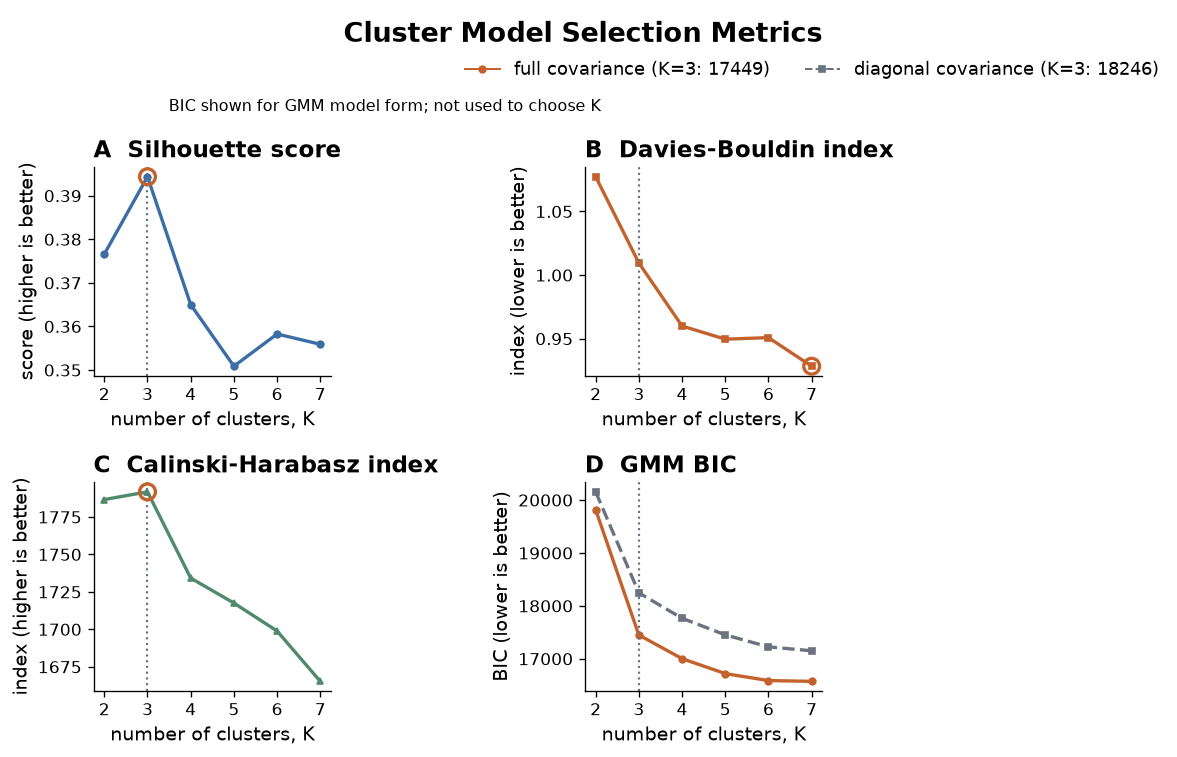

best K by silhouette 3, by Davies-Bouldin 7, by Calinski-Harabasz 3.
K = 3 is used (silhouette is the primary criterion); the indices do not all agree, which is stated again in the summary.


In [231]:
X, cluster_scaler, cluster_idx = prepare_matrix(ok, CLUSTER_FEATURES)
d_feat = X.shape[1]
print(f"clustering matrix: {X.shape[0]} calls x {d_feat} standardised features")

rows = []

# Keep the actual full-covariance K=3 GMM fitted during the sweep.
# The visualization later uses this exact model and does not refit it.
gmm_primary = None
gmm_primary_labels = None


for k in K_RANGE:

    km = KMeans(
        k,
        n_init=10,
        random_state=RANDOM_SEED
    ).fit(X)


    gm_full = GaussianMixture(
        k,
        covariance_type="full",
        n_init=10,
        random_state=RANDOM_SEED
    ).fit(X)


    gm_diag = GaussianMixture(
        k,
        covariance_type="diag",
        n_init=10,
        random_state=RANDOM_SEED
    ).fit(X)


    gm_full_labels = gm_full.predict(
        X
    )


    # Preserve the final full-covariance GMM at the primary K.
    if int(k) == int(K_PRIMARY):

        gmm_primary = gm_full

        gmm_primary_labels = (
            gm_full_labels.copy()
        )


    rows.append(
        dict(
            k=k,

            silhouette=silhouette_score(
                X,
                km.labels_
            ),

            davies_bouldin=davies_bouldin_score(
                X,
                km.labels_
            ),

            calinski_harabasz=calinski_harabasz_score(
                X,
                km.labels_
            ),

            bic_gmm_full=gm_full.bic(X),

            bic_gmm_diag=gm_diag.bic(X),

            ari_km_vs_gmm=adjusted_rand_score(
                km.labels_,
                gm_full_labels
            ),

            n_params_kmeans=(
                k * d_feat
            ),

            n_params_gmm_full=(
                k * d_feat
                +
                k * d_feat * (d_feat + 1) // 2
                +
                (k - 1)
            ),
        )
    )


if gmm_primary is None:

    raise RuntimeError(
        f"No full-covariance GMM was retained for K={K_PRIMARY}."
    )

sweep_k = pd.DataFrame(rows)
show(sweep_k)

fig = plt.figure(figsize=(9.6, 6.2), constrained_layout=False)

fig.suptitle("Cluster Model Selection Metrics", fontsize=16, fontweight="bold", y=0.98)

# 1. FIX: top=0.92 and height_ratios=[0.12, 1, 1]
gs = fig.add_gridspec(
    3,
    2,
    height_ratios=[0.12, 1, 1],  # Expanded slightly from 0.05 so both lines fit
    left=0.09,
    right=0.98,
    bottom=0.09,
    top=0.92,  # Was 1. Pulling down to 0.92 keeps elements on the canvas
    wspace=0.28,
    hspace=0.1,
)

ax_head = fig.add_subplot(gs[0, :])
ax_head.axis("off")

ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[2, 0])
ax_d = fig.add_subplot(gs[2, 1])

axes_k = [ax_a, ax_b, ax_c, ax_d]

# ------------------------------------------------
# A. Silhouette
# ------------------------------------------------
ax_a.plot(
    sweep_k["k"],
    sweep_k["silhouette"],
    color=PALETTE["accent"],
    marker="o",
    linewidth=2,
)

best = sweep_k.loc[sweep_k["silhouette"].idxmax()]

ax_a.scatter(
    best["k"],
    best["silhouette"],
    s=90,
    facecolors="none",
    edgecolors=PALETTE["observed"],
    linewidths=2,
    zorder=4,
)

# ------------------------------------------------
# B. Davies-Bouldin
# ------------------------------------------------
ax_b.plot(
    sweep_k["k"],
    sweep_k["davies_bouldin"],
    color=PALETTE["cluster"][1],
    marker="s",
    linewidth=2,
)

best_db = sweep_k.loc[sweep_k["davies_bouldin"].idxmin()]

ax_b.scatter(
    best_db["k"],
    best_db["davies_bouldin"],
    s=90,
    facecolors="none",
    edgecolors=PALETTE["observed"],
    linewidths=2,
    zorder=4,
)

# ------------------------------------------------
# C. Calinski-Harabasz
# ------------------------------------------------
ax_c.plot(
    sweep_k["k"],
    sweep_k["calinski_harabasz"],
    color=PALETTE["segment"],
    marker="^",
    linewidth=2,
)

best_ch = sweep_k.loc[sweep_k["calinski_harabasz"].idxmax()]

ax_c.scatter(
    best_ch["k"],
    best_ch["calinski_harabasz"],
    s=90,
    facecolors="none",
    edgecolors=PALETTE["observed"],
    linewidths=2,
    zorder=4,
)

# ------------------------------------------------
# D. GMM BIC
# ------------------------------------------------
ax_d.plot(
    sweep_k["k"],
    sweep_k["bic_gmm_full"],
    color=PALETTE["observed"],
    marker="o",
    linewidth=2,
)

ax_d.plot(
    sweep_k["k"],
    sweep_k["bic_gmm_diag"],
    color=PALETTE["muted"],
    marker="s",
    linestyle="--",
    linewidth=2,
)

for ax in axes_k:
    ax.axvline(k_ref, color=PALETTE["muted"], linestyle=":", linewidth=1.3)
    ax.set_xticks(sweep_k["k"])
    ax.set_xlabel("number of clusters, K", fontsize=11.5)
    ax.tick_params(axis="both", labelsize=10)

ax_a.set_title("A  Silhouette score", loc="left", fontsize=14, fontweight="bold")
ax_a.set_ylabel("score (higher is better)", fontsize=11.5)

ax_b.set_title(
    "B  Davies-Bouldin index", loc="left", fontsize=14, fontweight="bold"
)
ax_b.set_ylabel("index (lower is better)", fontsize=11.5)

ax_c.set_title(
    "C  Calinski-Harabasz index", loc="left", fontsize=14, fontweight="bold"
)
ax_c.set_ylabel("index (higher is better)", fontsize=11.5)

ax_d.set_title("D  GMM BIC", loc="left", fontsize=14, fontweight="bold")
ax_d.set_ylabel("BIC (lower is better)", fontsize=11.5)

# Dedicated header, not over Panel D
head_handles = [
    Line2D(
        [0],
        [0],
        color=PALETTE["observed"],
        marker="o",
        label=f"full covariance (K=3: {row_k3['bic_gmm_full']:.0f})",
    ),
    Line2D(
        [0],
        [0],
        color=PALETTE["muted"],
        marker="s",
        linestyle="--",
        label=f"diagonal covariance (K=3: {row_k3['bic_gmm_diag']:.0f})",
    ),
]

# 2. FIX: Stack legend at upper center of ax_head
ax_head.legend(
    handles=head_handles,
    loc=(0.5,-2),
    ncol=2,
    frameon=False,
    fontsize=10.5,
)

# 3. FIX: Place text near the bottom of ax_head space
ax_head.text(
    0.4,
    -3,
    "BIC shown for GMM model form; not used to choose K",
    horizontalalignment='center',
    fontsize=9.5,
)

save_fig(fig, "supp_k_selection_2x2")
plt.show()

K_SIL = int(sweep_k.loc[sweep_k["silhouette"].idxmax(), "k"])
K_DB  = int(sweep_k.loc[sweep_k["davies_bouldin"].idxmin(), "k"])
K_CH  = int(sweep_k.loc[sweep_k["calinski_harabasz"].idxmax(), "k"])
K_PRIMARY = K_SIL
DECODING_K_SWEEP = tuple(sorted(set(DECODING_K_SWEEP) | {K_PRIMARY}))
votes = [K_SIL, K_DB, K_CH]
print(f"best K by silhouette {K_SIL}, by Davies-Bouldin {K_DB}, by Calinski-Harabasz {K_CH}.")
print(f"K = {K_PRIMARY} is used (silhouette is the primary criterion)"
      + (", and the three indices agree." if len(set(votes)) == 1 else
         "; the indices do not all agree, which is stated again in the summary."))

In [180]:
row = sweep_k.set_index("k").loc[K_PRIMARY]
ARI_KM_GMM = float(row["ari_km_vs_gmm"])
diag_wins = row["bic_gmm_diag"] < row["bic_gmm_full"]
print(f"At K = {K_PRIMARY}, with {X.shape[0]} calls:")
print(f"  K-Means free parameters       {int(row['n_params_kmeans'])}")
print(f"  full-covariance GMM parameters {int(row['n_params_gmm_full'])}"
      f"  ({row['n_params_gmm_full']/row['n_params_kmeans']:.1f}x as many)")
print(f"  BIC, GMM full covariance      {row['bic_gmm_full']:.0f}")
print(f"  BIC, GMM diagonal covariance  {row['bic_gmm_diag']:.0f}")
print(f"  ARI between K-Means and GMM   {row['ari_km_vs_gmm']:.3f}")
print()
print(f"Covariance type: the {'diagonal' if diag_wins else 'full'}-covariance GMM has the "
      f"lower BIC. " + ("This is the expected result given the feature correlations in §7 -- "
      "a diagonal covariance would assume an independence the features do not have."
      if not diag_wins else
      "The full covariance's extra parameters are not paying for themselves at this "
      "sample size, so the diagonal model is the better-supported mixture."))
print()
print(f"Model choice: K-Means labels are used downstream. The two models agree at "
      f"ARI = {row['ari_km_vs_gmm']:.2f}, so this is not a choice between two different "
      "answers; K-Means is preferred because it estimates far fewer parameters for the "
      "same partition, and because the downstream target needs a hard assignment rather "
      "than a posterior probability.")

kmeans_final = KMeans(K_PRIMARY, n_init=10, random_state=RANDOM_SEED).fit(X)
labels = kmeans_final.labels_
ok = ok.loc[cluster_idx].copy()
ok["cluster"] = labels

# The feature set that was not chosen, reported rather than left implicit.
X_alt, _, _ = prepare_matrix(ok, ALT_FEATURES)
alt = pd.DataFrame([dict(
    k=k,
    silhouette=silhouette_score(X_alt, KMeans(k, n_init=10, random_state=RANDOM_SEED)
                                .fit_predict(X_alt)),
) for k in K_RANGE])
K_ALT = int(alt.loc[alt["silhouette"].idxmax(), "k"])
print(f"\nAlternative analysis, for the record. Had the {len(ALT_FEATURES)}-feature set "
      f"({', '.join(ALT_FEATURES)}) been used instead, silhouette would have selected "
      f"K = {K_ALT} (silhouette {alt['silhouette'].max():.3f}).")
print("Silhouette values are not comparable between the two sets -- the index is defined "
      "within a given feature space, and a space containing near-duplicate features scores "
      "higher simply because the duplication stretches the cloud along one axis. The number "
      "above says which K that alternative would have picked, not that it is better or worse "
      "than the analysis carried forward.")

At K = 3, with 2692 calls:
  K-Means free parameters       9
  full-covariance GMM parameters 29  (3.2x as many)
  BIC, GMM full covariance      17449
  BIC, GMM diagonal covariance  18246
  ARI between K-Means and GMM   0.693

Covariance type: the full-covariance GMM has the lower BIC. This is the expected result given the feature correlations in §7 -- a diagonal covariance would assume an independence the features do not have.

Model choice: K-Means labels are used downstream. The two models agree at ARI = 0.69, so this is not a choice between two different answers; K-Means is preferred because it estimates far fewer parameters for the same partition, and because the downstream target needs a hard assignment rather than a posterior probability.

Alternative analysis, for the record. Had the 5-feature set (duration_ms, fm_intercept_khz, fm_slope_khz_per_s, freq_min_khz, freq_max_khz) been used instead, silhouette would have selected K = 2 (silhouette 0.494).
Silhouette values are not 

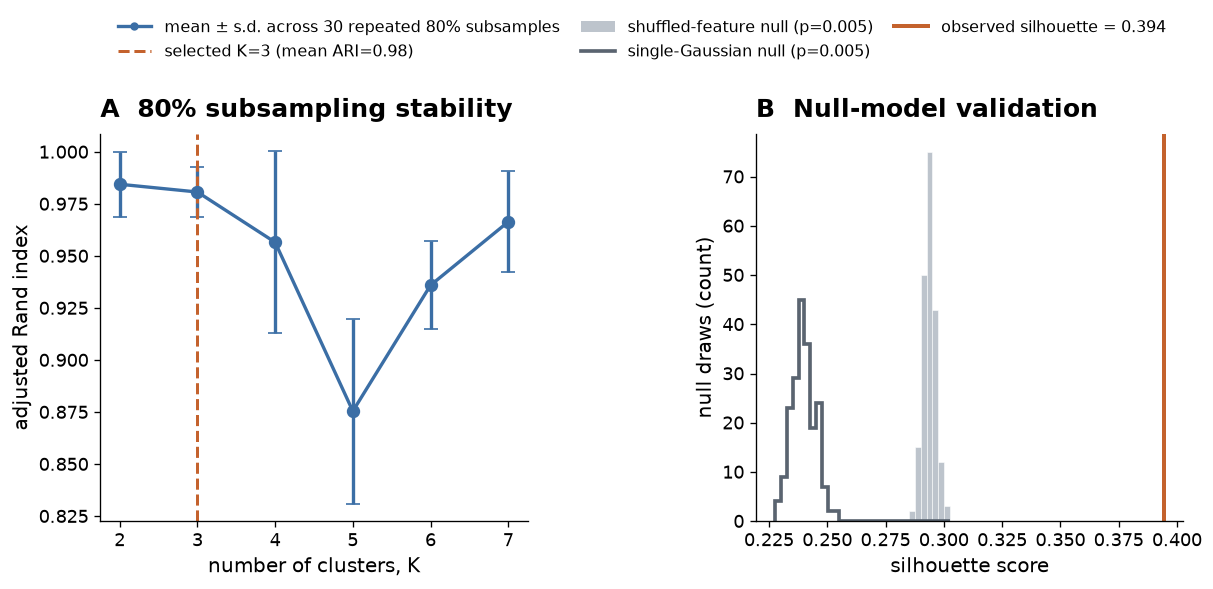

Stability at K = 3: 80% subsampling ARI 0.98 (most stable K in the sweep is 2).
Silhouette vs. two nulls, observed 0.394:
  shuffled features (no dependence at all): max 0.303, p = 0.0050
  single Gaussian (same covariance, one mode): max 0.254, p = 0.0050
  p floor at 200 draws is 0.0050.
Cluster sizes: c0 n=757 (28%), c1 n=994 (37%), c2 n=941 (35%); balance score 0.99.



,tier,min_snr_frac,n_calls,ari_vs_analysis
0,high quality only,0.6,1291,0.861
1,analysis threshold,0.3,2692,1.000
2,every tracked call,0.0,3541,0.987


Each row re-derives the call-type categories from a differently filtered set of calls and then applies them to the calls used in the analysis. ARI near 1 means the categories do not depend on where the quality cut is placed; the 0.86-1.00 range observed here is what that dependence actually amounts to.


In [181]:
# Are the clusters stable, and are they better than chance?
def subsample_ari(X, k, n=N_STABILITY_RESAMPLES, frac=0.8, seed=RANDOM_SEED):
    r = np.random.default_rng(seed)
    ref = KMeans(k, n_init=10, random_state=seed).fit(X).labels_
    out = np.empty(n)
    for i in range(n):
        sub = r.choice(len(X), size=int(frac * len(X)), replace=False)
        m = KMeans(k, n_init=10, random_state=seed + 1 + i).fit(X[sub])
        out[i] = adjusted_rand_score(ref, m.predict(X))
    return out


def permutation_silhouette(X, k, n=N_CLUSTER_PERMUTATIONS, seed=RANDOM_SEED):
    """Shuffle each feature column independently: keeps every marginal distribution
    but destroys all dependence between features. This is the weaker of the two
    nulls used here -- correlated features alone can raise silhouette, so passing
    it is necessary but not sufficient."""
    r = np.random.default_rng(seed)
    real = silhouette_score(X, KMeans(k, n_init=10, random_state=seed).fit_predict(X))
    null = np.empty(n)
    for i in range(n):
        Xp = np.column_stack([r.permutation(X[:, j]) for j in range(X.shape[1])])
        null[i] = silhouette_score(Xp, KMeans(k, n_init=10, random_state=seed + 1 + i).fit_predict(Xp))
    return real, null, (np.sum(null >= real) + 1) / (n + 1)


def unimodal_silhouette(X, k, n=N_CLUSTER_PERMUTATIONS, seed=RANDOM_SEED):
    """The stricter null: draw from a single multivariate Gaussian with the same
    mean and covariance as the data. Feature correlations are preserved exactly,
    so the only thing the reference lacks is more than one mode. Splitting an
    elongated single blob still yields a positive silhouette, and this measures
    how much -- which is what the observed value has to beat."""
    r = np.random.default_rng(seed)
    real = silhouette_score(X, KMeans(k, n_init=10, random_state=seed).fit_predict(X))
    mu, cov = X.mean(axis=0), np.cov(X, rowvar=False)
    null = np.empty(n)
    for i in range(n):
        Xs = r.multivariate_normal(mu, cov, size=X.shape[0])
        null[i] = silhouette_score(Xs, KMeans(k, n_init=10, random_state=seed + 1 + i).fit_predict(Xs))
    return real, null, (np.sum(null >= real) + 1) / (n + 1)


def _stability_table():
    rows = []
    for k in K_RANGE:
        a = subsample_ari(X, k)
        rows.append(dict(k=k, ari_mean=a.mean(), ari_std=a.std()))
    return pd.DataFrame(rows)


stab = cached("cluster_stability", _stability_table)
sil_real, sil_null, sil_p = cached("cluster_permutation",
                                   lambda: permutation_silhouette(X, K_PRIMARY))
_, uni_null, uni_p = cached("cluster_unimodal",
                            lambda: unimodal_silhouette(X, K_PRIMARY))
sizes = pd.Series(labels).value_counts().sort_index()
fracs = sizes / sizes.sum()
balance = float(-(fracs * np.log(fracs)).sum() / np.log(len(fracs)))

# ================================================================
# Supplement — stability and null-model validation
# ================================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

k_vals = np.asarray(stab["k"], dtype=float)
ari_mean = np.asarray(stab["ari_mean"], dtype=float)
ari_std = np.asarray(stab["ari_std"], dtype=float)

sil_null_plot = np.asarray(
    sil_null,
    dtype=float
).ravel()

uni_null_plot = np.asarray(
    uni_null,
    dtype=float
).ravel()

observed_sil = float(sil_real)

k3_ari = float(
    stab.loc[
        stab["k"] == K_PRIMARY,
        "ari_mean"
    ].iloc[0]
)

fig = plt.figure(
    figsize=(10.0, 4.8),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[0.15, 1],
    left=0.085,
    right=0.98,
    bottom=0.15,
    top=0.96,
    wspace=0.28,
    hspace=0.10
)

ax_leg = fig.add_subplot(
    gs[0, :]
)
ax_leg.axis("off")

ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])

# ================================================================
# A. 80% subsampling stability
# ================================================================

ax_a.errorbar(
    k_vals,
    ari_mean,
    yerr=ari_std,
    marker="o",
    markersize=7,
    linewidth=2,
    capsize=4,
    color=PALETTE["accent"]
)

ax_a.axvline(
    K_PRIMARY,
    color=PALETTE["observed"],
    linestyle="--",
    linewidth=1.8
)

ax_a.set_title(
    "A  80% subsampling stability",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_a.set_xlabel(
    "number of clusters, K",
    fontsize=12
)

ax_a.set_ylabel(
    "adjusted Rand index",
    fontsize=12
)

ax_a.set_xticks(k_vals)

ax_a.tick_params(
    axis="both",
    labelsize=10.5
)

# ================================================================
# B. Null tests
# ================================================================

all_null = np.concatenate([
    sil_null_plot,
    uni_null_plot
])

bins = np.linspace(
    all_null.min(),
    all_null.max(),
    31
)

ax_b.hist(
    sil_null_plot,
    bins=bins,
    color=PALETTE["null"],
    edgecolor="white",
    linewidth=0.5,
    alpha=0.65
)

ax_b.hist(
    uni_null_plot,
    bins=bins,
    histtype="step",
    color=PALETTE["null_alt"],
    linewidth=2.2
)

ax_b.axvline(
    observed_sil,
    color=PALETTE["observed"],
    linewidth=2.4
)

ax_b.set_title(
    "B  Null-model validation",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_b.set_xlabel(
    "silhouette score",
    fontsize=12
)

ax_b.set_ylabel(
    "null draws (count)",
    fontsize=12
)

ax_b.tick_params(
    axis="both",
    labelsize=10.5
)

# ================================================================
# Dedicated legend
# ================================================================

handles = [
    Line2D(
        [0], [0],
        color=PALETTE["accent"],
        marker="o",
        linewidth=2,
        label="mean ± s.d. across 30 repeated 80% subsamples"
    ),

    Line2D(
        [0], [0],
        color=PALETTE["observed"],
        linestyle="--",
        linewidth=1.8,
        label=f"selected K=3 (mean ARI={k3_ari:.2f})"
    ),

    Patch(
        facecolor=PALETTE["null"],
        edgecolor="none",
        alpha=0.65,
        label=f"shuffled-feature null (p={sil_p:.3f})"
    ),

    Line2D(
        [0], [0],
        color=PALETTE["null_alt"],
        linewidth=2.2,
        label=f"single-Gaussian null (p={uni_p:.3f})"
    ),

    Line2D(
        [0], [0],
        color=PALETTE["observed"],
        linewidth=2.4,
        label=f"observed silhouette = {observed_sil:.3f}"
    )
]

ax_leg.legend(
    handles=handles,
    loc="center",
    ncol=3,
    frameon=False,
    fontsize=9.7,
    columnspacing=1.3,
    handlelength=2.1
)

save_fig(
    fig,
    "supp_cluster_validation"
)

plt.show()

_best_stab = int(stab.loc[stab["ari_mean"].idxmax(), "k"])
_this = float(stab.loc[stab["k"] == K_PRIMARY, "ari_mean"].iloc[0])
print(
    f"Stability at K = {K_PRIMARY}: "
    f"80% subsampling ARI {_this:.2f} "
    f"(most stable K in the sweep is {_best_stab})."
)
print(f"Silhouette vs. two nulls, observed {sil_real:.3f}:")
print(f"  shuffled features (no dependence at all): max {sil_null.max():.3f}, p = {sil_p:.4f}")
print(f"  single Gaussian (same covariance, one mode): max {uni_null.max():.3f}, "
      f"p = {uni_p:.4f}")
print(f"  p floor at {N_CLUSTER_PERMUTATIONS} draws is {1/(N_CLUSTER_PERMUTATIONS+1):.4f}.")
print("Cluster sizes: " + ", ".join(f"c{i} n={n} ({f:.0%})"
      for (i, n), f in zip(sizes.items(), fracs)) + f"; balance score {balance:.2f}.")
print()
# Does the partition depend on how strict the acoustic quality filter is?
tier_rows = []
for thr, tier_name in SNR_TIERS:
    sub = features[(features["quality"] == "ok") & (features["snr_frac"] >= thr)]
    Xt, scaler_t, idx_t = prepare_matrix(sub, CLUSTER_FEATURES)
    km_t = KMeans(K_PRIMARY, n_init=10, random_state=RANDOM_SEED).fit(Xt)
    applied = km_t.predict(scaler_t.transform(ok[CLUSTER_FEATURES].values))
    tier_rows.append(dict(tier=tier_name, min_snr_frac=thr, n_calls=len(idx_t),
                          ari_vs_analysis=adjusted_rand_score(labels, applied)))
snr_tiers = pd.DataFrame(tier_rows)
show(snr_tiers)
print("Each row re-derives the call-type categories from a differently filtered set of "
      "calls and then applies them to the calls used in the analysis. ARI near 1 means the "
      f"categories do not depend on where the quality cut is placed; the "
      f"{snr_tiers['ari_vs_analysis'].min():.2f}-{snr_tiers['ari_vs_analysis'].max():.2f} "
      "range observed here is what that dependence actually amounts to.")

**Interpretation.** Three checks at the chosen K. (1) *Stability* — bootstrap
ARI over 80 %-resamples: how much the partition moves when the sample changes.
(2) *Structure vs. two nulls* — the observed silhouette against a shuffled-feature
null (all feature dependence destroyed) and against a single multivariate-Gaussian
null with the same mean and covariance (dependence kept, only the extra modes
removed). The second null is the informative one: beating it is consistent with
genuine multi-modal structure rather than one elongated cloud. (3) *Quality-cut
sensitivity* — re-deriving the categories from calls filtered at three SNR levels
and scoring agreement with the analysis partition (ARI near 1 means the categories
do not depend on where the cut is placed).

Together these support the feature space having real, reproducible structure. They
do **not** show the clusters are biological call types: there is no ground-truth
call-type label for mice, so cluster validity here is internal consistency only,
and that limit is carried to the conclusion.


## 9. What the clusters are

A partition is only useful as a decoding target if it can be described in terms a
reader can check. Three descriptions follow: the feature profile of each cluster,
where the calls sit in the feature space, and what the calls actually look like.

Mann-Whitney U with Cliff's delta is reported as *description*, not as a
significance claim. The clusters were built from these features, so of course they
differ on them; the useful part is the effect size, which says how separated the
clusters are and on which feature.

The same partition drawn through PCA, t-SNE and UMAP -- in 2-D and 3-D -- is in
appendix A1; those embeddings are for visual inspection only and decide nothing.

In [182]:
profile = (ok.groupby("cluster")[CLUSTER_FEATURES].median()
           .join(ok.groupby("cluster").size().rename("n")))
profile["frac"] = (profile["n"] / profile["n"].sum()).round(3)
show(profile, decimals=2)


def holm(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    out = np.empty(n); run = 0.0
    for rank, idx in enumerate(order):
        run = min(1.0, max(run, (n - rank) * p[idx])); out[idx] = run
    return out


pair_rows = []
for feat in CLUSTER_FEATURES:
    for a, b in itertools.combinations(sorted(ok["cluster"].unique()), 2):
        x = ok.loc[ok["cluster"] == a, feat].dropna().values
        y = ok.loc[ok["cluster"] == b, feat].dropna().values
        U, p = stats.mannwhitneyu(x, y, alternative="two-sided")
        pair_rows.append(dict(feature=feat, a=int(a), b=int(b), p=p,
                              cliffs_delta=2 * U / (len(x) * len(y)) - 1))
pairwise = pd.DataFrame(pair_rows)
pairwise["p_holm"] = holm(pairwise["p"].values)
pairwise["effect"] = pd.cut(pairwise["cliffs_delta"].abs(), [-.01, .147, .33, .474, 1],
                            labels=["negligible", "small", "medium", "large"])
show(pairwise, decimals=4)

def describe_cluster(row, prof):
    """A short label built from the profile itself, so it cannot drift away from
    the numbers it describes."""
    dur = "long" if row["duration_ms"] >= prof["duration_ms"].median() else "short"
    sl = row["fm_slope_khz_per_s"]
    mod = "rising" if sl > 50 else ("falling" if sl < -50 else "flat")
    pitch = "high" if row["fm_intercept_khz"] >= prof["fm_intercept_khz"].median() else "low"
    return f"{dur}, {mod}, {pitch}"


CLUSTER_NAMES = {int(c): describe_cluster(profile.loc[c], profile) for c in profile.index}

_big = pairwise.loc[pairwise["cliffs_delta"].abs().idxmax()]
print(f"\nLargest separation: {_big['feature']}, clusters {int(_big['a'])} vs "
      f"{int(_big['b'])}, Cliff's delta {_big['cliffs_delta']:.2f} ({_big['effect']}).")
print("Cluster descriptions in plain terms:")
for c in profile.index:
    r = profile.loc[c]
    bits = [f"duration {r['duration_ms']:.0f} ms"]
    if "fm_intercept_khz" in profile.columns:
        bits.append(f"starting pitch {r['fm_intercept_khz']:.0f} kHz")
    if "fm_slope_khz_per_s" in profile.columns:
        bits.append(f"slope {r['fm_slope_khz_per_s']:+.0f} kHz/s")
    print(f"  cluster {c}, \"{CLUSTER_NAMES[int(c)]}\" ({r['frac']:.0%} of calls): "
          + ", ".join(bits))

,duration_ms,fm_intercept_khz,fm_slope_khz_per_s,n,frac
cluster,,,,,
0,45.5,62.52,16.67,757,0.28
1,18.0,60.70,459.59,994,0.37
2,43.0,43.26,-75.94,941,0.35


,feature,a,b,p,cliffs_delta,p_holm,effect
0,duration_ms,0,1,3.23e-207,0.8558,1.61e-206,large
1,duration_ms,0,2,0.0030,0.0837,0.0030,negligible
2,duration_ms,1,2,2.15e-190,-0.7730,8.60e-190,large
3,fm_intercept_khz,0,1,5.79e-13,0.2007,1.16e-12,small
4,fm_intercept_khz,0,2,2.17e-275,0.9998,1.52e-274,large
5,fm_intercept_khz,1,2,2.44e-307,0.9843,2.19e-306,large
6,fm_slope_khz_per_s,0,1,3.86e-230,-0.9023,2.32e-229,large
7,fm_slope_khz_per_s,0,2,2.49e-38,0.3650,7.46e-38,medium
8,fm_slope_khz_per_s,1,2,3.21e-297,0.9679,2.56e-296,large



Largest separation: fm_intercept_khz, clusters 0 vs 2, Cliff's delta 1.00 (large).
Cluster descriptions in plain terms:
  cluster 0, "long, flat, high" (28% of calls): duration 46 ms, starting pitch 63 kHz, slope +17 kHz/s
  cluster 1, "short, rising, high" (37% of calls): duration 18 ms, starting pitch 61 kHz, slope +460 kHz/s
  cluster 2, "long, falling, low" (35% of calls): duration 43 ms, starting pitch 43 kHz, slope -76 kHz/s


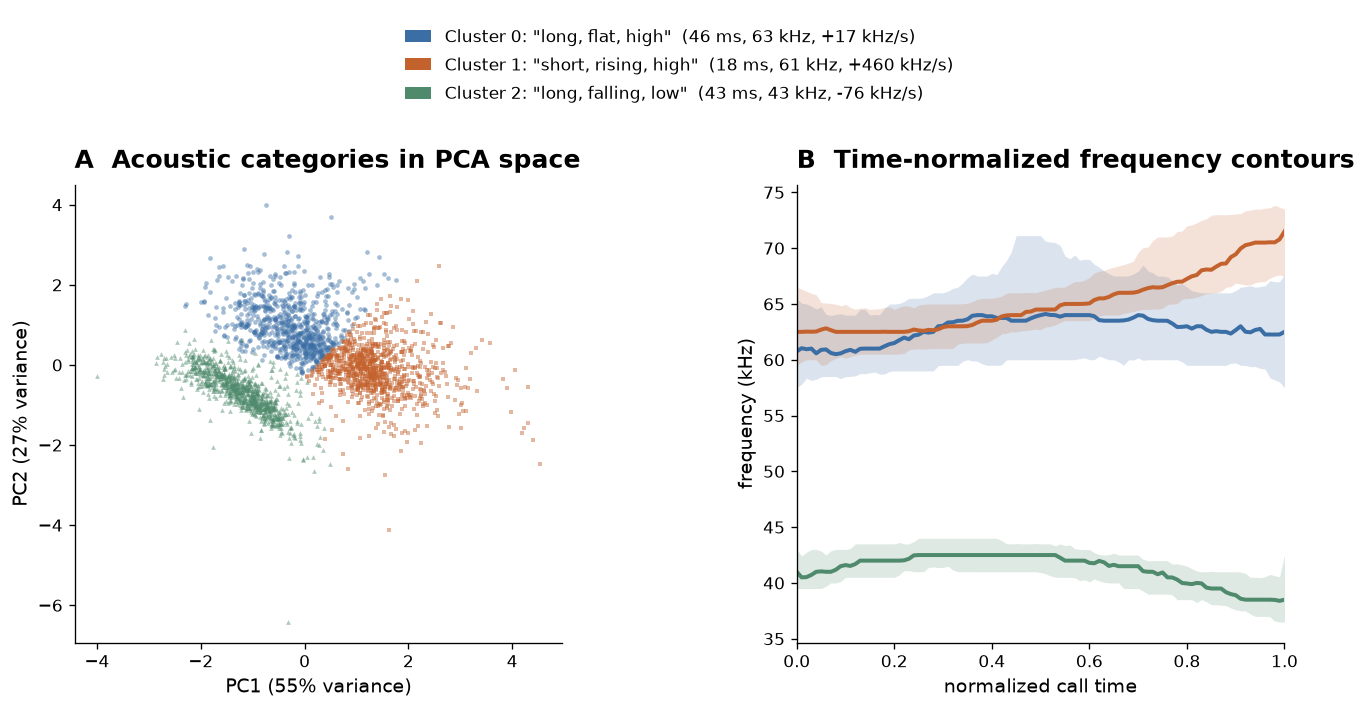

In [183]:
# ================================================================
# MAIN FIGURE 2 — Acoustic categories
# ================================================================

from matplotlib.patches import Patch

cluster_ids = sorted(
    int(c)
    for c in ok["cluster"].unique()
)

# ================================================================
# A. PCA
# ================================================================

pca2 = PCA(
    n_components=2,
    random_state=RANDOM_SEED
).fit(X)

XY = pca2.transform(X)


# ================================================================
# B. Median normalized contour + IQR
# ================================================================

N_MAIN_CONTOURS = 120
time_grid = np.linspace(0, 1, 101)

_main_noise_cache = {}


def _main_noise(label):
    if label not in _main_noise_cache:
        _main_noise_cache[label] = estimate_noise_reference(
            sessions[label],
            backgrounds[label]
        )
    return _main_noise_cache[label]


contour_summary = {}

for c in cluster_ids:

    rows_c = ok[
        ok["cluster"] == c
    ]

    sample = rows_c.sample(
        n=min(
            N_MAIN_CONTOURS,
            len(rows_c)
        ),
        random_state=RANDOM_SEED
    )

    interpolated = []

    for _, r in sample.iterrows():

        lab = r["session"]

        out = call_spectrogram(
            sessions[lab],
            float(r["call_time"]),
            backgrounds[lab]
        )

        if out is None:
            continue

        tc, f_khz, S = out

        frame_energy = S.max(axis=0)
        frame_freq = f_khz[
            np.argmax(S, axis=0)
        ]

        seg = _track_ridge(
            frame_energy,
            frame_freq,
            tc,
            _main_noise(lab)
        )

        if seg is None or len(seg["good"]) < 2:
            continue

        tp = tc[seg["good"]]
        fp = frame_freq[seg["good"]]

        span = tp.max() - tp.min()

        if span <= 0:
            continue

        u = (
            tp - tp.min()
        ) / span

        order = np.argsort(u)
        u = u[order]
        fp = fp[order]

        # Remove duplicate x values before interpolation
        u_unique, idx_unique = np.unique(
            u,
            return_index=True
        )

        fp_unique = fp[idx_unique]

        if len(u_unique) < 2:
            continue

        interpolated.append(
            np.interp(
                time_grid,
                u_unique,
                fp_unique
            )
        )

    curves = np.asarray(
        interpolated,
        dtype=float
    )

    contour_summary[c] = dict(
        median=np.nanmedian(curves, axis=0),
        q25=np.nanpercentile(curves, 25, axis=0),
        q75=np.nanpercentile(curves, 75, axis=0),
        n=len(curves)
    )


# ================================================================
# Layout
#
# One dedicated legend row spanning both panels.
# ================================================================

fig = plt.figure(
    figsize=(10.8, 5.8),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[0.24, 1],
    left=0.085,
    right=0.98,
    bottom=0.15,
    top=0.96,
    wspace=0.27,
    hspace=0.08
)

ax_leg = fig.add_subplot(
    gs[0, :]
)

ax_a = fig.add_subplot(
    gs[1, 0]
)

ax_b = fig.add_subplot(
    gs[1, 1]
)

ax_leg.axis("off")


# ================================================================
# Panel A
# ================================================================

for c in cluster_ids:

    m = labels == c

    ax_a.scatter(
        XY[m, 0],
        XY[m, 1],
        s=8,
        alpha=0.45,
        linewidths=0,
        color=cluster_color(c),
        marker=MARKERS[c % len(MARKERS)]
    )

ax_a.set_title(
    "A  Acoustic categories in PCA space",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_a.set_xlabel(
    f"PC1 ({pca2.explained_variance_ratio_[0]:.0%} variance)",
    fontsize=11.5
)

ax_a.set_ylabel(
    f"PC2 ({pca2.explained_variance_ratio_[1]:.0%} variance)",
    fontsize=11.5
)

ax_a.tick_params(
    axis="both",
    labelsize=10
)


# ================================================================
# Panel B
# ================================================================

for c in cluster_ids:

    s = contour_summary[c]

    ax_b.fill_between(
        time_grid,
        s["q25"],
        s["q75"],
        color=cluster_color(c),
        alpha=0.18,
        linewidth=0
    )

    ax_b.plot(
        time_grid,
        s["median"],
        color=cluster_color(c),
        linewidth=2.4
    )

ax_b.set_title(
    "B  Time-normalized frequency contours",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=10
)

ax_b.set_xlabel(
    "normalized call time",
    fontsize=11.5
)

ax_b.set_ylabel(
    "frequency (kHz)",
    fontsize=11.5
)

ax_b.set_xlim(
    0,
    1
)

ax_b.tick_params(
    axis="both",
    labelsize=10
)


# ================================================================
# Shared descriptive legend
# ================================================================

legend_handles = []

for c in cluster_ids:

    r = profile.loc[c]

    legend_handles.append(
        Patch(
            facecolor=cluster_color(c),
            edgecolor="none",
            label=(
                f'Cluster {c}: "{CLUSTER_NAMES[c]}"  '
                f'({r["duration_ms"]:.0f} ms, '
                f'{r["fm_intercept_khz"]:.0f} kHz, '
                f'{r["fm_slope_khz_per_s"]:+.0f} kHz/s)'
            )
        )
    )

ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=1,
    frameon=False,
    fontsize=10.3,
    handlelength=1.5,
    labelspacing=0.65
)

save_fig(
    fig,
    "main_acoustic_categories"
)

plt.show()

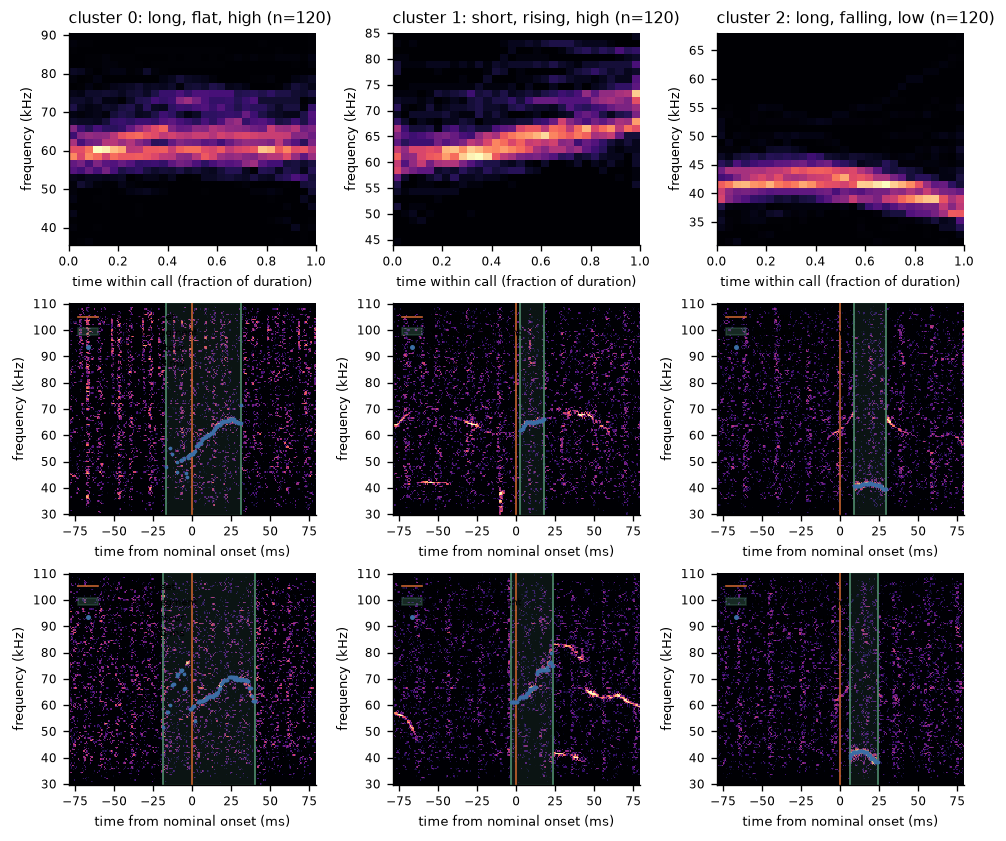

(built in 142s)
Top row pools the tracked contours of up to 120 calls per cluster after normalising each call's duration to the 0-1 range, so the panel shows the shape the cluster shares rather than the shape of one call. Rows below are individual calls drawn at their true timescale, sampled at random rather than picked for looking clean.


In [184]:
# What the calls in each cluster look like. Top row: where the tracked contours
# of many calls sit once each call's own duration is normalised out, so the
# shared shape is visible rather than one example's idiosyncrasies. Rows below:
# individual calls with the tracker's own output drawn on them.
N_CUMULATIVE, N_EXAMPLES = 120, 2
cluster_ids = sorted(int(c) for c in ok["cluster"].unique())
noise_cache = {}


def get_noise(lbl):
    if lbl not in noise_cache:
        noise_cache[lbl] = estimate_noise_reference(sessions[lbl], backgrounds[lbl])
    return noise_cache[lbl]


t0 = time.time()
fig, axes = plt.subplots(1 + N_EXAMPLES, len(cluster_ids),
                         figsize=(2.7 * len(cluster_ids), 2.3 * (1 + N_EXAMPLES)),
                         squeeze=False)
for col, cl in enumerate(cluster_ids):
    rows_cl = ok[ok["cluster"] == cl]
    sample = rows_cl.sample(n=min(N_CUMULATIVE, len(rows_cl)), random_state=RANDOM_SEED)
    norm_t, freqs = [], []
    for _, r in sample.iterrows():
        sess = sessions[r["session"]]
        out = call_spectrogram(sess, float(r["call_time"]), backgrounds[r["session"]])
        if out is None:
            continue
        tc, f_khz, S = out
        seg = _track_ridge(S.max(axis=0), f_khz[np.argmax(S, axis=0)], tc, get_noise(r["session"]))
        if seg is None or len(seg["good"]) < 2:
            continue
        tp = tc[seg["good"]]
        span = tp.max() - tp.min()
        if span <= 0:
            continue
        norm_t.append((tp - tp.min()) / span)
        freqs.append(f_khz[np.argmax(S, axis=0)][seg["good"]])

    ax = axes[0][col]
    if norm_t:
        ax.hist2d(np.concatenate(norm_t), np.concatenate(freqs), bins=[30, 30], cmap="magma")
    ax.set_xlabel("time within call (fraction of duration)")
    ax.set_ylabel("frequency (kHz)")
    label_only(ax, f"cluster {cl}: {CLUSTER_NAMES[cl]} (n={len(norm_t)})",
               loc="upper left", color="black")

    examples = rows_cl.sample(n=min(N_EXAMPLES, len(rows_cl)),
                              random_state=RANDOM_SEED + 1).reset_index(drop=True)
    for i in range(N_EXAMPLES):
        ax = axes[1 + i][col]
        if i >= len(examples):
            ax.axis("off")
            continue
        r = examples.loc[i]
        plot_call_panel(ax, sessions[r["session"]], float(r["call_time"]),
                        get_noise(r["session"]), backgrounds[r["session"]],
                        label=f"cluster {cl}, {r['duration_ms']:.0f} ms")
save_fig(fig, "09_cluster_examples")
plt.show()
print(f"(built in {time.time()-t0:.0f}s)")
print("Top row pools the tracked contours of up to "
      f"{N_CUMULATIVE} calls per cluster after normalising each call's duration to the "
      "0-1 range, so the panel shows the shape the cluster shares rather than the shape "
      "of one call. Rows below are individual calls drawn at their true timescale, "
      "sampled at random rather than picked for looking clean.")

### Comparing the clusters on their acoustic features

The first cell of §9 runs a **pairwise loop**: for every feature used for
clustering and every pair of clusters, it compares the two clusters' values for
that feature with the **Mann-Whitney U test** — a rank-based test of whether
values drawn from one cluster tend to exceed values from the other — and reports
**Cliff's delta** as the effect size. p-values are Holm-corrected across the
pairwise family.

*Cliff's delta* ("cliffs_delta" in the table) is a non-parametric measure of
separation: the probability that a randomly drawn value from cluster A exceeds one
from cluster B, minus the probability of the reverse. It runs from -1 to +1; 0
means the two distributions overlap completely and +/-1 means they do not overlap
at all. The bands shown use the conventional |delta| = 0.15 / 0.33 / 0.47 cut-offs
for small / medium / large.

This is **descriptive validation, not independent proof**. The clusters were
produced by K-Means on these same features, so the fact that they differ on them
is true by construction and the p-values carry no evidential weight. What the
table adds is *which* feature separates *which* pair and by how much — whether a
cluster is set apart mainly by duration, by starting pitch, or by FM slope. A test
that the categories carry meaning beyond the feature space has to come from
outside it; the neural decoding in §11-§13 is that test.


## 10. Building the neural design matrix

One row per labelled call. The features are the population spike counts in the
window **ending at the call onset**: the window is split into `N_BINS` equal
sub-bins and each cell contributes its mean count per sub-bin, giving
`n_cells x N_BINS` columns. The window is strictly past-only — a window straddling
the call would measure activity during vocal production, which is a different
question from whether activity anticipates the call.

Three constraints on how this is evaluated:

- **Grouping.** Calls in the same bout are seconds apart, share overlapping
  look-back windows, and tend to share a type. Cross-validation is grouped by
  `bout_id` so a bout never appears on both sides of a split. The within-bout label
  agreement rate is computed below rather than quoted.
- **Blocking.** Folds are contiguous in time, not random, and training samples whose
  own window falls within a gap of the test block are dropped.
- **Inclusion.** A session enters decoding only if it has at least
  `MIN_EVENTS_FOR_DECODING` *usable* labelled calls — counted from the quality flag
  in §6, not from the raw detection count, so a session with many detections but few
  trackable calls does not slip in.

In [185]:
agree = []
for (sess, bout), g in ok.groupby(["session", "bout_id"]):
    if len(g) > 1:
        agree.append((g["cluster"].value_counts().iloc[0] - 1) / (len(g) - 1))
within_bout_agreement = float(np.mean(agree))

inclusion = (ok.groupby("session")
             .agg(usable_calls=("cluster", "size"), n_classes=("cluster", "nunique"))
             .join(features.groupby("session").size().rename("detected_calls"))
             .join(ok.groupby("session")["bout_id"].nunique().rename("bouts")))
inclusion["included"] = ((inclusion["usable_calls"] >= MIN_EVENTS_FOR_DECODING)
                         & (inclusion["n_classes"] >= 2))
display(inclusion[["detected_calls", "usable_calls", "bouts", "n_classes", "included"]])

DECODE_SESSIONS = list(inclusion.index[inclusion["included"]])
print(f"\nWithin-bout call-type agreement: {within_bout_agreement:.1%}. Calls in the same "
      "bout share a type far more often than chance, which is why bouts are kept whole "
      "across folds and why the null below preserves the label sequence's own structure.")
print(f"\nSessions entering decoding ({len(DECODE_SESSIONS)}): {', '.join(DECODE_SESSIONS)}")
_excl = inclusion[~inclusion["included"]]
if len(_excl):
    print("Excluded: " + ", ".join(f"{s} ({r.usable_calls} usable)"
                                   for s, r in _excl.iterrows()))

,detected_calls,usable_calls,bouts,n_classes,included
session,,,,,
M2_F1,14,2,2,1,False
M2_F2,8,1,1,1,False
M3_F2,2,1,1,1,False
M3_F4,5,3,2,1,False
M6_F1,32,29,18,3,False
M7_F1,779,574,115,3,True
M7_F2,941,727,136,3,True
M7_F3,1125,841,148,3,True
M7_F4,134,129,65,3,True



Within-bout call-type agreement: 59.2%. Calls in the same bout share a type far more often than chance, which is why bouts are kept whole across folds and why the null below preserves the label sequence's own structure.

Sessions entering decoding (7): M7_F1, M7_F2, M7_F3, M7_F4, M8_F2, M8_F3, M8_F4
Excluded: M2_F1 (2 usable), M2_F2 (1 usable), M3_F2 (1 usable), M3_F4 (3 usable), M6_F1 (29 usable), M8_F1 (1 usable)


In [186]:
def cells_in_group(session, group):
    """Row indices into the spike matrix for one recording-target group. The two
    animals were implanted in different regions, so cells are grouped by the
    prefix of the area label rather than by the label itself."""
    is_pfc = np.array([str(a).startswith(PFC_PREFIXES) for a in session.cell_area])
    return {"all": np.arange(len(is_pfc)), "pfc": np.where(is_pfc)[0],
            "other": np.where(~is_pfc)[0]}[group]


def neural_matrix(session, event_times, look_back_s, n_bins, t_offset_s=0.0,
                  cell_idx=None):
    """Rows = events, columns = n_cells blocks per sub-bin, earliest bin first.
    Default places the window at [t - look_back_s, t]; t_offset_s = look_back_s
    places it at [t, t + look_back_s] instead. `cell_idx` restricts to a subset
    of recorded cells."""
    spikes = session.spikes if cell_idx is None else session.spikes[cell_idx, :]
    n_cells = spikes.shape[0]
    width = look_back_s / n_bins
    Xn = np.full((len(event_times), n_cells * n_bins), np.nan)
    for i, t in enumerate(event_times):
        for b in range(n_bins):
            t0 = t + t_offset_s - look_back_s + b * width
            m = (session.frame_t >= t0) & (session.frame_t < t0 + width)
            if m.any():
                Xn[i, b * n_cells:(b + 1) * n_cells] = spikes[:, m].mean(axis=1)
    return Xn


def call_dataset(session_label, label_col="cluster", look_back_s=LOOK_BACK_S,
                 n_bins=N_BINS, t_offset_s=0.0, labels_df=None, cell_group="all"):
    src = ok if labels_df is None else labels_df
    sub = src[src["session"] == session_label]
    s = sessions[session_label]
    Xn = neural_matrix(s, sub["call_time"].values, look_back_s, n_bins, t_offset_s,
                       cell_idx=cells_in_group(s, cell_group))
    good = ~np.isnan(Xn).any(axis=1)
    return (Xn[good], sub[label_col].values[good],
            sub["call_time"].values[good], sub["bout_id"].values[good])


def state_dataset(session_label, window_s=STATE_WINDOW_S):
    """Positive control: tile the encounter with non-overlapping windows and label
    each one by whether it contains a call. Restricted to the encounter period so
    the contrast is calling vs. not calling, not female-present vs. female-absent."""
    s = sessions[session_label]
    lo, hi = s.call_times.min(), s.call_times.max()
    ends = np.arange(lo + window_s, hi, window_s)
    y = np.array([np.any((s.call_times >= e - window_s) & (s.call_times < e))
                  for e in ends]).astype(int)
    Xn = neural_matrix(s, ends, look_back_s=window_s, n_bins=1)
    good = ~np.isnan(Xn).any(axis=1)
    return Xn[good], y[good], ends[good], np.arange(len(ends))[good]


_X, _y, _t, _g = call_dataset(DECODE_SESSIONS[0])
print(f"{DECODE_SESSIONS[0]}: design matrix {_X.shape[0]} calls x {_X.shape[1]} features "
      f"({sessions[DECODE_SESSIONS[0]].spikes.shape[0]} cells x {N_BINS} sub-bins), "
      f"{len(np.unique(_g))} bouts, class counts {np.bincount(_y).tolist()}.")
print(f"\nWith far more features than samples, the classifier is preceded by PCA to "
      f"{PCA_COMPONENTS} components, refit inside every fold so nothing from the held-out "
      "block reaches the projection.")

M7_F1: design matrix 574 calls x 332 features (166 cells x 2 sub-bins), 115 bouts, class counts [146, 202, 226].

With far more features than samples, the classifier is preceded by PCA to 10 components, refit inside every fold so nothing from the held-out block reaches the projection.


## 11. Evaluation protocol and model selection

**Scoring metric.** All classifiers are fit with balanced class weights, so they
trade accuracy for class balance by design. Testing them on accuracy would score
them against a criterion they were not optimised for, and they would lose by
construction. Macro-F1 is what every significance test below uses; accuracy is
reported beside it as a secondary column.

**Baselines.** Two majority numbers, not one. The *training-fold majority* is
what a real baseline model can predict, since it cannot see test labels. The
*test-fold majority rate* is the true chance floor for that fold. They come
apart whenever class composition drifts across a session, and a gap between them
is itself worth reading.

**Null.** A circular shift: the time-ordered label sequence is rolled by a random
non-zero offset while the neural data stays put. This destroys the true pairing
with neural activity but keeps the label sequence's own autocorrelation, which
matters here because consecutive calls in a bout usually share a type. A plain
label shuffle would discard that structure and give an easier, less honest null.

**Model and hyperparameters.** Three classifiers from different families —
regularised logistic regression, a random forest and an RBF SVM — are compared
below on identical folds and identical preprocessing, so the only thing that
differs is the decision rule. If the relationship between population activity and
call type is non-linear, a linear model alone would miss it, and running all three
is what rules that out.

Their hyperparameters are selected by a nested inner cross-validation inside each
training block only. Choosing them on the same folds a score is reported from
would leak, and the reported score would be inflated. Once selected they are
fixed, and the same fixed pipeline is applied to the observed data and to every
null draw, so the null remains a fair reference.

**Multiple comparisons.** Every family of tests is corrected with
Benjamini-Hochberg FDR, and q-values, not raw p-values, are what conclusions are
read from. With 1000 shuffles a single p-value cannot fall below
1/1001 ≈ 0.001, which keeps a corrected q below 0.05 achievable for the family
sizes used here — a test that could not in principle return a positive result
could not support a negative one either.

In [187]:
def blocked_group_splits(times, groups, n_splits=CV_SPLITS, gap_s=None):
    """Contiguous, time-ordered folds over *groups*: every sample of a group lands
    in the same fold. Training groups within gap_s of the test block's time range
    are dropped, so no training window overlaps a test window."""
    gap_s = (LOOK_BACK_S + CV_GAP_MARGIN_S) if gap_s is None else gap_s
    uniq, first = np.unique(groups, return_index=True)
    gt = times[first]
    order = np.argsort(gt)
    ug, ut = uniq[order], gt[order]
    bounds = np.linspace(0, len(ug), n_splits + 1).astype(int)
    for i in range(n_splits):
        test_groups = set(ug[bounds[i]:bounds[i + 1]])
        if not test_groups:
            continue
        tt = ut[bounds[i]:bounds[i + 1]]
        keep = (gt < tt.min() - gap_s) | (gt > tt.max() + gap_s)
        train_groups = set(uniq[keep])
        in_train = np.fromiter((g in train_groups for g in groups), bool, len(groups))
        in_test = np.fromiter((g in test_groups for g in groups), bool, len(groups))
        yield np.where(in_train)[0], np.where(in_test)[0]


def build_model(kind, n_components=PCA_COMPONENTS, **params):
    """Standardise, project onto a few principal components, classify. The
    projection is part of the pipeline so it is refit inside every fold and never
    sees held-out data."""
    clf = {
        "logistic": lambda: LogisticRegression(max_iter=2000, class_weight="balanced",
                                               C=params.get("C", 1.0)),
        "random_forest": lambda: RandomForestClassifier(
            n_estimators=200, class_weight="balanced", max_depth=params.get("max_depth"),
            random_state=RANDOM_SEED, n_jobs=1),
        "svm_rbf": lambda: SVC(kernel="rbf", class_weight="balanced",
                               C=params.get("C", 1.0), gamma="scale",
                               random_state=RANDOM_SEED),
    }[kind]()
    return make_pipeline(StandardScaler(),
                         PCA(n_components=n_components, random_state=RANDOM_SEED), clf)


def model_candidates(kind):
    grid = PARAM_GRID[kind]
    keys = list(grid)
    for n_comp in PCA_GRID:
        for vals in itertools.product(*[grid[k] for k in keys]):
            yield dict(n_components=n_comp, **dict(zip(keys, vals)))


# Selected in §12; until then the defaults stand.
BEST_MODEL, BEST_PARAMS = "logistic", dict(n_components=PCA_COMPONENTS)


def make_model(kind=None, **override):
    """The pipeline used everywhere downstream: the model chosen in §11 with the
    hyperparameters chosen there, unless explicitly overridden."""
    kind = BEST_MODEL if kind is None else kind
    params = dict(BEST_PARAMS) if kind == BEST_MODEL else dict(n_components=PCA_COMPONENTS)
    params.update(override)
    return build_model(kind, **params)


def nested_cv(Xn, y, times, groups, kind, gap_s=None):
    """Outer blocked CV for scoring; inside each outer training block a further
    blocked CV picks the hyperparameters. The outer test block takes no part in
    the choice, so the returned score is not inflated by the search."""
    yt, yp, picks = [], [], []
    for tr, te in blocked_group_splits(times, groups, gap_s=gap_s):
        if len(tr) == 0 or len(te) == 0 or len(np.unique(y[tr])) < 2:
            continue
        best, best_score = None, -np.inf
        for cand in model_candidates(kind):
            if cand["n_components"] >= min(len(tr), Xn.shape[1]):
                continue
            inner = []
            for itr, ite in blocked_group_splits(times[tr], groups[tr],
                                                 n_splits=INNER_CV_SPLITS, gap_s=gap_s):
                if len(itr) == 0 or len(ite) == 0 or len(np.unique(y[tr][itr])) < 2:
                    continue
                m = build_model(kind, **cand).fit(Xn[tr][itr], y[tr][itr])
                inner.append(macro_f1(y[tr][ite], m.predict(Xn[tr][ite])))
            if inner and np.mean(inner) > best_score:
                best_score, best = float(np.mean(inner)), cand
        if best is None:
            continue
        m = build_model(kind, **best).fit(Xn[tr], y[tr])
        yp.append(m.predict(Xn[te])); yt.append(y[te]); picks.append(best)
    if not yt:
        return dict(macro_f1=np.nan, accuracy=np.nan, picks=[])
    yt, yp = np.concatenate(yt), np.concatenate(yp)
    return dict(macro_f1=macro_f1(yt, yp), accuracy=accuracy_score(yt, yp), picks=picks)


def macro_f1(a, b):
    return f1_score(a, b, average="macro")


def cv_predict(Xn, y, times, groups, model, gap_s=None):
    yt, yp, ym = [], [], []
    for tr, te in blocked_group_splits(times, groups, gap_s=gap_s):
        if len(tr) == 0 or len(te) == 0 or len(np.unique(y[tr])) < 2:
            continue
        m = clone(model).fit(Xn[tr], y[tr])
        yp.append(m.predict(Xn[te])); yt.append(y[te])
        vals, cnt = np.unique(y[tr], return_counts=True)
        ym.append(np.full(len(te), vals[np.argmax(cnt)]))
    return np.concatenate(yt), np.concatenate(yp), np.concatenate(ym)


def test_fold_majority_rate(y, times, groups, gap_s=None):
    ok_n = tot = 0
    for _, te in blocked_group_splits(times, groups, gap_s=gap_s):
        if len(te) == 0:
            continue
        tot += len(te); ok_n += int(np.bincount(y[te]).max())
    return ok_n / tot if tot else np.nan


def circular_null(Xn, y, times, groups, model, n=N_NULL_SHUFFLES, gap_s=None,
                  seed=RANDOM_SEED):
    """Roll the time-ordered label sequence by a random non-zero offset and refit.
    Offsets are drawn once from a seeded generator, so the result is identical
    whether or not the shuffles run in parallel."""
    order = np.argsort(times)
    y_ord = y[order]
    folds = list(blocked_group_splits(times, groups, gap_s=gap_s))
    offsets = np.random.default_rng(seed).integers(1, len(y), size=n)

    # Standardisation and PCA never look at the labels, so within a fold they are
    # the same fit for every shuffle. Fitting them once per fold instead of once
    # per fold per shuffle is an exact restructuring, not an approximation: each
    # projection is still fitted on training-fold data only, exactly as in the
    # real run. Only the classifier is refit per shuffle.
    prep, clf = model[:-1], model[-1]
    prepped = []
    for tr, te in folds:
        if len(tr) == 0 or len(te) == 0:
            continue
        pp = clone(prep).fit(Xn[tr])
        prepped.append((tr, te, pp.transform(Xn[tr]), pp.transform(Xn[te])))

    def one(offset):
        y_roll = np.empty_like(y)
        y_roll[order] = np.roll(y_ord, offset)
        yt, yp = [], []
        for tr, te, Xtr, Xte in prepped:
            if len(np.unique(y_roll[tr])) < 2:
                continue
            m = clone(clf).fit(Xtr, y_roll[tr])
            yp.append(m.predict(Xte)); yt.append(y_roll[te])
        return macro_f1(np.concatenate(yt), np.concatenate(yp)) if yt else np.nan

    return np.array(Parallel(n_jobs=-1)(delayed(one)(int(o)) for o in offsets))


def bh_fdr(p):
    p = np.asarray(p, float); n = len(p); order = np.argsort(p)
    q = p[order] * n / (np.arange(n) + 1)
    q = np.clip(np.minimum.accumulate(q[::-1])[::-1], 0, 1)
    out = np.empty(n); out[order] = q
    return out


def run_test(Xn, y, times, groups, model, with_null=True, n_null=N_NULL_SHUFFLES,
             gap_s=None):
    yt, yp, ym = cv_predict(Xn, y, times, groups, model, gap_s)
    res = dict(n=len(yt), n_classes=int(len(np.unique(y))),
               accuracy=accuracy_score(yt, yp), macro_f1=macro_f1(yt, yp),
               majority_trainfold=accuracy_score(yt, ym),
               majority_testfold=test_fold_majority_rate(y, times, groups, gap_s))
    if with_null:
        null = circular_null(Xn, y, times, groups, model, n_null, gap_s)
        null = null[~np.isnan(null)]
        res["p_circular"] = (np.sum(null >= res["macro_f1"]) + 1) / (len(null) + 1)
        res["_null"] = null
        res["_y_true"], res["_y_pred"] = yt, yp
    return res

In [188]:
t0 = time.time()
comp_rows = []
for kind in ("logistic", "random_forest", "svm_rbf"):
    for lab in DECODE_SESSIONS:
        def _run(kind=kind, lab=lab):
            Xn, y, tt, gg = call_dataset(lab)
            return nested_cv(Xn, y, tt, gg, kind)
        r = cached(f"nested_{kind}_{lab}", _run)
        comp_rows.append(dict(model=kind, session=lab,
                              macro_f1=r["macro_f1"], accuracy=r["accuracy"],
                              picks=r["picks"]))
comparison = pd.DataFrame(comp_rows)
show(comparison.pivot_table(index="model", columns="session", values="macro_f1"))

model_means = comparison.groupby("model")["macro_f1"].mean().sort_values(ascending=False)
wins = (comparison.pivot_table(index="session", columns="model", values="macro_f1")
        .idxmax(axis=1).value_counts())

# Tie-break fixed in advance: the best mean wins, but a lead of 0.01 or less over
# the linear model is not worth a more expensive model.
BEST_MODEL = model_means.index[0]
if model_means.iloc[0] - model_means["logistic"] <= 0.01:
    BEST_MODEL = "logistic"

# One fixed configuration is carried forward: the one the inner search chose most
# often for the winning model, across every outer fold of every session.
all_picks = [tuple(sorted(pk.items())) for r in comp_rows if r["model"] == BEST_MODEL
             for pk in r["picks"]]
BEST_PARAMS = dict(collections.Counter(all_picks).most_common(1)[0][0])

print(f"(elapsed {time.time()-t0:.0f}s)\n")
print("Mean macro-F1 across sessions: " +
      ", ".join(f"{m} {v:.3f}" for m, v in model_means.items()))
print("Sessions won: " + ", ".join(f"{m} {n}" for m, n in wins.items())
      + f" (of {len(DECODE_SESSIONS)}).")
_won = int(wins.get(BEST_MODEL, 0))
print(f"\n{BEST_MODEL} is carried forward, on a mean lead of "
      f"{model_means.iloc[0]-model_means.iloc[1]:.3f} macro-F1 over the runner-up and "
      f"{_won}/{len(DECODE_SESSIONS)} sessions won.")
print(f"Hyperparameters selected by the nested search, most frequent choice across "
      f"{len(all_picks)} outer folds: " +
      ", ".join(f"{k}={v}" for k, v in BEST_PARAMS.items()) + ".")
_maj = comparison.merge(
    pd.DataFrame([dict(session=l, floor=run_test(*call_dataset(l), model=make_model(),
                                                 with_null=False)["majority_testfold"])
                  for l in DECODE_SESSIONS]), on="session", how="left")
print("\nTest-fold chance floor per session (accuracy): " +
      ", ".join(f"{r.session} {r.floor:.2f}" for r in
                _maj.drop_duplicates("session").itertuples())
      + ". Macro-F1 is not directly comparable to these, which is why significance is "
      "decided against the null distribution in §13 rather than against a baseline number.")

session,M7_F1,M7_F2,M7_F3,M7_F4,M8_F2,M8_F3,M8_F4
model,,,,,,,
logistic,0.370,0.369,0.370,0.345,0.416,0.356,0.286
random_forest,0.349,0.349,0.374,0.305,0.346,0.281,0.290
svm_rbf,0.313,0.348,0.344,0.372,0.282,0.275,0.303


(elapsed 505s)

Mean macro-F1 across sessions: logistic 0.359, random_forest 0.328, svm_rbf 0.320
Sessions won: logistic 4, svm_rbf 2, random_forest 1 (of 7).

logistic is carried forward, on a mean lead of 0.031 macro-F1 over the runner-up and 4/7 sessions won.
Hyperparameters selected by the nested search, most frequent choice across 35 outer folds: C=0.01, n_components=20.

Test-fold chance floor per session (accuracy): M7_F1 0.56, M7_F2 0.46, M7_F3 0.43, M7_F4 0.76, M8_F2 0.71, M8_F3 0.52, M8_F4 0.73. Macro-F1 is not directly comparable to these, which is why significance is decided against the null distribution in §13 rather than against a baseline number.


**Interpretation.** Three classifier families — regularised logistic regression,
random forest, RBF SVM — are compared on identical folds and preprocessing, with
hyperparameters chosen by a nested inner CV on training folds only. The model
carried forward is the one with the best mean macro-F1, with a tie-break fixed in
advance toward the linear model when its lead is <= 0.01. The per-session win count
is read next to the mean: a thin mean lead with no session majority means the
three models are close to interchangeable here and the choice is made only because
one has to be. The selected configuration is then frozen and applied to the
observed data and to every null draw alike, so the null stays a fair reference.
All significance tests use macro-F1, not accuracy, because the classifiers are fit
with balanced class weights.


## 12. Positive controls

A negative decoding result has two possible explanations, and they lead to
opposite conclusions: either there is no call-type information in the pre-call
window, or this analysis is not sensitive enough to find information that is
there. A null result on its own cannot tell them apart.

A positive control runs the *identical* machinery — same neural features, same
blocked CV, same model and hyperparameters chosen in §11, same null — on a target
we expect to be decodable. If it passes, the pipeline can see a signal when one
exists, and a null on call type is about call type. If it fails, no claim about
the brain is available, and that is what gets reported.

Two controls, both using only neural activity and audio:

1. **Calling vs. quiet.** The encounter is tiled into half-second windows, each
   labelled by whether it contains a call. This is the coarsest
   vocalisation-related target there is — if population activity carries nothing
   about it, it is unlikely to carry the finer distinction between call types.
2. **Call type from the post-call window.** The same call-type target, but the
   neural window sits immediately *after* the call instead of before it. If
   acoustic categories have a neural correlate at all, it should be at least as
   visible during and just after vocal production as in anticipation of it.

In [189]:
t0 = time.time()
control_rows, control_nulls = [], {}
for lab in DECODE_SESSIONS:
    def _state(lab=lab):
        Xn, y, tt, gg = state_dataset(lab)
        return run_test(Xn, y, tt, np.arange(len(y)), make_model(),
                        gap_s=STATE_WINDOW_S + CV_GAP_MARGIN_S)

    def _post(lab=lab):
        return run_test(*call_dataset(lab, t_offset_s=LOOK_BACK_S), model=make_model())

    for name, fn, key in (("calling vs quiet", _state, "state"),
                          ("call type, post-call window", _post, "post")):
        r = cached(f"control_{key}_{lab}", fn)
        control_nulls[(key, lab)] = r.pop("_null"); r.pop("_y_true"); r.pop("_y_pred")
        control_rows.append(dict(control=name, session=lab, **r))

control = pd.DataFrame(control_rows)
control["q_bh"] = bh_fdr(control["p_circular"].values)
control["significant"] = control["q_bh"] < 0.05
show(control, floor=p_floor(N_NULL_SHUFFLES))

by_control = control.groupby("control")["significant"].agg(["sum", "size"])
CONTROL_PASSED = bool(control["significant"].any())
n_sig = int(control["significant"].sum())
print(f"\n(elapsed {time.time()-t0:.0f}s)")
for name, r in by_control.iterrows():
    print(f"  {name}: {int(r['sum'])}/{int(r['size'])} sessions significant after BH-FDR.")
if CONTROL_PASSED:
    print("\nThe pipeline detects a vocalisation-related signal when one is present, so "
          "a null result on the pre-call call-type target below is a statement about that "
          "target rather than about the machinery.")
else:
    print("\nNeither control passes at the level of a single session. Section 14 asks the "
          "same question of the combined evidence across sessions, which is the more "
          "powerful test and the one that decides whether these nulls are interpretable.")

,control,session,n,n_classes,accuracy,macro_f1,majority_trainfold,majority_testfold,p_circular,q_bh,significant
0,calling vs quiet,M7_F1,596,2,0.607,0.603,0.594,0.624,0.0150,0.1958,False
1,"call type, post-call window",M7_F1,574,3,0.439,0.387,0.260,0.563,0.3447,0.4551,False
2,calling vs quiet,M7_F2,639,2,0.562,0.557,0.640,0.640,0.0509,0.1958,False
3,"call type, post-call window",M7_F2,727,3,0.370,0.365,0.442,0.462,0.0739,0.1958,False
4,calling vs quiet,M7_F3,628,2,0.589,0.552,0.744,0.744,0.0839,0.1958,False
5,"call type, post-call window",M7_F3,841,3,0.389,0.353,0.404,0.433,0.2897,0.4551,False
6,calling vs quiet,M7_F4,552,2,0.734,0.566,0.841,0.841,0.0619,0.1958,False
7,"call type, post-call window",M7_F4,129,3,0.589,0.366,0.760,0.760,0.2727,0.4551,False
8,calling vs quiet,M8_F2,593,2,0.562,0.499,0.668,0.695,0.4226,0.4551,False
9,"call type, post-call window",M8_F2,119,3,0.496,0.355,0.588,0.714,0.4016,0.4551,False



(elapsed 135s)
  call type, post-call window: 0/7 sessions significant after BH-FDR.
  calling vs quiet: 0/7 sessions significant after BH-FDR.

Neither control passes at the level of a single session. Section 14 asks the same question of the combined evidence across sessions, which is the more powerful test and the one that decides whether these nulls are interpretable.


## 13. Significance and robustness

Four questions, all answered with the same machinery.

1. **Does the chosen model beat its circular null on call type?** Run across
   K = 2, 3 and 4. These are independently fitted partitions, not nested ones, so
   they are genuinely different targets; a result that appears at only one K is a
   result about that K.
2. **Does the answer depend on the neural window?** The look-back is swept over
   0.5 s, 1 s and 2 s at matched sub-bin widths.
3. **What do the sessions say taken together?** Everything above asks whether a
   *single* session is strong enough on its own to survive correction across the
   whole family. That is the most conservative question available, and with a few
   hundred events per session also the least powerful. Fisher's and Stouffer's
   methods combine independent p-values into one test of the pooled evidence, and
   the sessions are separate recordings, so combining is legitimate. This is
   reported as a clearly-labelled **secondary** analysis — the per-session result
   stays primary — and is corrected across the three values of K.
4. **Where do the errors go?** Confusion matrices for the primary configuration.

All p-values from the K sweep are corrected together as one family, since they were
all generated in one search.

In [190]:
t0 = time.time()
decode_rows, decode_nulls, decode_preds = [], {}, {}
labels_by_k = {}
for k in DECODING_K_SWEEP:
    km_k = KMeans(k, n_init=10, random_state=RANDOM_SEED).fit(X)
    lab_k = ok.copy()
    lab_k[f"cluster_k{k}"] = km_k.labels_
    labels_by_k[k] = lab_k
    for lab in DECODE_SESSIONS:
        def _run(k=k, lab=lab, lab_k=lab_k):
            Xn, y, tt, gg = call_dataset(lab, label_col=f"cluster_k{k}", labels_df=lab_k)
            return run_test(Xn, y, tt, gg, make_model())
        r = cached(f"decode_{BEST_MODEL}_K{k}_{lab}", _run)
        decode_nulls[(k, lab)] = r.pop("_null")
        decode_preds[(k, lab)] = (r.pop("_y_true"), r.pop("_y_pred"))
        decode_rows.append(dict(K=k, session=lab, **r))
    print(f"  K={k} done ({time.time()-t0:.0f}s elapsed)")

decode = pd.DataFrame(decode_rows)
decode["q_bh"] = bh_fdr(decode["p_circular"].values)
decode["significant"] = decode["q_bh"] < 0.05
show(decode, floor=p_floor(N_NULL_SHUFFLES))

n_sig_decode = int(decode["significant"].sum())
print(f"\n{n_sig_decode}/{len(decode)} (K x session) tests significant after BH-FDR "
      f"across the whole sweep. The p-value floor at {N_NULL_SHUFFLES} shuffles is "
      f"{p_floor(N_NULL_SHUFFLES):.4f}, so the smallest q this family of {len(decode)} "
      f"tests can return is {p_floor(N_NULL_SHUFFLES)*len(decode):.3f} -- comfortably "
      "below 0.05, meaning a positive result was reachable in principle.")
if n_sig_decode == 0:
    print("No configuration of K, session or model beats a null that preserves the "
          "label sequence's own temporal structure. Read together with §11, this is the "
          "central result of the analysis.")
else:
    print("Significant configurations: " + ", ".join(
        f"K={int(r.K)} {r.session} (macro-F1 {r.macro_f1:.3f}, q={r.q_bh:.3f})"
        for r in decode[decode["significant"]].itertuples()))

  K=2 done (35s elapsed)
  K=3 done (86s elapsed)
  K=4 done (141s elapsed)


,K,session,n,n_classes,accuracy,macro_f1,majority_trainfold,majority_testfold,p_circular,q_bh,significant
0,2,M7_F1,574,2,0.589,0.509,0.578,0.672,0.5854,0.7995,False
1,2,M7_F2,727,2,0.508,0.506,0.541,0.564,0.2757,0.6105,False
2,2,M7_F3,841,2,0.520,0.520,0.395,0.605,0.4326,0.7570,False
3,2,M7_F4,129,2,0.791,0.531,0.860,0.860,0.3457,0.6599,False
4,2,M8_F2,119,2,0.664,0.564,0.697,0.773,0.1978,0.6105,False
5,2,M8_F3,136,2,0.478,0.475,0.632,0.632,0.6733,0.7995,False
6,2,M8_F4,129,2,0.713,0.464,0.837,0.837,0.7263,0.8027,False
7,3,M7_F1,574,3,0.378,0.333,0.260,0.563,0.6394,0.7995,False
8,3,M7_F2,727,3,0.399,0.392,0.442,0.462,0.0020,0.0420,True
9,3,M7_F3,841,3,0.373,0.370,0.404,0.433,0.1179,0.4951,False



1/21 (K x session) tests significant after BH-FDR across the whole sweep. The p-value floor at 1000 shuffles is 0.0010, so the smallest q this family of 21 tests can return is 0.021 -- comfortably below 0.05, meaning a positive result was reachable in principle.
Significant configurations: K=3 M7_F2 (macro-F1 0.392, q=0.042)


In [191]:
t0 = time.time()
window_rows = []
for lb, nb in LOOK_BACK_SWEEP:
    for lab in DECODE_SESSIONS:
        def _run(lb=lb, nb=nb, lab=lab):
            Xn, y, tt, gg = call_dataset(lab, look_back_s=lb, n_bins=nb)
            return run_test(Xn, y, tt, gg, make_model(), gap_s=lb + CV_GAP_MARGIN_S)
        r = dict(cached(f"window_{BEST_MODEL}_{lb}_{lab}", _run))
        r.pop("_null"); r.pop("_y_true"); r.pop("_y_pred")
        window_rows.append(dict(look_back_s=lb, n_bins=nb, session=lab, **r))
windows = pd.DataFrame(window_rows)
windows["q_bh"] = bh_fdr(windows["p_circular"].values)
windows["significant"] = windows["q_bh"] < 0.05
show(windows, floor=p_floor(N_NULL_SHUFFLES))
print(f"(elapsed {time.time()-t0:.0f}s)")
print(f"\n{int(windows['significant'].sum())}/{len(windows)} window configurations "
      f"significant after BH-FDR. Best mean macro-F1 at look-back "
      f"{windows.groupby('look_back_s')['macro_f1'].mean().idxmax()} s.")
print("The look-back was swept as a robustness check, not to pick a winner: because "
      "these tests come from a search, they are corrected together, and the best cell "
      "in a corrected table is not a result on its own.")

,look_back_s,n_bins,session,n,n_classes,accuracy,macro_f1,majority_trainfold,majority_testfold,p_circular,q_bh,significant
0,0.5,1,M7_F1,574,3,0.390,0.336,0.260,0.563,0.6214,0.7898,False
1,0.5,1,M7_F2,727,3,0.371,0.369,0.442,0.462,0.0410,0.2867,False
2,0.5,1,M7_F3,841,3,0.354,0.353,0.404,0.433,0.2817,0.5979,False
3,0.5,1,M7_F4,129,3,0.636,0.331,0.760,0.760,0.5365,0.7898,False
4,0.5,1,M8_F2,119,3,0.462,0.345,0.588,0.714,0.4056,0.7714,False
5,0.5,1,M8_F3,136,3,0.360,0.312,0.412,0.522,0.6034,0.7898,False
6,0.5,1,M8_F4,129,3,0.504,0.325,0.721,0.729,0.4705,0.7714,False
7,1.0,2,M7_F1,574,3,0.378,0.333,0.260,0.563,0.6394,0.7898,False
8,1.0,2,M7_F2,727,3,0.399,0.392,0.442,0.462,0.0020,0.0420,True
9,1.0,2,M7_F3,841,3,0.373,0.370,0.404,0.433,0.1179,0.4126,False


(elapsed 152s)

1/21 window configurations significant after BH-FDR. Best mean macro-F1 at look-back 1.0 s.
The look-back was swept as a robustness check, not to pick a winner: because these tests come from a search, they are corrected together, and the best cell in a corrected table is not a result on its own.


In [205]:
# ================================================================
# Secondary pooled analysis across recording sessions
#
# This is a secondary recording-level summary.
# Sessions are not treated as independent animal replicates.
# ================================================================

def combine_p(pvals):
    """Fisher and Stouffer combinations of finite p-values."""
    p = np.asarray(pvals, dtype=float)
    p = np.clip(
        p[~np.isnan(p)],
        1e-12,
        1.0
    )

    return (
        stats.combine_pvalues(
            p,
            method="fisher"
        ).pvalue,

        stats.combine_pvalues(
            p,
            method="stouffer"
        ).pvalue
    )


rows = []


# ------------------------------------------------
# Call-type decoding: K = 2, 3, 4
# ------------------------------------------------

for k in DECODING_K_SWEEP:

    sub = decode[
        decode["K"] == k
    ]

    f, st = combine_p(
        sub["p_circular"].values
    )

    rows.append(
        dict(
            family="call type",
            target=f"K = {k}",
            n_sessions=len(sub),
            p_fisher=f,
            p_stouffer=st
        )
    )


# ------------------------------------------------
# Positive controls
# ------------------------------------------------

for name, grp in control.groupby(
    "control"
):

    f, st = combine_p(
        grp["p_circular"].values
    )

    rows.append(
        dict(
            family="positive control",
            target=name,
            n_sessions=len(grp),
            p_fisher=f,
            p_stouffer=st
        )
    )


combined = pd.DataFrame(
    rows
)


# BH correction is performed separately within each analysis family.
combined["q_fisher"] = np.nan

for fam, grp in combined.groupby(
    "family"
):

    combined.loc[
        grp.index,
        "q_fisher"
    ] = bh_fdr(
        grp["p_fisher"].values
    )


combined["significant"] = (
    combined["q_fisher"] < 0.05
)


show(
    combined
)


# ================================================================
# Notebook interpretation
# ================================================================

_ct = combined[
    combined["family"] == "call type"
]

_cc = combined[
    combined["family"] == "positive control"
]


print(
    f"Call type, pooled across {len(DECODE_SESSIONS)} recording sessions "
    f"and corrected across {len(_ct)} K values: "
    f"{int(_ct['significant'].sum())}/{len(_ct)} significant."
)

print(
    f"Positive controls, pooled across recording sessions and corrected "
    f"as their own family: "
    f"{int(_cc['significant'].sum())}/{len(_cc)} significant."
)


CONTROL_PASSED_COMBINED = bool(
    _cc["significant"].any()
)


if CONTROL_PASSED_COMBINED:

    print(
        "\nAt least one positive control passes in the secondary pooled "
        "recording-level analysis. The per-session analyses remain primary."
    )

else:

    print(
        "\nNeither positive control passes in the secondary pooled "
        "recording-level analysis."
    )


print(
    "\nThese are pooled results across recording sessions, not independent "
    "animal-level replication."
)

,family,target,n_sessions,p_fisher,p_stouffer,q_fisher,significant
0,call type,K = 2,7,0.5967,0.3891,0.5967,False
1,call type,K = 3,7,0.0267,0.0681,0.0800,False
2,call type,K = 4,7,0.1324,0.1871,0.1986,False
3,positive control,"call type, post-call window",7,0.2037,0.0732,0.2037,False
4,positive control,calling vs quiet,7,0.0024,0.0008,0.0047,True


Call type, pooled across 7 recording sessions and corrected across 3 K values: 0/3 significant.
Positive controls, pooled across recording sessions and corrected as their own family: 1/2 significant.

At least one positive control passes in the secondary pooled recording-level analysis. The per-session analyses remain primary.

These are pooled results across recording sessions, not independent animal-level replication.


**Interpretation.** Fisher's and Stouffer's methods combine the per-session
p-values into one test of the pooled evidence; the sessions are separate
recordings, so combining is legitimate. This is a **secondary** analysis — the
per-session, FDR-corrected tests stay primary, and a combined p-value cannot say
which session carries the evidence. Its role is to make the per-session nulls
interpretable: if the positive control is significant once combined, a per-session
null on call type is a statement about call type rather than about an underpowered
or blind pipeline.


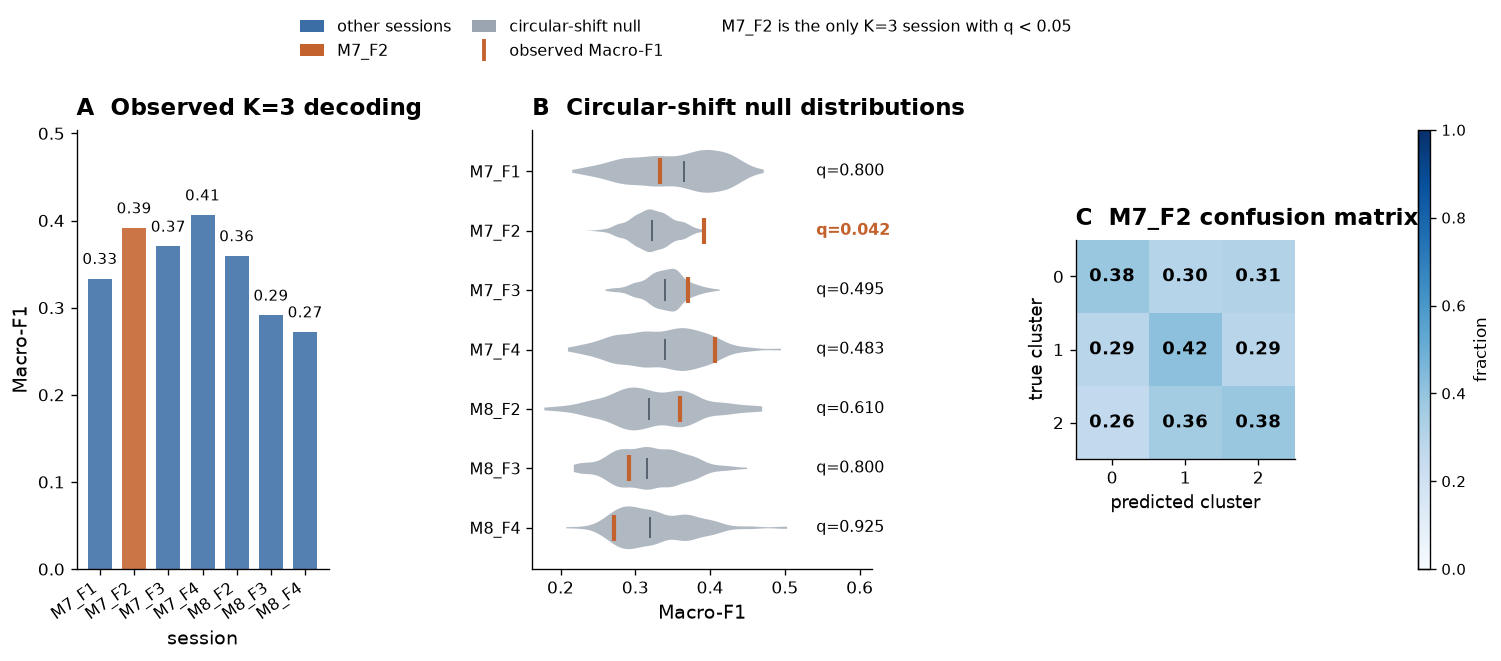

In [194]:
# ================================================================
# MAIN FIGURE 3 — Neural decoding summary
# ================================================================

from matplotlib.lines import Line2D
from matplotlib.patches import Patch

K_FIG = K_PRIMARY
CONFUSION_SESSION = "M7_F2"

dec_fig = (
    decode.loc[
        decode["K"] == K_FIG
    ]
    .set_index("session")
    .reindex(DECODE_SESSIONS)
    .reset_index()
)

sessions_fig = dec_fig["session"].tolist()

obs_scores = dec_fig[
    "macro_f1"
].to_numpy(dtype=float)

q_vals = dec_fig[
    "q_bh"
].to_numpy(dtype=float)

sig = q_vals < 0.05

x = np.arange(
    len(sessions_fig)
)

# ================================================================
# Layout
# ================================================================

fig = plt.figure(
    figsize=(12.4, 5.4),
    constrained_layout=False
)

gs = fig.add_gridspec(
    2, 4,
    height_ratios=[0.13, 1],
    width_ratios=[1.15, 1.55, 1.0, 0.055],
    left=0.065,
    right=0.97,
    bottom=0.16,
    top=0.96,
    wspace=0.33,
    hspace=0.09
)

ax_leg = fig.add_subplot(
    gs[0, :3]
)
ax_leg.axis("off")

ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[1, 2])

cax = fig.add_subplot(
    gs[1, 3]
)


# ================================================================
# A. Observed Macro-F1
# ================================================================

bar_colors = [
    (
        PALETTE["observed"]
        if lab == CONFUSION_SESSION
        else PALETTE["accent"]
    )
    for lab in sessions_fig
]

bars = ax_a.bar(
    x,
    obs_scores,
    width=0.70,
    color=bar_colors,
    alpha=0.88
)

ax_a.set_title(
    "A  Observed K=3 decoding",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=9
)

ax_a.set_ylabel(
    "Macro-F1",
    fontsize=11.5
)

ax_a.set_xlabel(
    "session",
    fontsize=11.5
)

ax_a.set_xticks(x)

ax_a.set_xticklabels(
    sessions_fig,
    rotation=35,
    ha="right",
    fontsize=9.5
)

ax_a.tick_params(
    axis="y",
    labelsize=10
)

ymax = max(
    0.5,
    obs_scores.max() * 1.24
)

ax_a.set_ylim(
    0,
    ymax
)

for bar, score in zip(
    bars,
    obs_scores
):
    ax_a.text(
        bar.get_x() + bar.get_width()/2,
        score + ymax*0.025,
        f"{score:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )


# ================================================================
# B. Session-specific circular-shift nulls
# ================================================================

null_data = [
    np.asarray(
        decode_nulls[(K_FIG, lab)],
        dtype=float
    )
    for lab in sessions_fig
]

positions = np.arange(
    len(sessions_fig)
)

vp = ax_b.violinplot(
    null_data,
    positions=positions,
    vert=False,
    widths=0.72,
    showmeans=False,
    showmedians=True,
    showextrema=False
)

for body in vp["bodies"]:
    body.set_facecolor(
        PALETTE["null"]
    )
    body.set_edgecolor(
        "none"
    )
    body.set_alpha(
        0.78
    )

if "cmedians" in vp:
    vp["cmedians"].set_color(
        PALETTE["null_alt"]
    )
    vp["cmedians"].set_linewidth(
        1.2
    )

# observed value as a short VERTICAL line on each row
ax_b.scatter(
    obs_scores,
    positions,
    marker="|",
    s=230,
    linewidths=2.5,
    color=PALETTE["observed"],
    zorder=4
)

null_min = min(
    a.min()
    for a in null_data
)

null_max = max(
    max(a.max(), obs)
    for a, obs in zip(
        null_data,
        obs_scores
    )
)

span = null_max - null_min

if span <= 0:
    span = 0.1

label_x = null_max + 0.12 * span

ax_b.set_xlim(
    null_min - 0.05 * span,
    null_max + 0.35 * span
)

for yi, lab, q in zip(
    positions,
    sessions_fig,
    q_vals
):

    is_sig = q < 0.05

    ax_b.text(
        label_x,
        yi,
        f"q={q:.3f}",
        ha="left",
        va="center",
        fontsize=9.5,
        fontweight=(
            "bold"
            if is_sig
            else "normal"
        ),
        color=(
            PALETTE["observed"]
            if is_sig
            else "black"
        )
    )

ax_b.set_yticks(
    positions
)

ax_b.set_yticklabels(
    sessions_fig,
    fontsize=9.5
)

ax_b.invert_yaxis()

ax_b.set_xlabel(
    "Macro-F1",
    fontsize=11.5
)

ax_b.set_title(
    "B  Circular-shift null distributions",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=9
)

ax_b.tick_params(
    axis="x",
    labelsize=10
)


# ================================================================
# C. M7_F2 confusion matrix
# ================================================================

yt, yp = decode_preds[
    (K_FIG, CONFUSION_SESSION)
]

labs = sorted(
    np.unique(
        np.concatenate([yt, yp])
    )
)

cm = confusion_matrix(
    yt,
    yp,
    labels=labs,
    normalize="true"
)

im = ax_c.imshow(
    cm,
    cmap="Blues",
    vmin=0,
    vmax=1
)

for r in range(cm.shape[0]):
    for c in range(cm.shape[1]):

        value = cm[r, c]

        ax_c.text(
            c,
            r,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=11,
            fontweight="bold",
            color=(
                "white"
                if value >= 0.55
                else "black"
            )
        )

ax_c.set_xticks(
    range(len(labs)),
    labs
)

ax_c.set_yticks(
    range(len(labs)),
    labs
)

ax_c.set_xlabel(
    "predicted cluster",
    fontsize=11
)

ax_c.set_ylabel(
    "true cluster",
    fontsize=11
)

ax_c.set_title(
    f"C  {CONFUSION_SESSION} confusion matrix",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=9
)

ax_c.tick_params(
    axis="both",
    labelsize=10
)

cbar = fig.colorbar(
    im,
    cax=cax
)

cbar.set_label(
    "fraction",
    fontsize=10
)

cbar.ax.tick_params(
    labelsize=9
)


# ================================================================
# Shared legend only in dedicated header
# ================================================================

legend_handles = [
    Patch(
        facecolor=PALETTE["accent"],
        edgecolor="none",
        label="other sessions"
    ),

    Patch(
        facecolor=PALETTE["observed"],
        edgecolor="none",
        label="M7_F2"
    ),

    Patch(
        facecolor=PALETTE["null"],
        edgecolor="none",
        label="circular-shift null"
    ),

    Line2D(
        [0], [0],
        color=PALETTE["observed"],
        marker="|",
        linestyle="none",
        markersize=13,
        markeredgewidth=2.3,
        label="observed Macro-F1"
    ),

    Line2D(
        [], [],
        linestyle="none",
        label="M7_F2 is the only K=3 session with q < 0.05"
    )
]

ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=3,
    frameon=False,
    fontsize=9.7,
    handlelength=1.5,
    columnspacing=1.3
)

save_fig(
    fig,
    "main_decoding_summary"
)

plt.show()

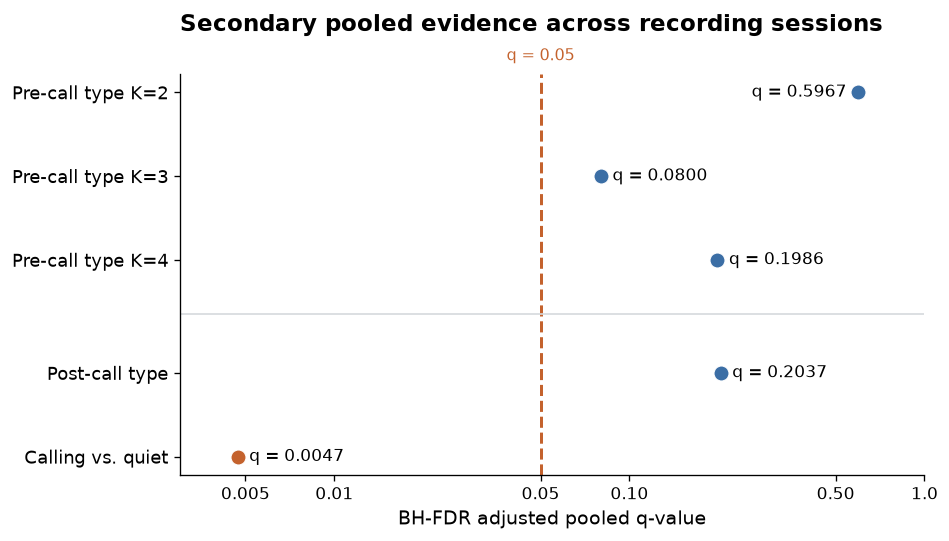

In [230]:
# ================================================================
# MAIN FIGURE 4 — Secondary pooled evidence
#
# Horizontal dot plot of BH-FDR-adjusted Fisher pooled p-values.
# Uses existing `combined` only.
# ================================================================


# ================================================================
# Retrieve the five requested results
# ================================================================

def get_q(
    family,
    target
):

    return float(
        combined.loc[
            (combined["family"] == family)
            &
            (combined["target"] == target),
            "q_fisher"
        ].iloc[0]
    )


plot_df = pd.DataFrame({

    "label": [
        "Pre-call type K=2",
        "Pre-call type K=3",
        "Pre-call type K=4",
        "Post-call type",
        "Calling vs. quiet",
    ],

    "q": [
        get_q(
            "call type",
            "K = 2"
        ),

        get_q(
            "call type",
            "K = 3"
        ),

        get_q(
            "call type",
            "K = 4"
        ),

        get_q(
            "positive control",
            "call type, post-call window"
        ),

        get_q(
            "positive control",
            "calling vs quiet"
        ),
    ]
})


# ================================================================
# Positions
#
# Extra vertical space separates call-type analyses from controls.
# ================================================================

y = np.array([
    4.0,
    3.0,
    2.0,
    0.65,
    -0.35
])


FDR_THRESHOLD = 0.05


# ================================================================
# Figure
# ================================================================

fig, ax = plt.subplots(
    figsize=(7.8, 4.4),
    constrained_layout=False
)


fig.subplots_adjust(
    left=0.28,
    right=0.95,
    bottom=0.20,
    top=0.88
)


# ================================================================
# FDR threshold
# ================================================================

ax.axvline(
    FDR_THRESHOLD,
    color=PALETTE["observed"],
    linestyle="--",
    linewidth=1.8,
    zorder=1
)


# ================================================================
# Points
# ================================================================

for yi, row in zip(
    y,
    plot_df.itertuples()
):

    significant = (
        row.q < FDR_THRESHOLD
    )


    color = (
        PALETTE["observed"]
        if significant
        else PALETTE["accent"]
    )


    ax.scatter(
        row.q,
        yi,
        s=82,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=3
    )


    # Keep large-q annotations inside the figure.
    if row.q > 0.35:

        ax.annotate(
            f"q = {row.q:.4f}",
            xy=(row.q, yi),
            xytext=(-7, 0),
            textcoords="offset points",
            ha="right",
            va="center",
            fontsize=10
        )

    else:

        ax.annotate(
            f"q = {row.q:.4f}",
            xy=(row.q, yi),
            xytext=(7, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=10
        )


# ================================================================
# Visual separation between analysis families
# ================================================================

ax.axhline(
    1.35,
    color="#D5D9DD",
    linewidth=1.0
)


# ================================================================
# Axes
# ================================================================

ax.set_xscale(
    "log"
)


ax.set_xlim(
    0.003,
    1.0
)


ax.set_xticks([
    0.005,
    0.01,
    0.05,
    0.10,
    0.50,
    1.00
])


ax.set_xticklabels([
    "0.005",
    "0.01",
    "0.05",
    "0.10",
    "0.50",
    "1.0"
])


ax.minorticks_off()


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df["label"],
    fontsize=10.5
)


ax.set_xlabel(
    "BH-FDR adjusted pooled q-value",
    fontsize=11.5
)


ax.set_title(
    "Secondary pooled evidence across recording sessions\n",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=9
)


ax.tick_params(
    axis="x",
    labelsize=10
)


# Threshold label in unused top margin, not over data
ax.text(
    FDR_THRESHOLD,
    1.025,
    "q = 0.05",
    transform=ax.get_xaxis_transform(),
    ha="center",
    va="bottom",
    fontsize=9.5,
    color=PALETTE["observed"]
)


# ================================================================
# Sanity check
# ================================================================

sig_labels = (
    plot_df.loc[
        plot_df["q"] < FDR_THRESHOLD,
        "label"
    ]
    .tolist()
)


if sig_labels != ["Calling vs. quiet"]:

    print(
        "WARNING: expected only 'Calling vs. quiet' below q=0.05; "
        f"found {sig_labels}."
    )


# ================================================================
# Save
# ================================================================

save_fig(
    fig,
    "main_control_summary"
)

plt.show()

## 14. Summary and limitations

Every number below is read from the variables computed above, so this section cannot
drift away from what the notebook actually ran.

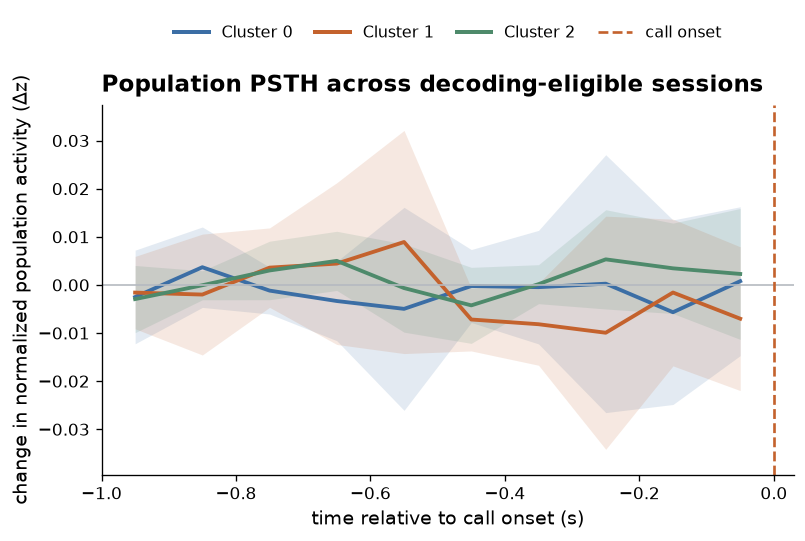

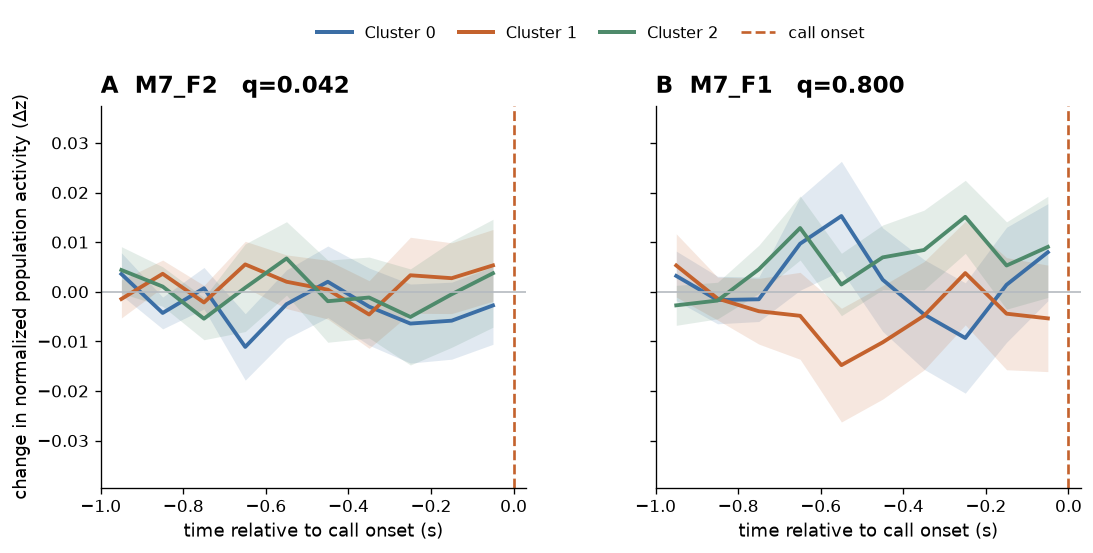

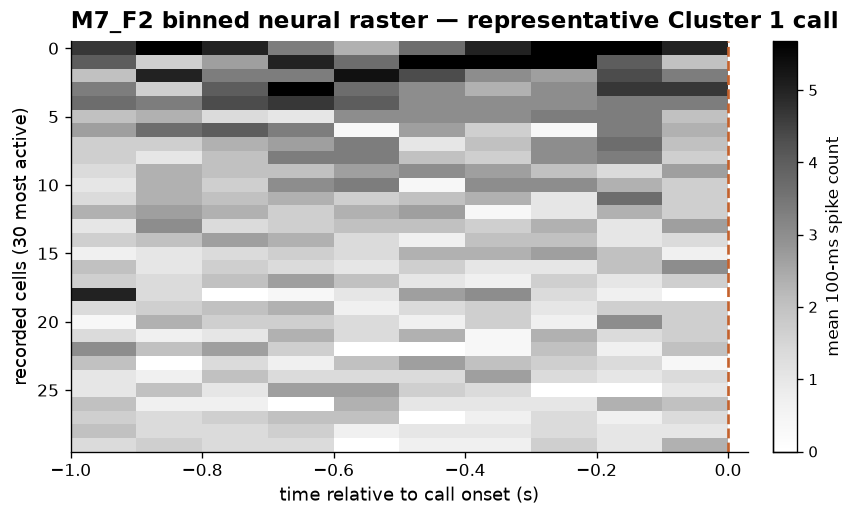

PSTHs are baseline-corrected to each call's -1.0 to -0.7 s pre-call interval.
M7_F2 and M7_F1 use identical normalization and identical y-axis limits: -0.039 to 0.037.
A significant decoder does not require higher mean population activity: decoding can arise from cluster-specific patterns distributed across cells that are partly lost when activity is collapsed to one population mean.


In [207]:
# ================================================================
# Supplementary pre-call neural activity
#
# Outputs:
# 1. Population PSTH across all decoding-eligible sessions
# 2. M7_F2 versus M7_F1 PSTH comparison
# 3. M7_F2 representative binned neural raster
#
# All PSTHs:
# - use the real K=3 cluster labels;
# - use only the 1 s before call onset;
# - normalize each neuron within its session;
# - baseline-correct each call to -1.0 to -0.7 s;
# - use identical y-axis limits across all PSTH panels.
# ================================================================

from matplotlib.lines import Line2D


# ================================================================
# Configuration
# ================================================================

PSTH_LOOKBACK_S = 1.0
PSTH_BIN_S = 0.10

BASELINE_START_S = -1.0
BASELINE_END_S = -0.7

CLUSTERS = [
    0,
    1,
    2
]


# ================================================================
# Time bins
# ================================================================

psth_edges = np.arange(
    -PSTH_LOOKBACK_S,
    0.0 + PSTH_BIN_S * 0.5,
    PSTH_BIN_S
)


psth_centers = (
    psth_edges[:-1]
    +
    psth_edges[1:]
) / 2


N_PSTH_BINS = len(
    psth_centers
)


baseline_mask = (
    (psth_centers >= BASELINE_START_S)
    &
    (psth_centers < BASELINE_END_S)
)


# ================================================================
# Cache session-normalized neural activity
# ================================================================

_z_cache = {}


def session_z_spikes(
    session_label
):

    if session_label in _z_cache:
        return _z_cache[
            session_label
        ]


    s = sessions[
        session_label
    ]


    mu = np.nanmean(
        s.spikes,
        axis=1,
        keepdims=True
    )


    sd = np.nanstd(
        s.spikes,
        axis=1,
        ddof=1,
        keepdims=True
    )


    valid = (
        np.isfinite(
            sd[:, 0]
        )
        &
        (
            sd[:, 0] > 0
        )
    )


    z = (
        s.spikes[
            valid,
            :
        ]
        -
        mu[
            valid,
            :
        ]
    ) / sd[
        valid,
        :
    ]


    _z_cache[
        session_label
    ] = (
        z,
        valid
    )


    return (
        z,
        valid
    )


# ================================================================
# Build one baseline-corrected population trace per call
# ================================================================

def pre_call_population_activity(
    session_label
):

    s = sessions[
        session_label
    ]


    calls_s = (
        ok.loc[
            ok["session"] == session_label,
            [
                "call_time",
                "cluster",
                "bout_id"
            ]
        ]
        .sort_values(
            "call_time"
        )
        .reset_index(
            drop=True
        )
    )


    z_spikes, valid_cells = (
        session_z_spikes(
            session_label
        )
    )


    traces = []
    clusters = []
    bouts = []
    times = []


    for row in calls_s.itertuples():

        t_call = float(
            row.call_time
        )


        if (
            t_call - PSTH_LOOKBACK_S
            <
            s.frame_t.min()
        ):
            continue


        trace = np.full(
            N_PSTH_BINS,
            np.nan
        )


        complete = True


        for b in range(
            N_PSTH_BINS
        ):

            t0 = (
                t_call
                +
                psth_edges[b]
            )

            t1 = (
                t_call
                +
                psth_edges[b + 1]
            )


            m = (
                (s.frame_t >= t0)
                &
                (s.frame_t < t1)
            )


            if not m.any():

                complete = False
                break


            # Mean activity for each neuron in this bin
            cell_bin = np.nanmean(
                z_spikes[
                    :,
                    m
                ],
                axis=1
            )


            # Population average
            trace[b] = np.nanmean(
                cell_bin
            )


        if (
            not complete
            or
            not np.isfinite(
                trace
            ).all()
        ):
            continue


        # --------------------------------------------------------
        # Baseline correction
        #
        # Each call is expressed as change relative to its own
        # early pre-call population activity.
        # --------------------------------------------------------

        baseline = np.mean(
            trace[
                baseline_mask
            ]
        )


        trace = (
            trace
            -
            baseline
        )


        traces.append(
            trace
        )

        clusters.append(
            int(
                row.cluster
            )
        )

        bouts.append(
            row.bout_id
        )

        times.append(
            t_call
        )


    return {
        "activity": np.asarray(
            traces,
            dtype=float
        ),

        "cluster": np.asarray(
            clusters,
            dtype=int
        ),

        "bout": np.asarray(
            bouts
        ),

        "call_time": np.asarray(
            times,
            dtype=float
        )
    }


# ================================================================
# Compute once for all eligible sessions
# ================================================================

session_psth = {
    lab: pre_call_population_activity(
        lab
    )
    for lab in DECODE_SESSIONS
}


# ================================================================
# Bout-level session summary
#
# Calls from one bout are averaged first.
# The displayed SEM is therefore across bouts, not individual calls.
# ================================================================

def bout_level_summary(
    session_label,
    cluster
):

    d = session_psth[
        session_label
    ]


    keep = (
        d["cluster"]
        ==
        cluster
    )


    x = d[
        "activity"
    ][keep]

    bouts = d[
        "bout"
    ][keep]


    if len(x) == 0:

        return (
            np.full(
                N_PSTH_BINS,
                np.nan
            ),

            np.full(
                N_PSTH_BINS,
                np.nan
            ),

            0
        )


    bout_traces = []


    for bout in np.unique(
        bouts
    ):

        bout_traces.append(
            np.mean(
                x[
                    bouts == bout
                ],
                axis=0
            )
        )


    bout_traces = np.asarray(
        bout_traces,
        dtype=float
    )


    mean = np.mean(
        bout_traces,
        axis=0
    )


    if len(
        bout_traces
    ) > 1:

        sem = (
            np.std(
                bout_traces,
                axis=0,
                ddof=1
            )
            /
            np.sqrt(
                len(
                    bout_traces
                )
            )
        )

    else:

        sem = np.zeros(
            N_PSTH_BINS
        )


    return (
        mean,
        sem,
        len(
            bout_traces
        )
    )


# ================================================================
# Across-session summary
#
# Every recording session contributes one cluster mean.
# The band is ±1 SD across session means and is descriptive.
# ================================================================

def across_session_summary(
    cluster
):

    session_means = []


    for lab in DECODE_SESSIONS:

        mean, _, n_bouts = (
            bout_level_summary(
                lab,
                cluster
            )
        )


        if (
            n_bouts > 0
            and
            np.isfinite(
                mean
            ).all()
        ):

            session_means.append(
                mean
            )


    session_means = np.asarray(
        session_means,
        dtype=float
    )


    mean = np.mean(
        session_means,
        axis=0
    )


    if len(
        session_means
    ) > 1:

        spread = np.std(
            session_means,
            axis=0,
            ddof=1
        )

    else:

        spread = np.zeros(
            N_PSTH_BINS
        )


    return (
        mean,
        spread,
        len(
            session_means
        )
    )


# ================================================================
# Compute summaries before plotting
# ================================================================

all_summary = {}

for c in CLUSTERS:

    all_summary[c] = (
        across_session_summary(
            c
        )
    )


session_summary = {
    lab: {
        c: bout_level_summary(
            lab,
            c
        )
        for c in CLUSTERS
    }
    for lab in [
        "M7_F2",
        "M7_F1"
    ]
}


# ================================================================
# ONE COMMON Y-AXIS for every PSTH figure
# ================================================================

lower_bounds = [
    0.0
]

upper_bounds = [
    0.0
]


for c in CLUSTERS:

    mean, spread, _ = (
        all_summary[c]
    )

    lower_bounds.extend(
        mean - spread
    )

    upper_bounds.extend(
        mean + spread
    )


for lab in [
    "M7_F2",
    "M7_F1"
]:

    for c in CLUSTERS:

        mean, sem, _ = (
            session_summary[
                lab
            ][c]
        )

        lower_bounds.extend(
            mean - sem
        )

        upper_bounds.extend(
            mean + sem
        )


ymin = float(
    np.nanmin(
        lower_bounds
    )
)

ymax = float(
    np.nanmax(
        upper_bounds
    )
)


yrange = (
    ymax - ymin
)

if yrange <= 0:
    yrange = 0.1


PSTH_YLIM = (
    ymin - 0.08 * yrange,
    ymax + 0.08 * yrange
)


# ================================================================
# Common handles
# ================================================================

cluster_handles = [
    Line2D(
        [0],
        [0],
        color=cluster_color(c),
        linewidth=2.4,
        label=f"Cluster {c}"
    )
    for c in CLUSTERS
]


cluster_handles.append(
    Line2D(
        [0],
        [0],
        color=PALETTE["observed"],
        linestyle="--",
        linewidth=1.6,
        label="call onset"
    )
)


# ================================================================
# FIGURE 1
# Population PSTH across all eligible sessions
# ================================================================

fig = plt.figure(
    figsize=(6.6, 4.4),
    constrained_layout=False
)


gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[
        0.12,
        1.0
    ],
    left=0.13,
    right=0.97,
    bottom=0.17,
    top=0.95,
    hspace=0.07
)


ax_leg = fig.add_subplot(
    gs[0, 0]
)

ax = fig.add_subplot(
    gs[1, 0]
)


ax_leg.axis(
    "off"
)


for c in CLUSTERS:

    mean, spread, n_sessions = (
        all_summary[c]
    )


    ax.plot(
        psth_centers,
        mean,
        color=cluster_color(c),
        linewidth=2.3
    )


    ax.fill_between(
        psth_centers,
        mean - spread,
        mean + spread,
        color=cluster_color(c),
        alpha=0.14,
        linewidth=0
    )


ax.axhline(
    0,
    color="#B5BAC0",
    linewidth=1.0
)


ax.axvline(
    0,
    color=PALETTE["observed"],
    linestyle="--",
    linewidth=1.6
)


ax.set_title(
    "Population PSTH across decoding-eligible sessions",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)


ax.set_xlabel(
    "time relative to call onset (s)",
    fontsize=11.5
)


ax.set_ylabel(
    "change in normalized population activity (Δz)",
    fontsize=11.5
)


ax.set_xlim(
    -PSTH_LOOKBACK_S,
    0.03
)


ax.set_ylim(
    PSTH_YLIM
)


ax.tick_params(
    axis="both",
    labelsize=10
)


ax_leg.legend(
    handles=cluster_handles,
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=9.8,
    handlelength=2.1,
    columnspacing=1.4
)


save_fig(
    fig,
    "supp_neural_psth_all_sessions"
)

plt.show()


# ================================================================
# FIGURE 2
# M7_F2 versus M7_F1
#
# SAME normalization, SAME x-axis, SAME y-axis.
# ================================================================

q_lookup = (
    decode.loc[
        decode["K"] == K_PRIMARY
    ]
    .set_index(
        "session"
    )[
        "q_bh"
    ]
)


fig = plt.figure(
    figsize=(9.0, 4.5),
    constrained_layout=False
)


gs = fig.add_gridspec(
    nrows=2,
    ncols=2,
    height_ratios=[
        0.12,
        1.0
    ],
    left=0.085,
    right=0.98,
    bottom=0.17,
    top=0.95,
    wspace=0.20,
    hspace=0.07
)


ax_leg = fig.add_subplot(
    gs[0, :]
)

ax_f2 = fig.add_subplot(
    gs[1, 0]
)

ax_f1 = fig.add_subplot(
    gs[1, 1],
    sharex=ax_f2,
    sharey=ax_f2
)


ax_leg.axis(
    "off"
)


for ax, lab, letter in [
    (
        ax_f2,
        "M7_F2",
        "A"
    ),
    (
        ax_f1,
        "M7_F1",
        "B"
    )
]:

    for c in CLUSTERS:

        mean, sem, n_bouts = (
            session_summary[
                lab
            ][c]
        )


        ax.plot(
            psth_centers,
            mean,
            color=cluster_color(c),
            linewidth=2.3
        )


        ax.fill_between(
            psth_centers,
            mean - sem,
            mean + sem,
            color=cluster_color(c),
            alpha=0.15,
            linewidth=0
        )


    ax.axhline(
        0,
        color="#B5BAC0",
        linewidth=1.0
    )


    ax.axvline(
        0,
        color=PALETTE["observed"],
        linestyle="--",
        linewidth=1.6
    )


    q = float(
        q_lookup.loc[
            lab
        ]
    )


    ax.set_title(
        f"{letter}  {lab}   q={q:.3f}",
        loc="left",
        fontsize=13.5,
        fontweight="bold",
        pad=8
    )


    ax.set_xlabel(
        "time relative to call onset (s)",
        fontsize=11
    )


    ax.set_xlim(
        -PSTH_LOOKBACK_S,
        0.03
    )


    ax.set_ylim(
        PSTH_YLIM
    )


    ax.tick_params(
        axis="both",
        labelsize=10
    )


ax_f2.set_ylabel(
    "change in normalized population activity (Δz)",
    fontsize=11
)


ax_f1.tick_params(
    labelleft=False
)


ax_leg.legend(
    handles=cluster_handles,
    loc="center",
    ncol=4,
    frameon=False,
    fontsize=9.8,
    handlelength=2.1,
    columnspacing=1.4
)


save_fig(
    fig,
    "supp_neural_psth_m7f2_vs_m7f1"
)

plt.show()


# ================================================================
# FIGURE 3
# M7_F2 representative binned neural raster
#
# Exact spike timestamps are not available.
# spikeCounts100ms is therefore shown honestly as a binned raster.
# ================================================================

RASTER_SESSION = "M7_F2"
N_RASTER_CELLS = 30


d = session_psth[
    RASTER_SESSION
]


# Representative call = trace closest to the session mean trace.
session_mean_trace = np.mean(
    d["activity"],
    axis=0
)


distance = np.sum(
    (
        d["activity"]
        -
        session_mean_trace
    ) ** 2,
    axis=1
)


rep_idx = int(
    np.argmin(
        distance
    )
)


rep_time = float(
    d["call_time"][
        rep_idx
    ]
)


rep_cluster = int(
    d["cluster"][
        rep_idx
    ]
)


s = sessions[
    RASTER_SESSION
]


# One cell x time-bin matrix using the stored 100-ms spike counts.
raster_counts = np.full(
    (
        s.spikes.shape[0],
        N_PSTH_BINS
    ),
    np.nan
)


for b in range(
    N_PSTH_BINS
):

    t0 = (
        rep_time
        +
        psth_edges[b]
    )

    t1 = (
        rep_time
        +
        psth_edges[b + 1]
    )


    m = (
        (s.frame_t >= t0)
        &
        (s.frame_t < t1)
    )


    raster_counts[
        :,
        b
    ] = np.nanmean(
        s.spikes[
            :,
            m
        ],
        axis=1
    )


# Keep the most active cells for readability.
rank = np.argsort(
    np.nanmean(
        raster_counts,
        axis=1
    )
)[::-1]


rank = rank[
    :min(
        N_RASTER_CELLS,
        len(rank)
    )
]


raster_display = (
    raster_counts[
        rank,
        :
    ]
)


vmax = float(
    np.nanpercentile(
        raster_display,
        98
    )
)


if vmax <= 0:
    vmax = 1.0


# ================================================================
# Raster layout
# ================================================================

fig = plt.figure(
    figsize=(7.0, 4.2),
    constrained_layout=False
)


gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[
        1.0,
        0.035
    ],
    left=0.12,
    right=0.92,
    bottom=0.18,
    top=0.88,
    wspace=0.06
)


ax = fig.add_subplot(
    gs[0, 0]
)

cax = fig.add_subplot(
    gs[0, 1]
)


im = ax.imshow(
    raster_display,
    aspect="auto",
    interpolation="nearest",
    origin="upper",
    extent=[
        psth_edges[0],
        psth_edges[-1],
        len(rank) - 0.5,
        -0.5
    ],
    cmap="Greys",
    vmin=0,
    vmax=vmax
)


ax.axvline(
    0,
    color=PALETTE["observed"],
    linestyle="--",
    linewidth=1.6
)


ax.set_title(
    f"M7_F2 binned neural raster — representative Cluster {rep_cluster} call",
    loc="left",
    fontsize=13.5,
    fontweight="bold",
    pad=8
)


ax.set_xlabel(
    "time relative to call onset (s)",
    fontsize=11
)


ax.set_ylabel(
    "recorded cells (30 most active)",
    fontsize=11
)


ax.set_xlim(
    -PSTH_LOOKBACK_S,
    0.03
)


ax.tick_params(
    axis="both",
    labelsize=10
)


cbar = fig.colorbar(
    im,
    cax=cax
)


cbar.set_label(
    "mean 100-ms spike count",
    fontsize=10
)


cbar.ax.tick_params(
    labelsize=9
)


save_fig(
    fig,
    "supp_m7f2_binned_neural_raster"
)

plt.show()


# ================================================================
# Notebook summaries
# ================================================================

print(
    "PSTHs are baseline-corrected to each call's -1.0 to -0.7 s "
    "pre-call interval."
)


print(
    "M7_F2 and M7_F1 use identical normalization and identical "
    f"y-axis limits: {PSTH_YLIM[0]:.3f} to {PSTH_YLIM[1]:.3f}."
)


print(
    "A significant decoder does not require higher mean population activity: "
    "decoding can arise from cluster-specific patterns distributed across cells "
    "that are partly lost when activity is collapsed to one population mean."
)

In [196]:
lines = []
lines.append("DATA")
lines.append(f"  {len(sessions)} female-encounter sessions, {inventory['mouse'].nunique()} mice, "
             f"{int(inventory['n_calls'].sum())} detected calls.")
lines.append(f"  {len(ok)} calls ({len(ok)/len(features):.0%}) passed acoustic quality control "
             f"and define the call-type categories.")
lines.append(f"  Audio-to-neural alignment verified on {len(sync_check)} sessions; the "
             f"documented convention gave the highest call-to-control energy ratio in "
             f"{int(sync_wins.sum())}/{len(sync_wins)}.")

lines.append("\nCALL TYPES")
lines.append(f"  Features: {', '.join(CLUSTER_FEATURES)}, chosen on feature collinearity "
             f"(|r| >= {COLLINEARITY_R:.2f}) before K was selected.")
lines.append(f"  Agreement with the alternative feature set ranges "
             f"{set_agreement['ari_full_vs_core'].min():.2f}-"
             f"{set_agreement['ari_full_vs_core'].max():.2f} across the K sweep; that "
             f"alternative would have selected K = {K_ALT}.")
lines.append(f"  K = {K_PRIMARY} by silhouette; Davies-Bouldin picked {K_DB}, "
             f"Calinski-Harabasz picked {K_CH}"
             + (" -- all three agree." if len(set([K_SIL, K_DB, K_CH])) == 1
                else " -- the indices do not all agree, so K is the primary criterion's choice."))
lines.append(f"  K-Means used downstream; agreement with a full-covariance GMM "
             f"ARI = {ARI_KM_GMM:.2f}.")
lines.append(f"  Bootstrap stability ARI {_this:.2f}; cluster balance {balance:.2f}.")
lines.append(f"  Silhouette vs. shuffled-feature null p = {sil_p:.4f}; vs. single-Gaussian "
             f"null p = {uni_p:.4f}.")
lines.append(f"  Quality-cut sensitivity: ARI "
             f"{snr_tiers['ari_vs_analysis'].min():.2f}-"
             f"{snr_tiers['ari_vs_analysis'].max():.2f} across three SNR tiers.")
lines.append(f"  Within-bout call-type agreement {within_bout_agreement:.0%}.")

lines.append("\nDECODING")
lines.append(f"  {len(DECODE_SESSIONS)} sessions met the {MIN_EVENTS_FOR_DECODING}-usable-call "
             f"threshold: {', '.join(DECODE_SESSIONS)}.")
lines.append("  Model competition (nested CV): " +
             ", ".join(f"{m} {v:.3f}" for m, v in model_means.items())
             + f" mean macro-F1; {BEST_MODEL} carried forward, winning "
             f"{int(wins.get(BEST_MODEL, 0))}/{len(DECODE_SESSIONS)} sessions.")
lines.append("  Hyperparameters selected by the inner CV: " +
             ", ".join(f"{k}={v}" for k, v in BEST_PARAMS.items()) + ".")
lines.append(f"  Bout threshold derived from the bout-count knee: {BOUT_GAP_S:g} s "
             "(the interval distribution has no valley to cut at).")
lines.append(f"  Call type, K in {list(DECODING_K_SWEEP)}: {n_sig_decode}/{len(decode)} tests "
             f"significant after BH-FDR.")
lines.append(f"  Look-back sweep {[lb for lb, _ in LOOK_BACK_SWEEP]} s: "
             f"{int(windows['significant'].sum())}/{len(windows)} significant after BH-FDR.")
for _name, _r in by_control.iterrows():
    lines.append(f"  Positive control -- {_name}: {int(_r['sum'])}/{int(_r['size'])} "
                 f"sessions significant after BH-FDR.")
lines.append("\nCOMBINED ACROSS SESSIONS (secondary)")
for _r in combined.itertuples():
    lines.append(f"  {_r.family}, {_r.target}: Fisher {fmt_p(_r.p_fisher)}, "
                 f"Stouffer {fmt_p(_r.p_stouffer)}, q {fmt_p(_r.q_fisher)}"
                 + ("  <- significant" if _r.significant else ""))

lines.append("\nWHAT THIS SUPPORTS")
if n_sig_decode == 0 and (CONTROL_PASSED or CONTROL_PASSED_COMBINED):
    lines.append("  The positive control passes" + ("" if CONTROL_PASSED else
                 " once evidence is combined across sessions") + ", which is consistent")
    lines.append("  with the pipeline being able to detect a vocalisation-related neural")
    lines.append("  signal, but no session, K or")
    lines.append("  window length yields call-type information in the pre-call window that")
    lines.append("  survives correction. This is a negative result about call type")
    lines.append("  specifically, not about the analysis being unable to see anything.")
    lines.append("  Single sessions of a few hundred events are underpowered, which is why")
    lines.append("  the combined test is reported alongside them.")
elif n_sig_decode == 0:
    lines.append("  Nothing is decodable here: not call type before the call, not call type")
    lines.append("  during vocal production, not even whether the animal called at all. Both")
    lines.append("  positive controls fail, so the negative call-type result cannot be")
    lines.append("  separated from a sensitivity limit of this neural feature construction,")
    lines.append("  and must not be reported as evidence that mPFC lacks call-type")
    lines.append("  information. The open question is the design matrix, not the biology.")
else:
    _hits = decode[decode["significant"]]
    lines.append(f"  {n_sig_decode} of {len(decode)} per-session tests survive correction: "
                 + "; ".join(f"K={int(r.K)} {r.session} (macro-F1 {r.macro_f1:.3f}, "
                             f"q={r.q_bh:.3f})" for r in _hits.itertuples()) + ".")
    if CONTROL_PASSED_COMBINED or CONTROL_PASSED:
        lines.append("  The positive control passes"
                     + ("" if CONTROL_PASSED else " on the combined evidence") +
                     ", which is consistent with the")
        lines.append("  pipeline being able to detect a vocalisation-related signal; these hits")
        lines.append("  are read against a pipeline that has passed a positive control rather")
        lines.append("  than one of unknown sensitivity.")
    else:
        lines.append("  Neither positive control passes, so these hits sit in a pipeline whose")
        lines.append("  sensitivity is unverified and should be treated with corresponding caution.")
    lines.append("  Every such claim is within-session and within-animal. It does not")
    lines.append("  generalise across mice on this evidence, and a single surviving session")
    lines.append("  out of several is a lead to test on new data, not a finding on its own.")

lines.append("\nLIMITATIONS")
lines.append("  1. There is no ground-truth call-type label for mice. Cluster validity here")
lines.append("     is internal consistency only, so the decoding target is a construct.")
lines.append(f"  2. The pooled clustering set is {pool.iloc[0]:.0f}% {pool.index[0]}; the other")
lines.append("     mice widen the acoustic range but cannot support per-mouse claims.")
lines.append("  3. spikeCounts100ms is itself a smoothed, overlapping count per frame, so")
lines.append("     averaging frames within a sub-bin is smoothing on top of smoothing.")
lines.append("  4. It is not known which of the two animals produced any given call.")
lines.append("  5. Claims are within-session; nothing here is tested across animals.")
lines.append("  6. Combined p-values say the pooled evidence is or is not above chance.")
lines.append("     They cannot say which session carries it.")
lines.append("\nAPPENDIX")
lines.append("  A1 embeddings (PCA / t-SNE / UMAP, 2-D and 3-D), A2 acoustic-feature ablation,")
lines.append("  A3 ablation by recorded region, A4 sessions with a very small class,")
lines.append("  A5 sensitivity to the bout threshold, A6 acoustic QC of excluded calls,")
lines.append("  A7 grouped vs. random CV (leakage demonstration).")

summary = "\n".join(lines)
print(summary)
(OUT_DIR / "summary.txt").write_text(summary, encoding="utf-8")

DATA
  16 female-encounter sessions, 5 mice, 3984 detected calls.
  2692 calls (68%) passed acoustic quality control and define the call-type categories.
  Audio-to-neural alignment verified on 8 sessions; the documented convention gave the highest call-to-control energy ratio in 8/8.

CALL TYPES
  Features: duration_ms, fm_intercept_khz, fm_slope_khz_per_s, chosen on feature collinearity (|r| >= 0.80) before K was selected.
  Agreement with the alternative feature set ranges 0.39-0.91 across the K sweep; that alternative would have selected K = 2.
  K = 3 by silhouette; Davies-Bouldin picked 7, Calinski-Harabasz picked 3 -- the indices do not all agree, so K is the primary criterion's choice.
  K-Means used downstream; agreement with a full-covariance GMM ARI = 0.69.
  Bootstrap stability ARI 0.98; cluster balance 0.99.
  Silhouette vs. shuffled-feature null p = 0.0050; vs. single-Gaussian null p = 0.0050.
  Quality-cut sensitivity: ARI 0.86-1.00 across three SNR tiers.
  Within-bout 

3742

## 15. Appendix

Checks that support the analysis without belonging in its main line. Each one
answers a question a reader is entitled to ask, and none of them changes a
conclusion above.

- **A1** — are the clusters an artefact of a linear projection? (PCA / t-SNE / UMAP, 2-D and 3-D)
- **A2** — which acoustic feature carries the partition?
- **A3** — does the neural result depend on which region was recorded?
- **A4** — what happens if sessions with a very small class are excluded?
- **A5** — does the bout threshold matter to the decoding?
- **A6** — do the excluded low-quality calls differ acoustically from the retained ones? (quality control)
- **A7** — how much apparent decoding does bout-level leakage create? (grouped vs. random CV, leakage demo)


### A1. The clusters seen through three embeddings, in 2-D and 3-D

Clustering is done in the raw standardised feature space (§8), so these
embeddings decide nothing — they only show whether the grouping survives being
drawn a different way. A reader can reasonably ask whether the structure is an
artefact of projecting linearly onto two principal components; two non-linear
neighbour embeddings, each in two and three dimensions, answer that.

Every panel colours points by the **same K-Means cluster index as §9** (only the
K-Means partition is visualised here; the GMM comparison in §8 is numerical). The
**3-D panels are exploratory visual aids only** and are labelled as such. They are
here for visual inspection, not as evidence: the evidence for the partition is the
clustering metrics, bootstrap stability and permutation tests in §8 and the
decoding validation in §11-§13, and none of it depends on how the cloud looks in
a projection.

There is no shared "explained variance" to rank the methods by — that quantity is
defined for PCA, which decomposes variance, and not for t-SNE or UMAP, which
optimise neighbourhood preservation. The comparable measure is **trustworthiness**
(the fraction of each point's nearest neighbours in the original space that stay
its neighbours in the embedding), reported for every panel.


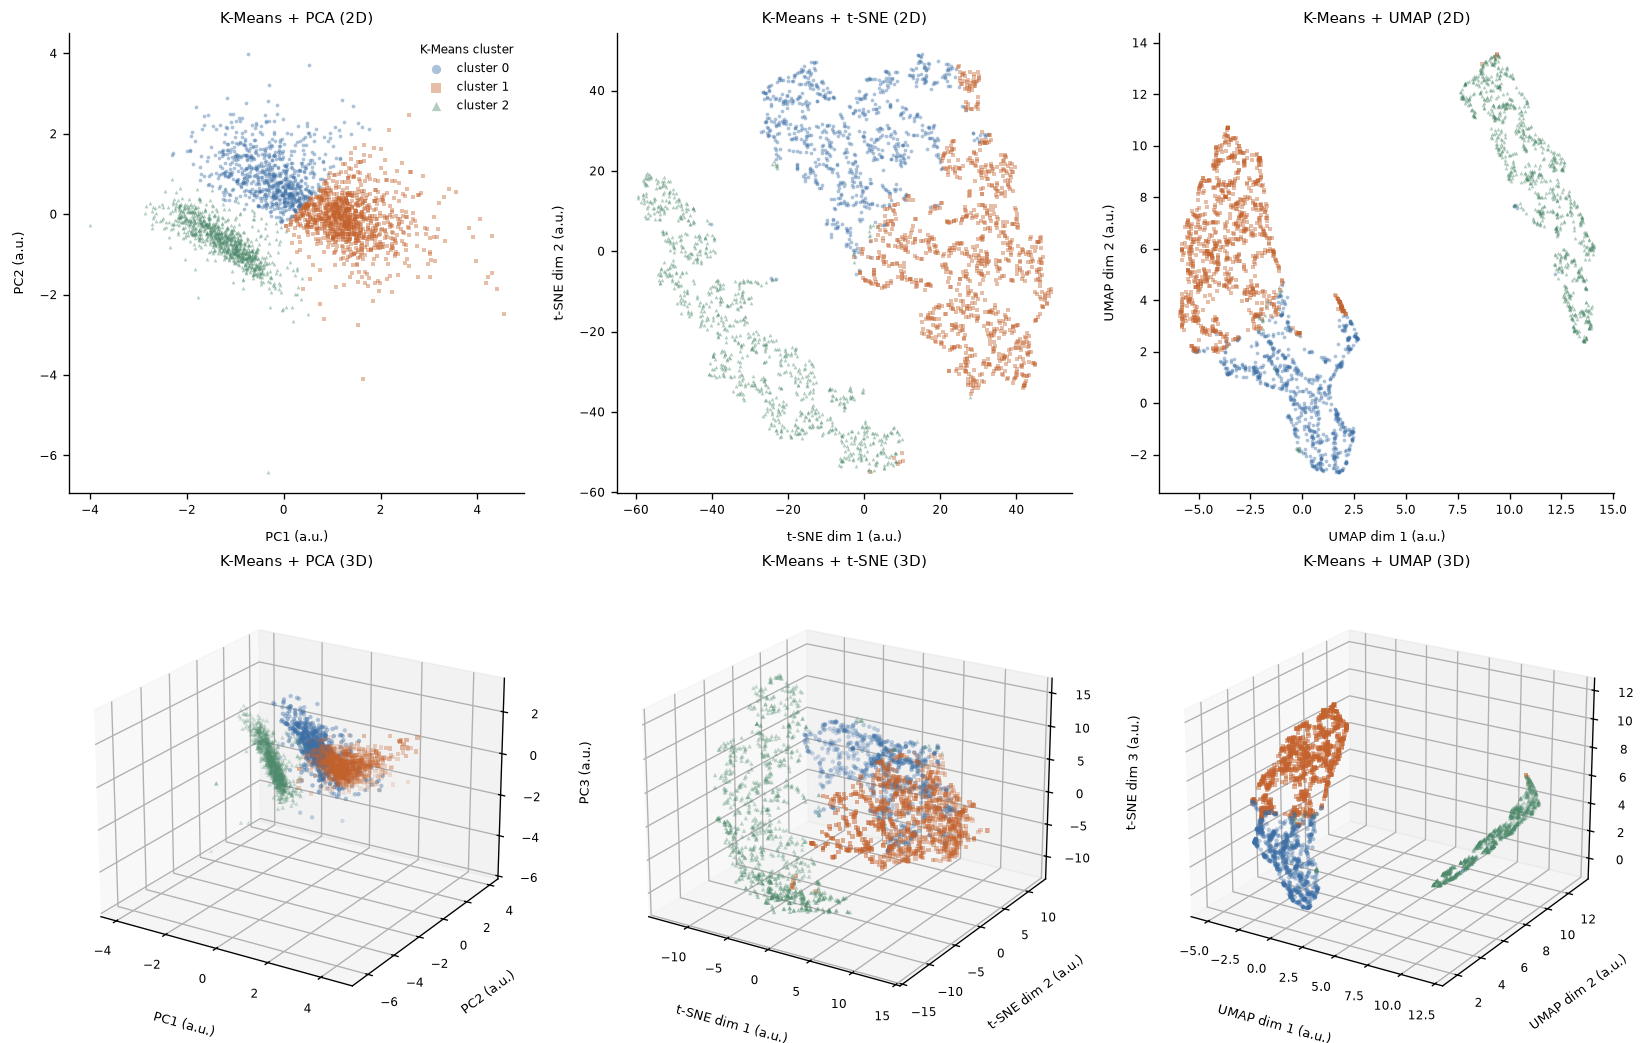

,embedding,n_dims,trustworthiness,explained_variance
0,PCA,2,0.959,0.819
1,PCA,3,1.000,1.000
2,t-SNE,2,0.996,NaN
3,t-SNE,3,0.998,NaN
4,UMAP,2,0.991,NaN
5,UMAP,3,0.995,NaN


Trustworthiness at k = 15 (fraction of each point's neighbours preserved by the embedding):
  PCA: 2-D 0.959, 3-D 1.000
  t-SNE: 2-D 0.996, 3-D 0.998
  UMAP: 2-D 0.991, 3-D 0.995
The projections are descriptive visualisations only. The K-Means partition itself is defined in the original standardised feature space.


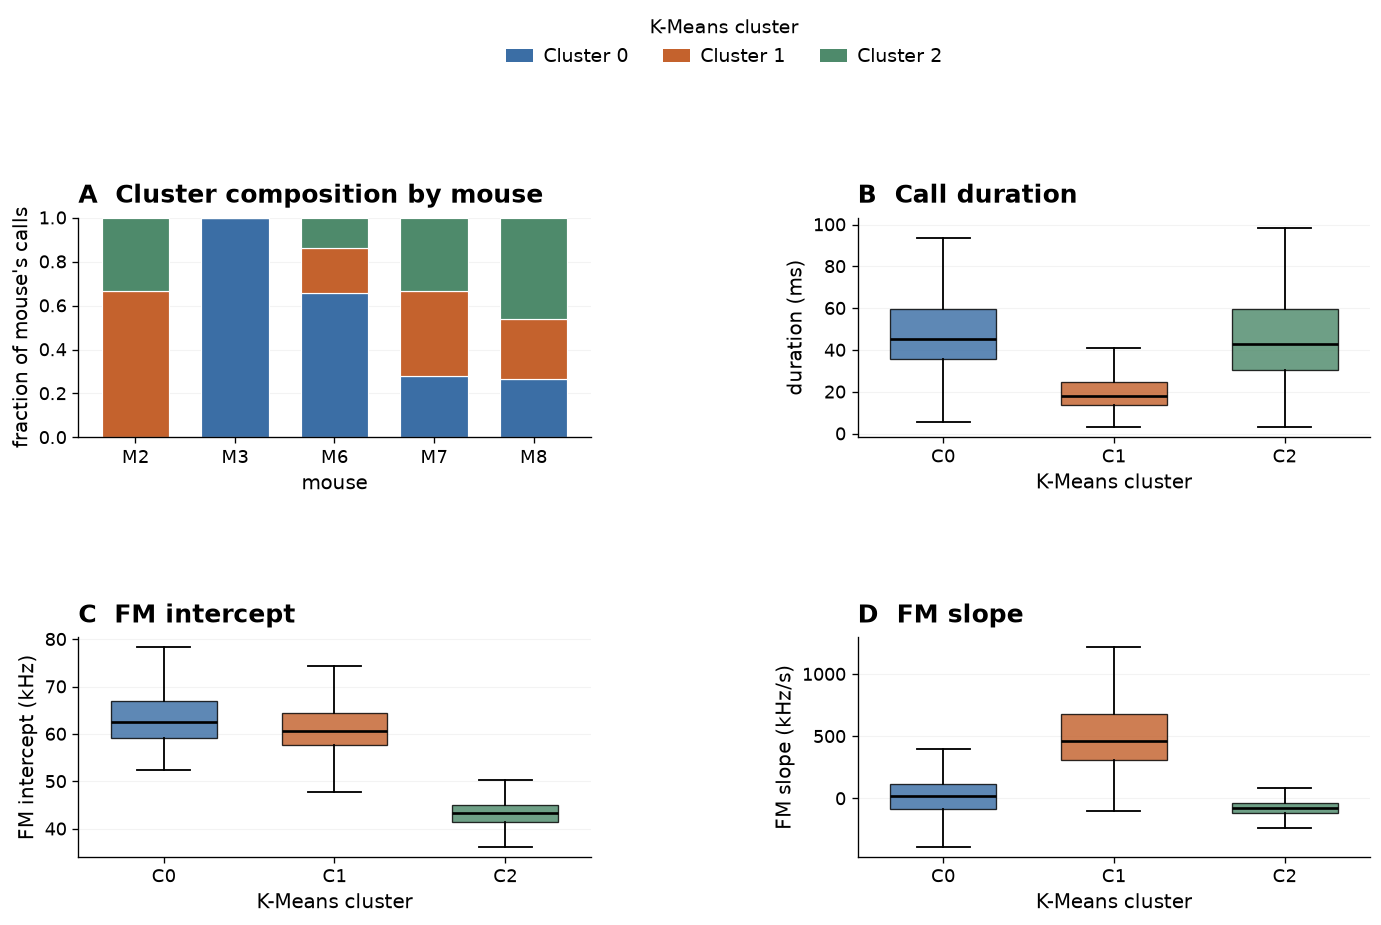

In [215]:
from sklearn.manifold import TSNE, trustworthiness
from mpl_toolkits import mplot3d  # noqa: F401
from matplotlib.patches import Patch

# A1 is intended to contain all six projections.
# Do not silently omit UMAP.
try:
    import umap
except ImportError as exc:
    raise ImportError(
        "Appendix A1 requires umap-learn so that both UMAP panels are shown. "
        "Install it with: pip install umap-learn"
    ) from exc


def build_embeddings_2d3d():
    """PCA, t-SNE and UMAP in 2 and 3 dimensions.

    K-Means itself is fitted in the original standardised feature space.
    These embeddings are visualisations only.
    """
    out = {
        ("PCA", 2): PCA(
            n_components=2,
            random_state=RANDOM_SEED
        ).fit_transform(X),

        ("PCA", 3): PCA(
            n_components=3,
            random_state=RANDOM_SEED
        ).fit_transform(X),
    }

    for d in (2, 3):
        out[("t-SNE", d)] = TSNE(
            n_components=d,
            perplexity=30,
            init="pca",
            random_state=RANDOM_SEED
        ).fit_transform(X)

        out[("UMAP", d)] = umap.UMAP(
            n_components=d,
            n_neighbors=EMBEDDING_NEIGHBORS,
            min_dist=0.1,
            random_state=RANDOM_SEED
        ).fit_transform(X)

    return out


# New cache key prevents reuse of an older cached result that may lack UMAP.
emb = cached("embeddings_2d3d_A1_v2", build_embeddings_2d3d)

methods = ("PCA", "t-SNE", "UMAP")
clabels = sorted(int(c) for c in ok["cluster"].unique())

for name in methods:
    for d in (2, 3):
        if (name, d) not in emb:
            raise RuntimeError(
                f"Missing required A1 embedding: {name} {d}-D"
            )

pca3 = PCA(
    n_components=3,
    random_state=RANDOM_SEED
).fit(X)


# ================================================================
# A1a. K-Means clusters across PCA, t-SNE and UMAP
#
# top row:    PCA 2D | t-SNE 2D | UMAP 2D
# bottom row: PCA 3D | t-SNE 3D | UMAP 3D
# ================================================================

fig = plt.figure(figsize=(13.6, 8.6))

tw_rows = []

for col, name in enumerate(methods):

    for row, d in enumerate((2, 3)):

        XY_e = emb[(name, d)]

        ax = fig.add_subplot(
            2,
            3,
            row * 3 + col + 1,
            projection="3d" if d == 3 else None
        )

        for c in clabels:
            m = labels == c

            if d == 2:
                ax.scatter(
                    XY_e[m, 0],
                    XY_e[m, 1],
                    s=5,
                    alpha=0.42,
                    linewidths=0,
                    color=cluster_color(c),
                    marker=MARKERS[c % len(MARKERS)],
                    label=f"cluster {c}"
                )

            else:
                ax.scatter(
                    XY_e[m, 0],
                    XY_e[m, 1],
                    XY_e[m, 2],
                    s=7,
                    alpha=0.72,
                    linewidths=0,
                    color=cluster_color(c),
                    marker=MARKERS[c % len(MARKERS)],
                    label=f"cluster {c}",
                    depthshade=True
                )

        if name == "PCA":
            ax.set_xlabel(
                "PC1 (a.u.)",
                labelpad=12 if d == 3 else 8
            )
            ax.set_ylabel(
                "PC2 (a.u.)",
                labelpad=12 if d == 3 else 8
            )

            if d == 3:
                ax.set_zlabel(
                    "PC3 (a.u.)",
                    labelpad=10
                )

        else:
            ax.set_xlabel(
                f"{name} dim 1 (a.u.)",
                labelpad=12 if d == 3 else 8
            )
            ax.set_ylabel(
                f"{name} dim 2 (a.u.)",
                labelpad=12 if d == 3 else 8
            )

            if d == 3:
                ax.set_zlabel(
                    f"{name} dim 3 (a.u.)",
                    labelpad=10
                )

        if d == 2:
            ax.set_title(
                f"K-Means + {name} (2D)",
                fontsize=9
            )

        else:
            ax.set_title(
                f"K-Means + {name} (3D)",
                fontsize=9
            )

            ax.zaxis.label.set_color("black")

            ax.tick_params(
                axis="z",
                which="both",
                colors="black",
                labelcolor="black"
            )

            ax.view_init(
                elev=22,
                azim=-58
            )

        if row == 0 and col == 0:
            ax.legend(
                markerscale=2.5,
                loc="best",
                title="K-Means cluster",
                fontsize=7,
                title_fontsize=7
            )

        tw_rows.append(
            dict(
                embedding=name,
                n_dims=d,
                trustworthiness=trustworthiness(
                    X,
                    XY_e,
                    n_neighbors=TRUSTWORTHINESS_K
                ),
                explained_variance=(
                    pca3.explained_variance_ratio_[:d].sum()
                    if name == "PCA"
                    else np.nan
                )
            )
        )


# Extra bottom margin so angled 3-D labels are not clipped.
fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.18,
    top=0.94,
    wspace=0.24,
    hspace=0.22
)

save_fig(
    fig,
    "A1a_kmeans_embeddings_2d_3d"
)

plt.show()


# ================================================================
# Embedding diagnostics
# ================================================================

tw = pd.DataFrame(tw_rows)
show(tw)

print(
    f"Trustworthiness at k = {TRUSTWORTHINESS_K} "
    "(fraction of each point's neighbours preserved by the embedding):"
)

for name in methods:

    v2 = tw[
        (tw["embedding"] == name) &
        (tw["n_dims"] == 2)
    ]["trustworthiness"].iloc[0]

    v3 = tw[
        (tw["embedding"] == name) &
        (tw["n_dims"] == 3)
    ]["trustworthiness"].iloc[0]

    print(
        f"  {name}: "
        f"2-D {v2:.3f}, "
        f"3-D {v3:.3f}"
    )

print(
    "The projections are descriptive visualisations only. "
    "The K-Means partition itself is defined in the original "
    "standardised feature space."
)


# ================================================================
# A1b. Cluster composition and acoustic distributions
#
# Figure S14
#
# A: cluster composition within each mouse
# B: duration by cluster
# C: FM intercept by cluster
# D: FM slope by cluster
#
# No analysis is changed here.
# ================================================================

from matplotlib.patches import Patch


# ================================================================
# Data
# ================================================================

# Normalise within each mouse.
# Each mouse therefore sums to 1.
comp_mouse_a1 = pd.crosstab(
    ok["mouse"],
    ok["cluster"],
    normalize="index"
)

cluster_order = sorted(
    int(c) for c in ok["cluster"].dropna().unique()
)

mouse_order = list(
    comp_mouse_a1.index
)


# ================================================================
# Figure layout
#
# Top row is reserved entirely for the legend.
# It cannot cover any plotting area.
# ================================================================

fig = plt.figure(
    figsize=(11.4, 7.6),
    constrained_layout=False
)

gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[0.10, 1.0, 1.0],
    left=0.085,
    right=0.975,
    bottom=0.10,
    top=0.96,
    wspace=0.27,
    hspace=0.36
)

# Dedicated legend strip
ax_legend = fig.add_subplot(
    gs[0, :]
)
ax_legend.axis("off")

# Four real plotting axes
ax_a = fig.add_subplot(gs[1, 0])
ax_b = fig.add_subplot(gs[1, 1])
ax_c = fig.add_subplot(gs[2, 0])
ax_d = fig.add_subplot(gs[2, 1])


# ================================================================
# Shared cluster legend
# ================================================================

cluster_handles = [
    Patch(
        facecolor=cluster_color(c),
        edgecolor="none",
        label=f"Cluster {c}"
    )
    for c in cluster_order
]

ax_legend.legend(
    handles=cluster_handles,
    title="K-Means cluster",
    loc="center",
    ncol=len(cluster_order),
    frameon=False,
    fontsize=11.5,
    title_fontsize=11.5,
    handlelength=1.4,
    handletextpad=0.55,
    columnspacing=1.8,
    borderaxespad=0
)


# ================================================================
# A. Cluster composition by mouse
#
# Each bar sums to 1 because normalization is within mouse.
# ================================================================

bottom = np.zeros(
    len(mouse_order)
)

for c in cluster_order:

    if c in comp_mouse_a1.columns:
        values = comp_mouse_a1[c].to_numpy()
    else:
        values = np.zeros(len(mouse_order))

    ax_a.bar(
        np.arange(len(mouse_order)),
        values,
        bottom=bottom,
        width=0.68,
        color=cluster_color(c),
        edgecolor="white",
        linewidth=0.7
    )

    bottom += values


ax_a.set_title(
    "A  Cluster composition by mouse",
    loc="left",
    fontsize=15,
    fontweight="bold",
    pad=9
)

ax_a.set_xlabel(
    "mouse",
    fontsize=12
)

ax_a.set_ylabel(
    "fraction of mouse's calls",
    fontsize=12
)

ax_a.set_xticks(
    np.arange(len(mouse_order))
)

ax_a.set_xticklabels(
    [str(m) for m in mouse_order],
    rotation=0,
    fontsize=11
)

ax_a.set_ylim(
    0,
    1
)

ax_a.tick_params(
    axis="y",
    labelsize=10.5
)

ax_a.grid(
    axis="y",
    alpha=0.14,
    linewidth=0.7
)

ax_a.set_axisbelow(True)


# ================================================================
# Helper for cluster-colored boxplots
# ================================================================

def cluster_boxplot(ax, feature, title, ylabel):

    data = [
        ok.loc[
            ok["cluster"] == c,
            feature
        ].dropna().to_numpy()
        for c in cluster_order
    ]

    bp = ax.boxplot(
        data,
        tick_labels=[
            f"C{c}"
            for c in cluster_order
        ],
        patch_artist=True,
        widths=0.62,
        showfliers=False,
        medianprops=dict(
            color="black",
            linewidth=1.6
        ),
        whiskerprops=dict(
            linewidth=1.1
        ),
        capprops=dict(
            linewidth=1.1
        )
    )

    # Color boxes consistently with cluster identity
    for patch, c in zip(
        bp["boxes"],
        cluster_order
    ):
        patch.set_facecolor(
            cluster_color(c)
        )
        patch.set_alpha(
            0.82
        )
        patch.set_edgecolor(
            "black"
        )
        patch.set_linewidth(
            0.8
        )

    ax.set_title(
        title,
        loc="left",
        fontsize=15,
        fontweight="bold",
        pad=9
    )

    ax.set_xlabel(
        "K-Means cluster",
        fontsize=12
    )

    ax.set_ylabel(
        ylabel,
        fontsize=12
    )

    ax.tick_params(
        axis="both",
        labelsize=10.5
    )

    ax.grid(
        axis="y",
        alpha=0.14,
        linewidth=0.7
    )

    ax.set_axisbelow(
        True
    )


# ================================================================
# B. Duration
# ================================================================

cluster_boxplot(
    ax_b,
    "duration_ms",
    "B  Call duration",
    "duration (ms)"
)


# ================================================================
# C. FM intercept
# ================================================================

cluster_boxplot(
    ax_c,
    "fm_intercept_khz",
    "C  FM intercept",
    "FM intercept (kHz)"
)


# ================================================================
# D. FM slope
# ================================================================

cluster_boxplot(
    ax_d,
    "fm_slope_khz_per_s",
    "D  FM slope",
    "FM slope (kHz/s)"
)


# ================================================================
# Ensure all text is black
# ================================================================

for ax in [
    ax_a,
    ax_b,
    ax_c,
    ax_d
]:

    ax.title.set_color("black")
    ax.xaxis.label.set_color("black")
    ax.yaxis.label.set_color("black")

    ax.tick_params(
        axis="both",
        colors="black",
        labelcolor="black"
    )


# ================================================================
# Save
# ================================================================

save_fig(
    fig,
    "A1b_cluster_composition_acoustic_features"
)

plt.show()

GMM -> K-Means display mapping: {1: 0, 0: 1, 2: 2}


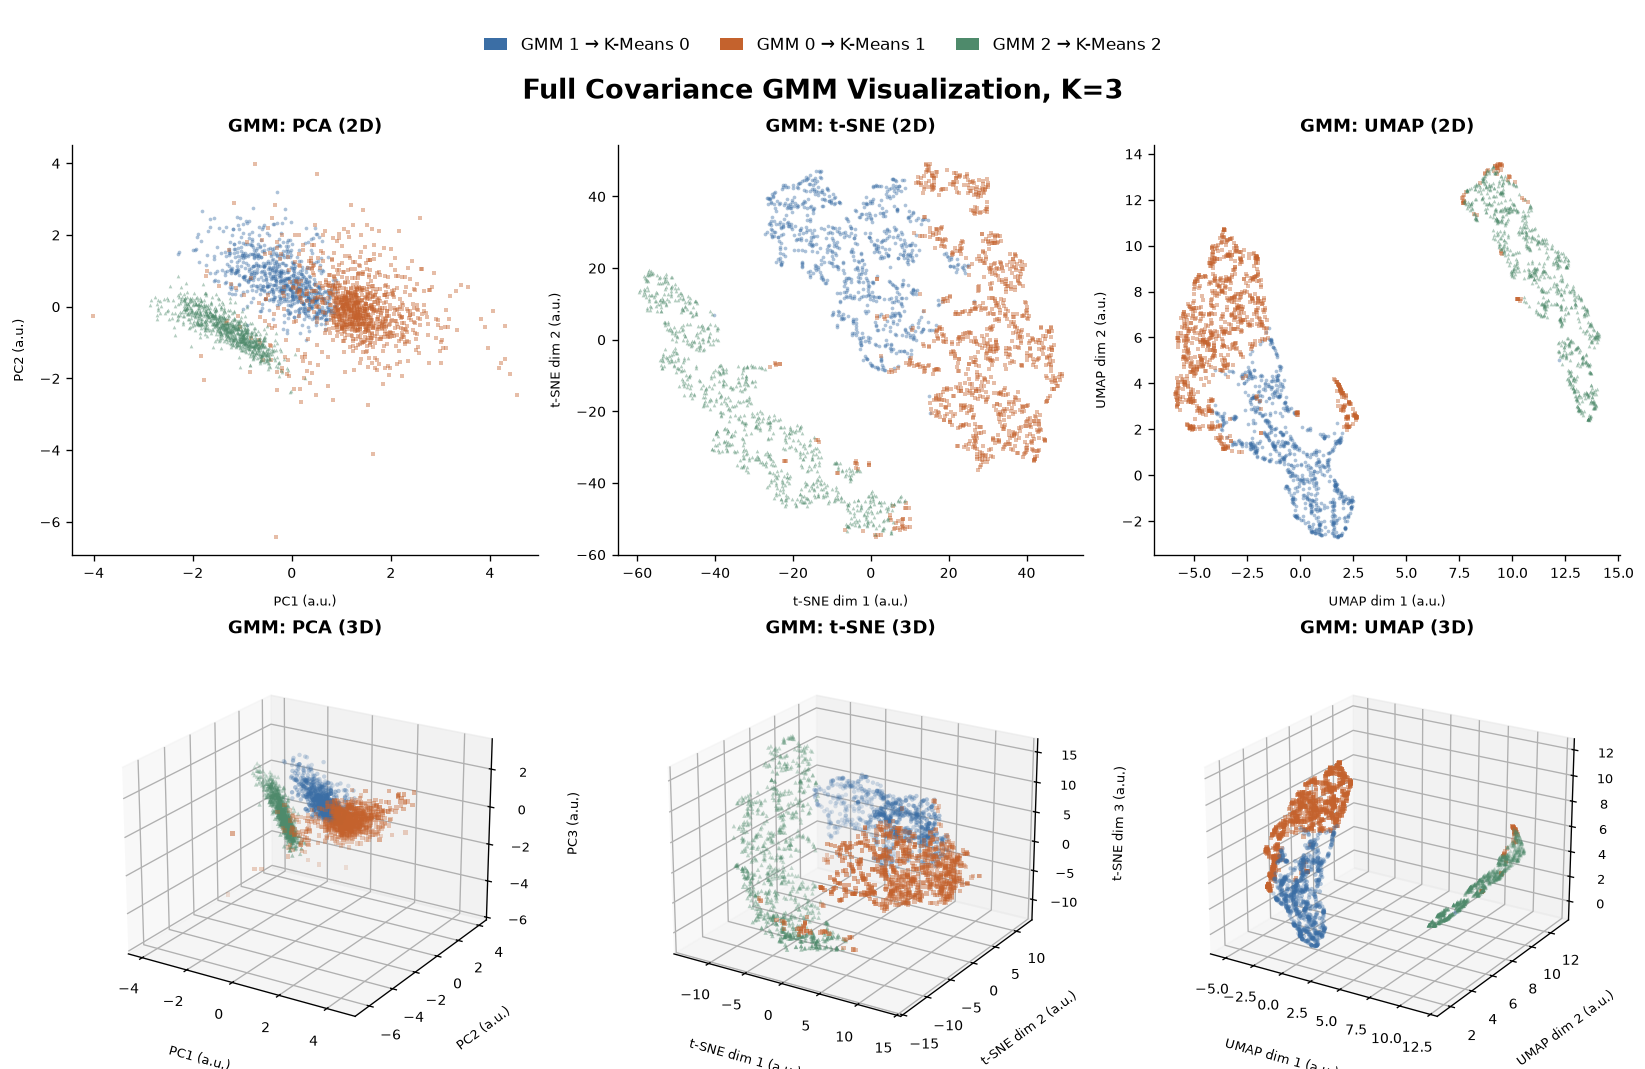

In [250]:
# ================================================================
# A1c. Full-covariance GMM visualizations
#
# PCA, t-SNE and UMAP in 2-D and 3-D.
#
# IMPORTANT:
# - GMM assignments come from gmm_primary.predict(X).
# - GMM is NOT refitted here.
# - Embeddings are the SAME descriptive embeddings used in A1a.
# - GMM component numbers are arbitrary.
# - Display colors are therefore matched to the corresponding
#   K-Means clusters solely to make A1a and A1c comparable.
# ================================================================

from scipy.optimize import linear_sum_assignment
from matplotlib.patches import Patch


# ================================================================
# Fixed K-Means and GMM labels
# ================================================================

kmeans_labels_a1c = np.asarray(
    labels,
    dtype=int
)

gmm_labels_a1c = np.asarray(
    gmm_primary.predict(X),
    dtype=int
)


# ================================================================
# Match arbitrary GMM component IDs to K-Means cluster IDs
#
# This affects COLORS/LABELS ONLY.
# The GMM hard assignments themselves are never changed.
# ================================================================

cross = pd.crosstab(
    pd.Series(
        kmeans_labels_a1c,
        name="K-Means"
    ),
    pd.Series(
        gmm_labels_a1c,
        name="GMM"
    )
)


row_ind, col_ind = linear_sum_assignment(
    -cross.to_numpy()
)


GMM_TO_KMEANS_DISPLAY = {
    int(cross.columns[c]):
    int(cross.index[r])

    for r, c in zip(
        row_ind,
        col_ind
    )
}


print(
    "GMM -> K-Means display mapping:",
    GMM_TO_KMEANS_DISPLAY
)


# ================================================================
# Cluster/component order
#
# Sort by the corresponding K-Means category so legend colors
# appear in the same order as A1a.
# ================================================================

gmm_components = sorted(
    GMM_TO_KMEANS_DISPLAY.keys(),
    key=lambda c:
        GMM_TO_KMEANS_DISPLAY[c]
)


# ================================================================
# Figure
#
# Exactly the same 2 x 3 organization as the K-Means figure:
#
# top:    PCA 2D | t-SNE 2D | UMAP 2D
# bottom: PCA 3D | t-SNE 3D | UMAP 3D
#
# Dedicated top space is reserved for the legend.
# ================================================================

fig = plt.figure(
    figsize=(13.6, 8.8),
    constrained_layout=False
)


for col, name in enumerate(
    methods
):

    for row, d in enumerate(
        (2, 3)
    ):

        # EXACT same embedding coordinates as A1a
        XY_e = emb[
            (name, d)
        ]


        ax = fig.add_subplot(
            2,
            3,
            row * 3 + col + 1,
            projection=(
                "3d"
                if d == 3
                else None
            )
        )


        # ========================================================
        # Plot true GMM assignments
        # ========================================================

        for gmm_component in gmm_components:

            m = (
                gmm_labels_a1c
                ==
                gmm_component
            )


            # Corresponding K-Means category is used ONLY
            # to choose a consistent color and marker.
            display_cluster = (
                GMM_TO_KMEANS_DISPLAY[
                    gmm_component
                ]
            )


            if d == 2:

                ax.scatter(
                    XY_e[m, 0],
                    XY_e[m, 1],
                    s=5,
                    alpha=0.42,
                    linewidths=0,
                    color=cluster_color(
                        display_cluster
                    ),
                    marker=MARKERS[
                        display_cluster
                        % len(MARKERS)
                    ],
                    rasterized=True
                )


            else:

                ax.scatter(
                    XY_e[m, 0],
                    XY_e[m, 1],
                    XY_e[m, 2],
                    s=7,
                    alpha=0.72,
                    linewidths=0,
                    color=cluster_color(
                        display_cluster
                    ),
                    marker=MARKERS[
                        display_cluster
                        % len(MARKERS)
                    ],
                    depthshade=True,
                    rasterized=True
                )


        # ========================================================
        # Axis labels
        # ========================================================

        if name == "PCA":

            ax.set_xlabel(
                "PC1 (a.u.)",
                labelpad=(
                    12 if d == 3 else 8
                )
            )

            ax.set_ylabel(
                "PC2 (a.u.)",
                labelpad=(
                    12 if d == 3 else 8
                )
            )

            if d == 3:

                ax.set_zlabel(
                    "PC3 (a.u.)",
                    labelpad=10
                )


        else:

            ax.set_xlabel(
                f"{name} dim 1 (a.u.)",
                labelpad=(
                    12 if d == 3 else 8
                )
            )

            ax.set_ylabel(
                f"{name} dim 2 (a.u.)",
                labelpad=(
                    12 if d == 3 else 8
                )
            )

            if d == 3:

                ax.set_zlabel(
                    f"{name} dim 3 (a.u.)",
                    labelpad=10
                )


        # ========================================================
        # Panel title
        # ========================================================

        ax.set_title(
            f"GMM: {name} ({d}D)",
            fontsize=10.5,
            fontweight="bold",
            pad=8
        )


        ax.tick_params(
            axis="both",
            labelsize=8.5
        )


        # ========================================================
        # 3-D readability
        # ========================================================

        if d == 3:

            ax.view_init(
                elev=22,
                azim=-58
            )

            ax.zaxis.label.set_color(
                "black"
            )

            ax.tick_params(
                axis="z",
                colors="black",
                labelcolor="black",
                labelsize=8
            )


# ================================================================
# Shared legend
#
# The legend reports BOTH the true GMM component ID and its
# color-matched K-Means category.
#
# Nothing is placed over any subplot.
# ================================================================

gmm_handles = []


for gmm_component in gmm_components:

    display_cluster = (
        GMM_TO_KMEANS_DISPLAY[
            gmm_component
        ]
    )


    gmm_handles.append(
        Patch(
            facecolor=cluster_color(
                display_cluster
            ),
            edgecolor="none",
            label=(
                f"GMM {gmm_component} "
                f"→ K-Means {display_cluster}"
            )
        )
    )

fig.suptitle("\n\nFull Covariance GMM Visualization, K=3", fontsize=16,
            fontweight="bold")

fig.legend(
    handles=gmm_handles,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        0.985
    ),
    ncol=3,
    frameon=False,
    fontsize=10,
    title_fontsize=10,
    handlelength=1.4,
    columnspacing=1.8
)


# ================================================================
# Physical spacing
#
# top=0.88 reserves the entire upper region for the legend.
# bottom=0.18 protects angled 3-D axis labels.
# ================================================================

fig.subplots_adjust(
    left=0.06,
    right=0.98,
    bottom=0.18,
    top=0.96,
    wspace=0.24,
    hspace=0.6
)


# ================================================================
# Save
# ================================================================

save_fig(
    fig,
    "A1c_gmm_embeddings_2d_3d"
)

plt.show()

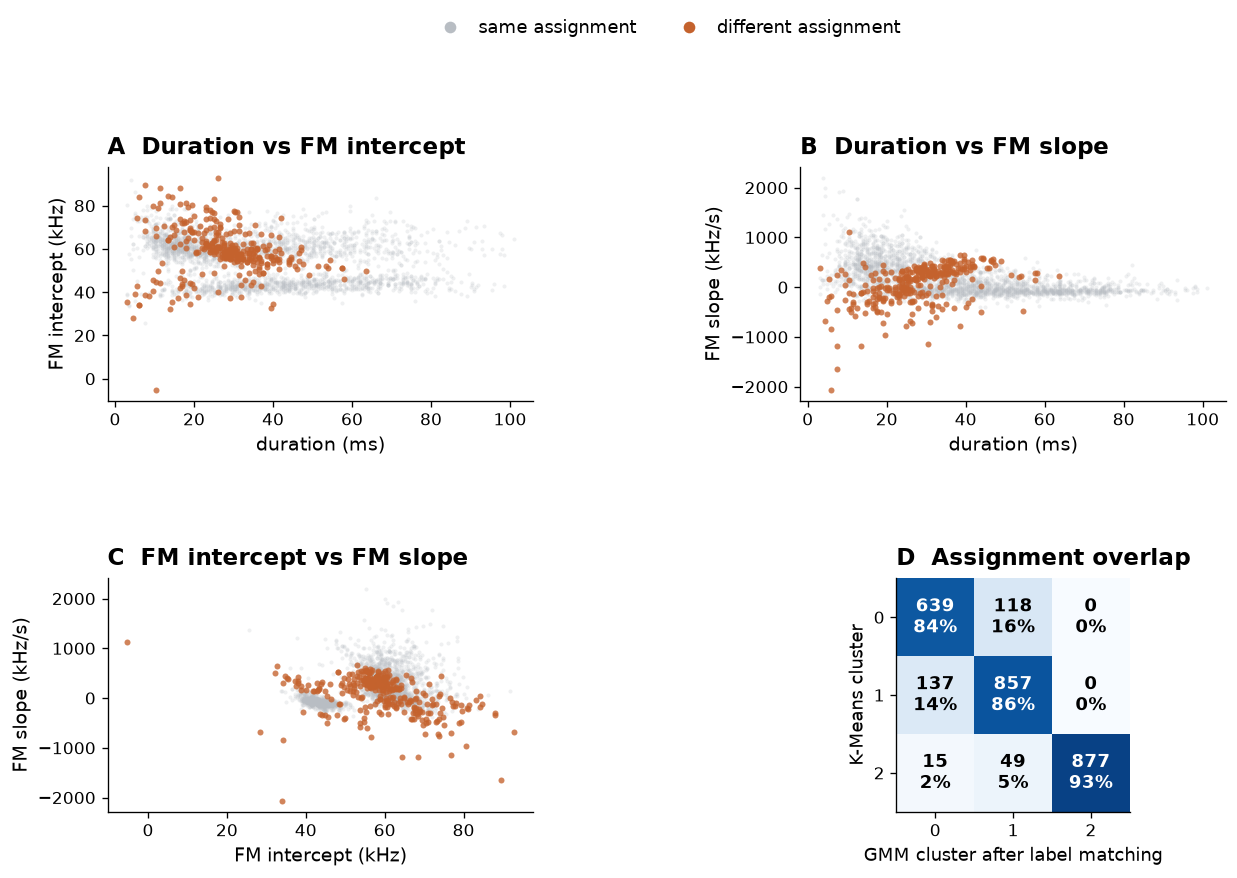

Optimal GMM -> K-Means label mapping: {1: 0, 0: 1, 2: 2}
Adjusted Rand Index: 0.693
Agreement after optimal label matching: 88.2%
Different assignments: 319 / 2,692 (11.8%).


In [245]:
# ================================================================
# A1d. K-Means vs full-covariance GMM
#
# Direct comparison in the ORIGINAL three-feature acoustic space.
#
# A: duration vs FM intercept
# B: duration vs FM slope
# C: FM intercept vs FM slope
# D: K-Means / GMM assignment overlap
#
# Grey points = same assignment after optimal label matching
# Orange points = assignment differs between K-Means and GMM
#
# No clustering is recomputed here.
# ================================================================

from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score
from matplotlib.lines import Line2D


# ================================================================
# Fixed labels from the two existing clustering models
# ================================================================

kmeans_labels = np.asarray(
    labels,
    dtype=int
)

gmm_labels = np.asarray(
    gmm_primary.predict(X),
    dtype=int
)


# ================================================================
# Match arbitrary GMM component numbers to K-Means cluster numbers
#
# Cluster numbers themselves have no meaning, so compare the
# partitions only after finding the best label permutation.
# ================================================================

raw_contingency = pd.crosstab(
    pd.Series(
        kmeans_labels,
        name="K-Means"
    ),
    pd.Series(
        gmm_labels,
        name="GMM"
    )
)


row_ind, col_ind = linear_sum_assignment(
    -raw_contingency.to_numpy()
)


gmm_to_kmeans = {
    int(raw_contingency.columns[c]):
    int(raw_contingency.index[r])

    for r, c in zip(
        row_ind,
        col_ind
    )
}


gmm_aligned = np.array(
    [
        gmm_to_kmeans[int(c)]
        for c in gmm_labels
    ],
    dtype=int
)


same_assignment = (
    kmeans_labels
    ==
    gmm_aligned
)


different_assignment = (
    ~same_assignment
)


# ================================================================
# Agreement statistics
# ================================================================

ari_gmm_kmeans = adjusted_rand_score(
    kmeans_labels,
    gmm_labels
)


agreement_fraction = np.mean(
    same_assignment
)


n_different = int(
    different_assignment.sum()
)


n_total = len(
    kmeans_labels
)


# ================================================================
# Recover acoustic features in their ORIGINAL units
#
# X is standardized, so inverse_transform gives the exact data
# used for clustering back in interpretable acoustic units.
# ================================================================

X_original = cluster_scaler.inverse_transform(
    X
)


feature_df = pd.DataFrame(
    X_original,
    columns=CLUSTER_FEATURES
)


# ================================================================
# Final aligned contingency matrix
# ================================================================

cluster_order = sorted(
    np.unique(
        kmeans_labels
    )
)


contingency = pd.crosstab(
    pd.Series(
        kmeans_labels,
        name="K-Means cluster"
    ),
    pd.Series(
        gmm_aligned,
        name="matched GMM cluster"
    )
).reindex(
    index=cluster_order,
    columns=cluster_order,
    fill_value=0
)


row_fraction = contingency.div(
    contingency.sum(
        axis=1
    ),
    axis=0
)


# ================================================================
# Plot settings
# ================================================================

SAME_COLOR = "#B8BDC3"
DIFFERENT_COLOR = PALETTE["observed"]


feature_pairs = [

    (
        "duration_ms",
        "fm_intercept_khz",
        "A  Duration vs FM intercept",
        "duration (ms)",
        "FM intercept (kHz)"
    ),

    (
        "duration_ms",
        "fm_slope_khz_per_s",
        "B  Duration vs FM slope",
        "duration (ms)",
        "FM slope (kHz/s)"
    ),

    (
        "fm_intercept_khz",
        "fm_slope_khz_per_s",
        "C  FM intercept vs FM slope",
        "FM intercept (kHz)",
        "FM slope (kHz/s)"
    ),
]


# ================================================================
# Figure layout
#
# The legend has its own physical row.
# Nothing overlaps any panel.
# ================================================================

fig = plt.figure(
    figsize=(10.2, 7.2),
    constrained_layout=False
)


gs = fig.add_gridspec(
    nrows=3,
    ncols=2,
    height_ratios=[
        0.10,
        1.0,
        1.0
    ],
    left=0.09,
    right=0.97,
    bottom=0.10,
    top=0.96,
    wspace=0.28,
    hspace=0.32
)


ax_leg = fig.add_subplot(
    gs[0, :]
)

ax_a = fig.add_subplot(
    gs[1, 0]
)

ax_b = fig.add_subplot(
    gs[1, 1]
)

ax_c = fig.add_subplot(
    gs[2, 0]
)

ax_d = fig.add_subplot(
    gs[2, 1]
)


ax_leg.axis(
    "off"
)


scatter_axes = [
    ax_a,
    ax_b,
    ax_c
]


# ================================================================
# A-C. Original acoustic feature space
# ================================================================

for ax, (
    x_feature,
    y_feature,
    title,
    xlabel,
    ylabel
) in zip(
    scatter_axes,
    feature_pairs
):

    # ------------------------------------------------------------
    # Calls assigned consistently
    # ------------------------------------------------------------

    ax.scatter(
        feature_df.loc[
            same_assignment,
            x_feature
        ],
        feature_df.loc[
            same_assignment,
            y_feature
        ],
        s=6,
        color=SAME_COLOR,
        alpha=0.22,
        linewidths=0,
        rasterized=True,
        zorder=1
    )


    # ------------------------------------------------------------
    # Calls whose cluster assignment changes
    # ------------------------------------------------------------

    ax.scatter(
        feature_df.loc[
            different_assignment,
            x_feature
        ],
        feature_df.loc[
            different_assignment,
            y_feature
        ],
        s=13,
        color=DIFFERENT_COLOR,
        alpha=0.78,
        linewidths=0,
        rasterized=True,
        zorder=3
    )


    ax.set_title(
        title,
        loc="left",
        fontsize=14,
        fontweight="bold",
        pad=8
    )


    ax.set_xlabel(
        xlabel,
        fontsize=11.5
    )


    ax.set_ylabel(
        ylabel,
        fontsize=11.5
    )


    ax.tick_params(
        axis="both",
        labelsize=10
    )


# ================================================================
# D. Assignment-overlap matrix
#
# Rows sum to 100%.
# Text shows:
#     number of calls
#     percentage of that K-Means cluster
# ================================================================

im = ax_d.imshow(
    row_fraction.to_numpy(),
    cmap="Blues",
    vmin=0,
    vmax=1
)


for r in range(
    len(cluster_order)
):

    for c in range(
        len(cluster_order)
    ):

        count = int(
            contingency.iloc[
                r,
                c
            ]
        )

        fraction = float(
            row_fraction.iloc[
                r,
                c
            ]
        )


        ax_d.text(
            c,
            r,
            f"{count:,}\n{fraction:.0%}",
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            color=(
                "white"
                if fraction >= 0.55
                else "black"
            )
        )


ax_d.set_xticks(
    range(
        len(cluster_order)
    )
)


ax_d.set_xticklabels(
    cluster_order
)


ax_d.set_yticks(
    range(
        len(cluster_order)
    )
)


ax_d.set_yticklabels(
    cluster_order
)


ax_d.set_xlabel(
    "GMM cluster after label matching",
    fontsize=11
)


ax_d.set_ylabel(
    "K-Means cluster",
    fontsize=11
)


ax_d.set_title(
    "D  Assignment overlap",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)


ax_d.tick_params(
    axis="both",
    labelsize=10
)


# ================================================================
# Shared legend
# ================================================================

legend_handles = [

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=SAME_COLOR,
        markeredgecolor="none",
        markersize=7,
        label="same assignment"
    ),

    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="none",
        markerfacecolor=DIFFERENT_COLOR,
        markeredgecolor="none",
        markersize=7,
        label="different assignment"
    )
]


ax_leg.legend(
    handles=legend_handles,
    loc="center",
    ncol=2,
    frameon=False,
    fontsize=10.5,
    handletextpad=0.6,
    columnspacing=2.0
)


# ================================================================
# Save
# ================================================================

save_fig(
    fig,
    "A1c_kmeans_gmm_comparison"
)

plt.show()


# ================================================================
# Numerical summary for notebook / manuscript
# ================================================================

print(
    "Optimal GMM -> K-Means label mapping:",
    gmm_to_kmeans
)


print(
    f"Adjusted Rand Index: "
    f"{ari_gmm_kmeans:.3f}"
)


print(
    f"Agreement after optimal label matching: "
    f"{100 * agreement_fraction:.1f}%"
)


print(
    f"Different assignments: "
    f"{n_different:,} / {n_total:,} "
    f"({100 * n_different / n_total:.1f}%)."
)

In [248]:
# ================================================================
# SANITY CHECK — Are K-Means and GMM really different?
# ================================================================

from sklearn.metrics import adjusted_rand_score
from scipy.optimize import linear_sum_assignment


# ------------------------------------------------
# Fixed labels from the two independently fitted models
# ------------------------------------------------

kmeans_labels_check = np.asarray(
    labels,
    dtype=int
)

gmm_labels_check = np.asarray(
    gmm_primary.predict(X),
    dtype=int
)


# ------------------------------------------------
# Basic checks
# ------------------------------------------------

print(
    "Same label array exactly:",
    np.array_equal(
        kmeans_labels_check,
        gmm_labels_check
    )
)

ari_check = adjusted_rand_score(
    kmeans_labels_check,
    gmm_labels_check
)

print(
    f"Adjusted Rand Index: {ari_check:.3f}"
)


# ================================================================
# Contingency table
# ================================================================

contingency = pd.crosstab(
    pd.Series(
        kmeans_labels_check,
        name="K-Means"
    ),
    pd.Series(
        gmm_labels_check,
        name="GMM"
    )
)

display(
    contingency
)


# ================================================================
# Find best GMM -> K-Means label permutation
#
# Cluster numbers themselves are arbitrary.
# ================================================================

matrix = contingency.to_numpy()

row_ind, col_ind = linear_sum_assignment(
    -matrix
)

gmm_to_kmeans = {
    int(
        contingency.columns[c]
    ):
    int(
        contingency.index[r]
    )
    for r, c in zip(
        row_ind,
        col_ind
    )
}


gmm_aligned = np.array([
    gmm_to_kmeans[
        int(c)
    ]
    for c in gmm_labels_check
])


agreement = np.mean(
    gmm_aligned
    ==
    kmeans_labels_check
)

n_different = int(
    np.sum(
        gmm_aligned
        !=
        kmeans_labels_check
    )
)


print(
    "Best GMM -> K-Means label mapping:",
    gmm_to_kmeans
)

print(
    f"Agreement after optimal relabeling: "
    f"{100 * agreement:.1f}%"
)

print(
    f"Calls assigned differently after relabeling: "
    f"{n_different:,} / {len(X):,}"
)




Same label array exactly: False
Adjusted Rand Index: 0.693


GMM,0,1,2
K-Means,,,
0,118,639,0
1,857,137,0
2,49,15,877


Best GMM -> K-Means label mapping: {1: 0, 0: 1, 2: 2}
Agreement after optimal relabeling: 88.2%
Calls assigned differently after relabeling: 319 / 2,692


### A2. Which feature carries the partition

Each feature is removed in turn, the calls are re-clustered on what remains at the
same K, and the result is compared with the full partition by adjusted Rand index.
A low value means the removed feature was doing the work.

In [225]:
abl_rows = []
for feat in CLUSTER_FEATURES:
    kept = [f for f in CLUSTER_FEATURES if f != feat]
    Xa, _, idx_a = prepare_matrix(ok, kept)
    lab_a = KMeans(K_PRIMARY, n_init=10, random_state=RANDOM_SEED).fit_predict(Xa)
    pos = pd.Index(cluster_idx).get_indexer(idx_a)
    abl_rows.append(dict(removed=feat, n_features_left=len(kept),
                         ari_vs_full=adjusted_rand_score(labels[pos], lab_a)))
ablation_features = pd.DataFrame(abl_rows).sort_values("ari_vs_full")
show(ablation_features)

_worst = ablation_features.iloc[0]
_best = ablation_features.iloc[-1]
print(f"Removing {_worst['removed']} changes the partition most "
      f"(ARI {_worst['ari_vs_full']:.3f}); removing {_best['removed']} changes it least "
      f"(ARI {_best['ari_vs_full']:.3f}).")
print("This says which feature the grouping leans on. It does not say the others are "
      "useless: a feature can be redundant with those kept and still describe the calls "
      "correctly.")

,removed,n_features_left,ari_vs_full
1,fm_intercept_khz,2,0.334
2,fm_slope_khz_per_s,2,0.446
0,duration_ms,2,0.722


Removing fm_intercept_khz changes the partition most (ARI 0.334); removing duration_ms changes it least (ARI 0.722).
This says which feature the grouping leans on. It does not say the others are useless: a feature can be redundant with those kept and still describe the calls correctly.


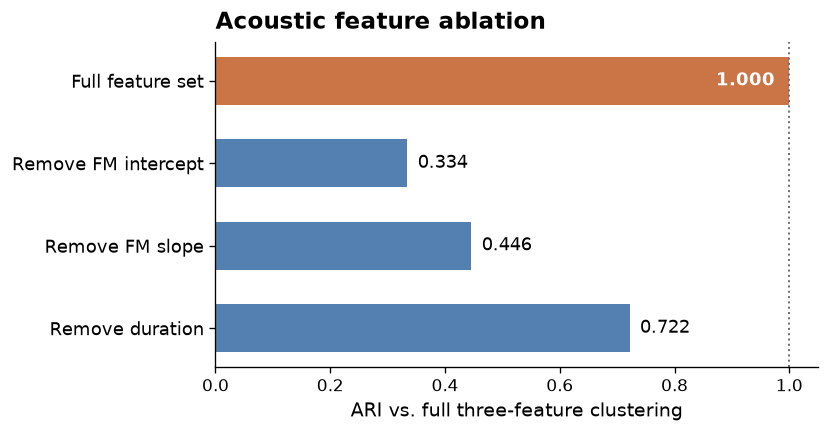

In [226]:
# ================================================================
# B.9 — Acoustic feature ablation
#
# Visualizes EXISTING ablation_features results only.
# No clustering is recomputed here.
# ================================================================

from matplotlib.patches import Patch


# ================================================================
# Build plotting table
# ================================================================

feature_names = {
    "fm_intercept_khz": "Remove FM intercept",
    "fm_slope_khz_per_s": "Remove FM slope",
    "duration_ms": "Remove duration",
}


ablation_plot = ablation_features[
    [
        "removed",
        "ari_vs_full"
    ]
].copy()


ablation_plot["label"] = (
    ablation_plot["removed"]
    .map(feature_names)
)


# Lowest-to-highest ARI for the ablations
ablation_plot = (
    ablation_plot
    .sort_values(
        "ari_vs_full",
        ascending=True
    )
    .reset_index(drop=True)
)


# Add full baseline at the top
plot_df = pd.concat(
    [
        pd.DataFrame({
            "label": ["Full feature set"],
            "ari_vs_full": [1.0]
        }),

        ablation_plot[
            [
                "label",
                "ari_vs_full"
            ]
        ]
    ],
    ignore_index=True
)


# ================================================================
# Plot
# ================================================================

fig, ax = plt.subplots(
    figsize=(6.8, 3.5),
    constrained_layout=False
)


fig.subplots_adjust(
    left=0.30,
    right=0.96,
    bottom=0.20,
    top=0.87
)


y = np.arange(
    len(plot_df)
)


colors = [
    PALETTE["observed"],
    PALETTE["accent"],
    PALETTE["accent"],
    PALETTE["accent"],
]


bars = ax.barh(
    y,
    plot_df["ari_vs_full"],
    height=0.58,
    color=colors,
    alpha=0.88,
    edgecolor="none"
)


# ================================================================
# Exact ARI labels
# ================================================================

for bar, ari in zip(
    bars,
    plot_df["ari_vs_full"]
):

    # Keep the baseline label inside the plotting range.
    if ari > 0.94:

        ax.text(
            ari - 0.025,
            bar.get_y() + bar.get_height()/2,
            f"{ari:.3f}",
            ha="right",
            va="center",
            fontsize=10.5,
            color="white",
            fontweight="bold"
        )

    else:

        ax.text(
            ari + 0.018,
            bar.get_y() + bar.get_height()/2,
            f"{ari:.3f}",
            ha="left",
            va="center",
            fontsize=10.5
        )


# ================================================================
# Axes
# ================================================================

ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df["label"],
    fontsize=10.5
)


ax.invert_yaxis()


ax.set_xlim(
    0,
    1.05
)


ax.set_xlabel(
    "ARI vs. full three-feature clustering",
    fontsize=11.5
)


ax.set_title(
    "Acoustic feature ablation",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)


ax.tick_params(
    axis="x",
    labelsize=10
)


ax.axvline(
    1.0,
    color=PALETTE["muted"],
    linestyle=":",
    linewidth=1.2
)


# ================================================================
# Save
# ================================================================

save_fig(
    fig,
    "supp_feature_ablation"
)

plt.show()

### A3. Does the neural result depend on the recorded region?

The two animals were not implanted in the same place. Cells are grouped by the
prefix of their `brainArea` label: the *pfc* group is every cell whose label
begins with one of `PFC_PREFIXES` (`PL`, `ILA`, `ACAd` — prelimbic, infralimbic,
anterior cingulate), and *other* is the rest. In M7 most recorded cells fall in
*pfc*; in M8 most fall in *other*. The distinct label set in each group is printed
with the cell counts below. Averaging over every recorded cell could dilute a
signal that lives in only one of these targets.

The decoding is re-run at the primary K on the *pfc* cells only, on the *other*
cells only, and on all cells, with the same folds, model and null. Cell counts per
group are printed first, because a group with very few cells cannot support a
conclusion either way.


In [217]:
area_counts = pd.DataFrame([
    dict(session=lab, n_all=len(sessions[lab].cell_area),
         n_pfc=len(cells_in_group(sessions[lab], "pfc")),
         n_other=len(cells_in_group(sessions[lab], "other")))
    for lab in DECODE_SESSIONS])
show(area_counts)

_area_labels = {g: sorted({str(a) for lab in DECODE_SESSIONS
                           for a in np.asarray(sessions[lab].cell_area)[
                               cells_in_group(sessions[lab], g)]})
                for g in ("pfc", "other")}
print("brainArea labels, pfc group:  " + ", ".join(_area_labels["pfc"]))
print("brainArea labels, other group: " + ", ".join(_area_labels["other"]))

t0 = time.time()
area_rows = []
for group in ("all", "pfc", "other"):
    for lab in DECODE_SESSIONS:
        if len(cells_in_group(sessions[lab], group)) < 5:
            continue
        def _run(group=group, lab=lab):
            return run_test(*call_dataset(lab, cell_group=group), model=make_model())
        r = cached(f"area_{group}_{lab}", _run)
        r = {k: v for k, v in r.items() if not k.startswith("_")}
        area_rows.append(dict(cell_group=group, session=lab, **r))
ablation_area = pd.DataFrame(area_rows)
ablation_area["q_bh"] = bh_fdr(ablation_area["p_circular"].values)
ablation_area["significant"] = ablation_area["q_bh"] < 0.05
show(ablation_area, floor=p_floor(N_NULL_SHUFFLES))

print(f"(elapsed {time.time()-t0:.0f}s)")
print("Mean macro-F1 by cell group: " + ", ".join(
    f"{g} {v:.3f}" for g, v in
    ablation_area.groupby("cell_group")["macro_f1"].mean().items()) + ".")
print(f"{int(ablation_area['significant'].sum())}/{len(ablation_area)} tests significant "
      "after BH-FDR within this appendix's own family.")

,session,n_all,n_pfc,n_other
0,M7_F1,166,150,16
1,M7_F2,177,158,19
2,M7_F3,163,144,19
3,M7_F4,212,165,47
4,M8_F2,130,35,95
5,M8_F3,98,17,81
6,M8_F4,139,37,102


brainArea labels, pfc group:  ACAd5, ILA2/3, ILA5, ILA6a, PL2/3, PL5
brainArea labels, other group: DP, LSr, MOs2/3, MOs5, MS, STR, TTd


,cell_group,session,n,n_classes,accuracy,macro_f1,majority_trainfold,majority_testfold,p_circular,q_bh,significant
0,all,M7_F1,574,3,0.378,0.333,0.260,0.563,0.6394,0.8846,False
1,all,M7_F2,727,3,0.399,0.392,0.442,0.462,0.0020,0.0420,True
2,all,M7_F3,841,3,0.373,0.370,0.404,0.433,0.1179,0.4951,False
3,all,M7_F4,129,3,0.705,0.406,0.760,0.760,0.0919,0.4825,False
4,all,M8_F2,119,3,0.479,0.359,0.588,0.714,0.2847,0.6746,False
5,all,M8_F3,136,3,0.346,0.291,0.412,0.522,0.6853,0.8846,False
6,all,M8_F4,129,3,0.527,0.272,0.721,0.729,0.8811,0.9252,False
7,pfc,M7_F1,574,3,0.385,0.336,0.260,0.563,0.6004,0.8846,False
8,pfc,M7_F2,727,3,0.392,0.383,0.442,0.462,0.0130,0.1364,False
9,pfc,M7_F3,841,3,0.390,0.389,0.404,0.433,0.0200,0.1399,False


(elapsed 339s)
Mean macro-F1 by cell group: all 0.346, other 0.314, pfc 0.361.
1/21 tests significant after BH-FDR within this appendix's own family.


### A4. Excluding sessions with a very small class

The inclusion rule in §10 counts usable calls in total, not per class. With three
clusters a session can clear that threshold and still contain a class of a dozen
calls spread over the cross-validation folds. Macro-F1 weights every class
equally, so such a session contributes a third of its score from a handful of test
samples, which is a noisy number.

This appendix re-corrects results already computed, restricted to sessions with at
least the required number of calls in **every** class. It sits here rather than in
the main analysis because the rule was written after the per-session p-values had
been seen, so it cannot claim to have been fixed in advance. Both families are
shown, and the restricted one is exploratory.

In [218]:
per_class = ok.groupby(["session", "cluster"]).size().unstack(fill_value=0)
per_class["min_class"] = per_class.min(axis=1)
per_class["passes"] = per_class["min_class"] >= MIN_PER_CLASS_FOR_DECODING
show(per_class.loc[DECODE_SESSIONS])

WELL_POWERED = [l for l in DECODE_SESSIONS if bool(per_class.loc[l, "passes"])]
print(f"Sessions with at least {MIN_PER_CLASS_FOR_DECODING} calls in every class: "
      + (", ".join(WELL_POWERED) if WELL_POWERED else "none"))

if WELL_POWERED:
    sub = decode[decode["session"].isin(WELL_POWERED)].copy()
    sub["q_bh_restricted"] = bh_fdr(sub["p_circular"].values)
    sub["significant_restricted"] = sub["q_bh_restricted"] < 0.05
    show(sub[["K", "session", "macro_f1", "p_circular", "q_bh", "q_bh_restricted",
              "significant_restricted"]], floor=p_floor(N_NULL_SHUFFLES))

    rows = []
    for k in DECODING_K_SWEEP:
        g = sub[sub["K"] == k]
        f, st = combine_p(g["p_circular"].values)
        rows.append(dict(target=f"call type, K = {k}", n_sessions=len(g),
                         p_fisher=f, p_stouffer=st))
    for name, grp in control[control["session"].isin(WELL_POWERED)].groupby("control"):
        f, st = combine_p(grp["p_circular"].values)
        rows.append(dict(target=f"control: {name}", n_sessions=len(grp),
                         p_fisher=f, p_stouffer=st))
    restricted = pd.DataFrame(rows)
    restricted["q_fisher"] = bh_fdr(restricted["p_fisher"].values)
    restricted["significant"] = restricted["q_fisher"] < 0.05
    show(restricted)

    print(f"\nPer session, restricted family of {len(sub)} tests: "
          f"{int(sub['significant_restricted'].sum())} significant after BH-FDR.")
    print(f"Combined across the {len(WELL_POWERED)} sessions: "
          f"{int(restricted['significant'].sum())}/{len(restricted)} significant.")
    _mice = sorted({sessions[l].mouse for l in WELL_POWERED})
    print(f"\nEvery session in this restricted set comes from {', '.join(_mice)}. Anything "
          "read from it is a within-animal statement, not a claim across animals, and it "
          "rests on a rule chosen after the results were visible. It belongs in a "
          "discussion of what to test next, not in the conclusions.")

cluster,0,1,2,min_class,passes
session,,,,,
M7_F1,146,202,226,146,True
M7_F2,224,321,182,182,True
M7_F3,249,340,252,249,True
M7_F4,13,18,98,13,False
M8_F2,22,27,70,22,False
M8_F3,63,58,15,15,False
M8_F4,17,19,93,17,False


Sessions with at least 30 calls in every class: M7_F1, M7_F2, M7_F3


,K,session,macro_f1,p_circular,q_bh,q_bh_restricted,significant_restricted
0,2,M7_F1,0.509,0.5854,0.7995,0.6394,False
1,2,M7_F2,0.506,0.2757,0.6105,0.4963,False
2,2,M7_F3,0.520,0.4326,0.7570,0.6394,False
7,3,M7_F1,0.333,0.6394,0.7995,0.6394,False
8,3,M7_F2,0.392,0.0020,0.0420,0.0180,True
9,3,M7_F3,0.370,0.1179,0.4951,0.2652,False
14,4,M7_F1,0.258,0.5455,0.7995,0.6394,False
15,4,M7_F2,0.280,0.0250,0.2622,0.1124,False
16,4,M7_F3,0.284,0.0669,0.4685,0.2008,False


,target,n_sessions,p_fisher,p_stouffer,q_fisher,significant
0,"call type, K = 2",3,0.5030,0.3755,0.5030,False
1,"call type, K = 3",3,0.0073,0.0162,0.0183,True
2,"call type, K = 4",3,0.0296,0.0267,0.0494,True
3,"control: call type, post-call window",3,0.1325,0.0828,0.1657,False
4,control: calling vs quiet,3,0.0037,0.0014,0.0183,True



Per session, restricted family of 9 tests: 1 significant after BH-FDR.
Combined across the 3 sessions: 3/5 significant.

Every session in this restricted set comes from M7. Anything read from it is a within-animal statement, not a claim across animals, and it rests on a rule chosen after the results were visible. It belongs in a discussion of what to test next, not in the conclusions.


### A5. Does the bout threshold matter?

Section 4 derived the threshold from the knee of the bout-count curve, having first
shown that the interval distribution offers no natural cut. The threshold controls
how calls are grouped for cross-validation, so it could in principle change the
decoding. The decoding is re-run at the primary K with the grouping recomputed at
neighbouring thresholds.

In [222]:
t0 = time.time()
gap_rows = []
for gap in BOUT_GAP_SENSITIVITY:
    lab_gap = ok.copy()
    parts = []
    for lab, grp in lab_gap.groupby("session", sort=False):
        b = label_calls_by_bout(grp["call_time"].values, gap)
        b.index = grp.index
        parts.append(b["bout_id"])
    lab_gap["bout_id"] = pd.concat(parts)
    for lab in DECODE_SESSIONS:
        def _run(gap=gap, lab=lab, lab_gap=lab_gap):
            return run_test(*call_dataset(lab, labels_df=lab_gap), model=make_model())
        r = cached(f"gap_{gap}_{lab}", _run)
        r = {k: v for k, v in r.items() if not k.startswith("_")}
        gap_rows.append(dict(bout_gap_s=gap, session=lab, **r))
ablation_gap = pd.DataFrame(gap_rows)
ablation_gap["q_bh"] = bh_fdr(ablation_gap["p_circular"].values)
ablation_gap["significant"] = ablation_gap["q_bh"] < 0.05
show(ablation_gap, floor=p_floor(N_NULL_SHUFFLES))

print(f"(elapsed {time.time()-t0:.0f}s)")
print("Mean macro-F1 by bout threshold: " + ", ".join(
    f"{g:g} s -> {v:.3f}" for g, v in
    ablation_gap.groupby("bout_gap_s")["macro_f1"].mean().items()) + ".")
print(f"{int(ablation_gap['significant'].sum())}/{len(ablation_gap)} tests significant "
      f"after BH-FDR. The threshold used in the analysis is {BOUT_GAP_S:g} s, and the "
      "conclusion is the same at the neighbouring values, so it does not rest on that "
      "particular choice.")

,bout_gap_s,session,n,n_classes,accuracy,macro_f1,majority_trainfold,majority_testfold,p_circular,q_bh,significant
0,0.3,M7_F1,574,3,0.399,0.363,0.218,0.568,0.5045,0.6956,False
1,0.3,M7_F2,727,3,0.399,0.390,0.442,0.459,0.0030,0.0280,True
2,0.3,M7_F3,841,3,0.379,0.374,0.404,0.447,0.0969,0.3392,False
3,0.3,M7_F4,129,3,0.690,0.343,0.760,0.760,0.4356,0.6956,False
4,0.3,M8_F2,119,3,0.521,0.411,0.588,0.723,0.1548,0.4065,False
5,0.3,M8_F3,136,3,0.338,0.297,0.419,0.515,0.6264,0.6956,False
6,0.3,M8_F4,129,3,0.512,0.281,0.721,0.721,0.7712,0.7712,False
7,0.4,M7_F1,574,3,0.397,0.356,0.192,0.554,0.5215,0.6956,False
8,0.4,M7_F2,727,3,0.395,0.390,0.442,0.457,0.0040,0.0280,True
9,0.4,M7_F3,841,3,0.373,0.368,0.404,0.440,0.1309,0.3926,False


(elapsed 177s)
Mean macro-F1 by bout threshold: 0.3 s -> 0.351, 0.4 s -> 0.355, 0.6 s -> 0.344.
3/21 tests significant after BH-FDR. The threshold used in the analysis is 0.4 s, and the conclusion is the same at the neighbouring values, so it does not rest on that particular choice.


### A6. Do the excluded (low-quality) calls differ acoustically from the retained ones?

§6-§8 cluster and decode only calls that pass acoustic quality control
(`is_low_quality == False`). If the excluded calls were an acoustically distinct
subset, the retained sample — and the cluster definitions built from it — would be
biased. This appendix checks that directly, as a **quality-control step, not a
result**.

Two caveats. Some exclusion reasons (`no_anchor`, `file_edge`) leave a call with
no measurable contour at all, so those calls are only counted, not compared; the
table below is over the excluded calls that do have a tracked contour (mostly
`low_snr` and `edge_truncated`). And `snr_frac` is left out of the comparison
because it is part of what defines the exclusion — comparing it would be circular.
Wording is kept cautious: the aim is only to show whether filtering visibly shifts
the acoustic sample, measured by Cliff's delta, not to declare the two groups
equal or different.


,feature,n_retained,n_excluded,median_retained,median_excluded,cliffs_delta,p,q_bh,effect
0,duration_ms,2692,1036,32.500,33.500,-0.059,0.0055,0.0062,negligible
1,fm_intercept_khz,2692,1035,58.078,61.814,-0.238,1.61e-29,4.30e-29,small
2,fm_slope_khz_per_s,2692,1035,59.733,34.666,0.050,0.0180,0.0180,negligible
3,freq_min_khz,2692,1035,53.500,53.500,-0.065,0.0022,0.0030,negligible
4,freq_max_khz,2692,1035,67.500,69.500,-0.142,1.67e-11,3.34e-11,negligible
5,bandwidth_khz,2692,1036,15.453,18.043,-0.462,5.90e-106,4.72e-105,medium
6,peak_freq_khz,2692,1036,62.000,63.500,-0.125,3.10e-09,4.97e-09,negligible
7,mean_freq_khz,2692,1036,66.098,68.430,-0.330,6.44e-55,2.57e-54,small


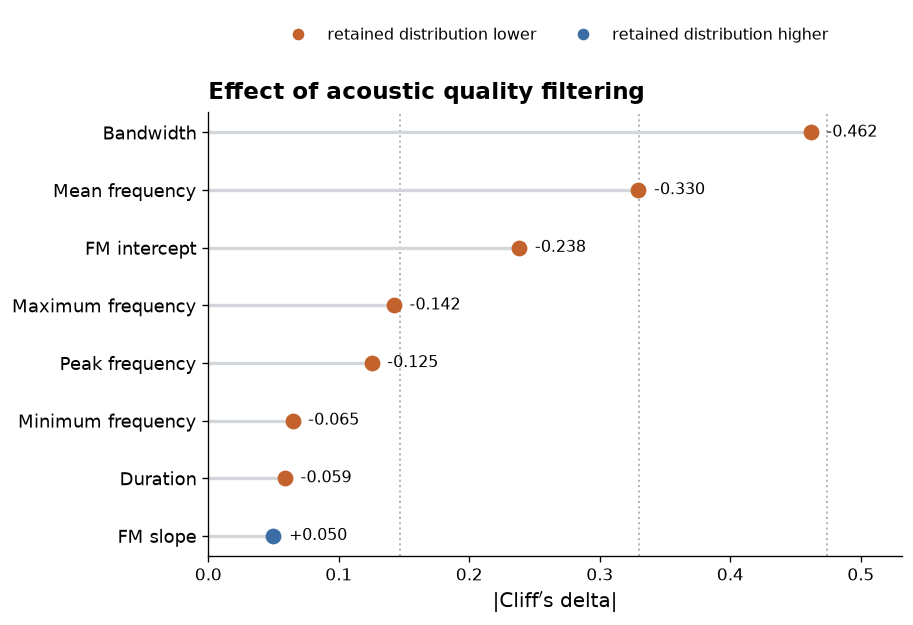

Largest shift: bandwidth, Cliff's delta=-0.462, q=4.72e-105.
2692 retained calls, 1292 excluded; 256 excluded calls have no measurable contour.


In [223]:
# ================================================================
# SUPPLEMENT — Effect of acoustic quality filtering
# ================================================================

from matplotlib.lines import Line2D


# ================================================================
# Analysis
# ================================================================

QC_COMPARE_FEATURES = [
    f
    for f in [
        "duration_ms",
        "fm_intercept_khz",
        "fm_slope_khz_per_s",
        "freq_min_khz",
        "freq_max_khz",
        "bandwidth_khz",
        "peak_freq_khz",
        "mean_freq_khz",
    ]
    if f in features.columns
]


retained = features[
    ~features["is_low_quality"]
]


excluded = features[
    features["is_low_quality"]
]


n_no_contour = int(
    excluded["duration_ms"]
    .isna()
    .sum()
)


qc_rows = []


for feat in QC_COMPARE_FEATURES:

    a = retained[
        feat
    ].dropna().values


    b = excluded[
        feat
    ].dropna().values


    if (
        len(a) < 20
        or
        len(b) < 20
    ):
        continue


    U, p = stats.mannwhitneyu(
        a,
        b,
        alternative="two-sided"
    )


    qc_rows.append(
        dict(
            feature=feat,
            n_retained=len(a),
            n_excluded=len(b),
            median_retained=float(
                np.median(a)
            ),
            median_excluded=float(
                np.median(b)
            ),
            cliffs_delta=(
                2 * U
                /
                (
                    len(a)
                    *
                    len(b)
                )
                - 1
            ),
            p=p
        )
    )


qc_compare = pd.DataFrame(
    qc_rows
)


qc_compare[
    "q_bh"
] = bh_fdr(
    qc_compare[
        "p"
    ].values
)


qc_compare[
    "effect"
] = pd.cut(
    qc_compare[
        "cliffs_delta"
    ].abs(),
    [
        -.01,
        .147,
        .33,
        .474,
        1
    ],
    labels=[
        "negligible",
        "small",
        "medium",
        "large"
    ]
)


show(
    qc_compare,
    decimals=3
)


# ================================================================
# Plot table
# ================================================================

FEATURE_LABELS = {
    "duration_ms": "Duration",
    "fm_intercept_khz": "FM intercept",
    "fm_slope_khz_per_s": "FM slope",
    "freq_min_khz": "Minimum frequency",
    "freq_max_khz": "Maximum frequency",
    "bandwidth_khz": "Bandwidth",
    "peak_freq_khz": "Peak frequency",
    "mean_freq_khz": "Mean frequency",
}


plot_df = qc_compare.copy()


plot_df[
    "display"
] = plot_df[
    "feature"
].map(
    FEATURE_LABELS
)


plot_df[
    "magnitude"
] = plot_df[
    "cliffs_delta"
].abs()


plot_df = (
    plot_df
    .sort_values(
        "magnitude",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ================================================================
# Figure
#
# Direction legend gets its own row.
# ================================================================

fig = plt.figure(
    figsize=(7.5, 5.1),
    constrained_layout=False
)


gs = fig.add_gridspec(
    nrows=2,
    ncols=1,
    height_ratios=[
        0.11,
        1.0
    ],
    left=0.24,
    right=0.96,
    bottom=0.15,
    top=0.95,
    hspace=0.07
)


ax_leg = fig.add_subplot(
    gs[0, 0]
)

ax = fig.add_subplot(
    gs[1, 0]
)


ax_leg.axis(
    "off"
)


# ================================================================
# Conventional effect-size boundaries
# ================================================================

for boundary in [
    0.147,
    0.33,
    0.474
]:

    ax.axvline(
        boundary,
        color="#AEB5BC",
        linestyle=":",
        linewidth=1.2,
        zorder=0
    )


# ================================================================
# Lollipop plot
# ================================================================

y = np.arange(
    len(plot_df)
)


for yi, row in plot_df.iterrows():

    magnitude = float(
        row["magnitude"]
    )

    delta = float(
        row["cliffs_delta"]
    )


    color = (
        PALETTE["observed"]
        if delta < 0
        else PALETTE["accent"]
    )


    ax.hlines(
        yi,
        0,
        magnitude,
        color="#D3D7DB",
        linewidth=2.0,
        zorder=1
    )


    ax.scatter(
        magnitude,
        yi,
        s=72,
        color=color,
        zorder=3
    )


    ax.text(
        magnitude + 0.012,
        yi,
        f"{delta:+.3f}",
        ha="left",
        va="center",
        fontsize=9.5
    )


ax.set_yticks(
    y
)


ax.set_yticklabels(
    plot_df[
        "display"
    ],
    fontsize=10.5
)


ax.invert_yaxis()


xmax = max(
    0.53,
    plot_df[
        "magnitude"
    ].max()
    + 0.07
)


ax.set_xlim(
    0,
    xmax
)


ax.set_xlabel(
    r"$|\mathrm{Cliff's\ delta}|$",
    fontsize=12
)


ax.set_title(
    "Effect of acoustic quality filtering",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)


ax.tick_params(
    axis="x",
    labelsize=10
)


# ================================================================
# Dedicated direction legend
# ================================================================

ax_leg.legend(
    handles=[
        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=PALETTE["observed"],
            markeredgecolor="none",
            markersize=7,
            label="retained distribution lower"
        ),

        Line2D(
            [0],
            [0],
            marker="o",
            linestyle="none",
            markerfacecolor=PALETTE["accent"],
            markeredgecolor="none",
            markersize=7,
            label="retained distribution higher"
        )
    ],
    loc="center",
    ncol=2,
    frameon=False,
    fontsize=9.8,
    columnspacing=1.8
)


save_fig(
    fig,
    "supp_quality_filter_effect_sizes"
)

plt.show()


# ================================================================
# Notebook text, NOT inside the plot
# ================================================================

band = qc_compare.loc[
    qc_compare[
        "feature"
    ] == "bandwidth_khz"
].iloc[0]


print(
    f"Largest shift: bandwidth, "
    f"Cliff's delta={band['cliffs_delta']:+.3f}, "
    f"q={band['q_bh']:.2e}."
)


print(
    f"{len(retained)} retained calls, "
    f"{len(excluded)} excluded; "
    f"{n_no_contour} excluded calls have no measurable contour."
)

### A7. Grouped vs. random cross-validation (leakage demonstration — not a valid result)

The decoding in §11-§13 groups cross-validation folds by `bout_id`, so no bout is
split across train and test. Calls in one bout are seconds apart, share an
overlapping look-back window, and agree on call type well above chance (§10), so a
split that ignored bouts would let the model train on near-duplicates of its test
calls.

This appendix re-runs the primary-K decoding with **random** K-fold splits over
individual calls, bouts ignored, and places the result next to the honest
grouped-CV number. It is here only to show how large that leak is. The random-CV
column is **not a valid decoding result** and is carried nowhere.


,session,macro_f1_grouped,macro_f1_random,inflation
0,M7_F1,0.333,0.468,0.134
1,M7_F2,0.392,0.407,0.015
2,M7_F3,0.370,0.396,0.026
3,M7_F4,0.406,0.418,0.012
4,M8_F2,0.359,0.459,0.100
5,M8_F3,0.291,0.323,0.031
6,M8_F4,0.272,0.346,0.074


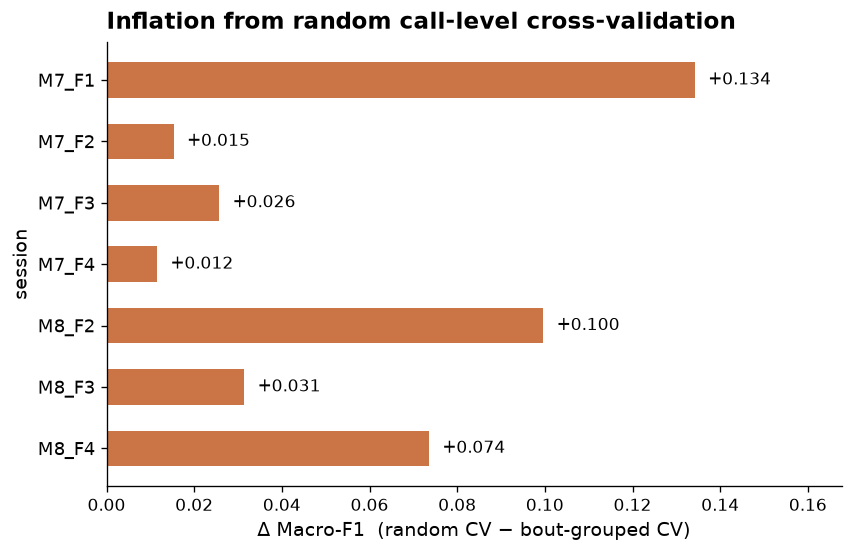

Random-CV Macro-F1 exceeds grouped-CV by +0.056 on average (range +0.012 to +0.134).
Random call-level CV is intentionally invalid here. The positive differences quantify the apparent performance created when related calls from the same bout can enter both training and test folds.


In [224]:
# ================================================================
# A7. Leakage demonstration:
# random call-level CV versus bout-grouped CV
# ================================================================

from sklearn.model_selection import KFold


# ================================================================
# Analysis
# ================================================================

leak_rows = []


for lab in DECODE_SESSIONS:

    Xn, y, tt, gg = call_dataset(
        lab
    )


    grouped = float(
        decode[
            (decode["K"] == K_PRIMARY)
            &
            (decode["session"] == lab)
        ][
            "macro_f1"
        ].iloc[0]
    )


    yt = []
    yp = []


    for tr, te in KFold(
        n_splits=CV_SPLITS,
        shuffle=True,
        random_state=RANDOM_SEED
    ).split(
        Xn
    ):

        if len(
            np.unique(
                y[tr]
            )
        ) < 2:
            continue


        m = clone(
            make_model()
        ).fit(
            Xn[tr],
            y[tr]
        )


        yp.append(
            m.predict(
                Xn[te]
            )
        )

        yt.append(
            y[te]
        )


    random_cv = macro_f1(
        np.concatenate(
            yt
        ),
        np.concatenate(
            yp
        )
    )


    leak_rows.append(
        dict(
            session=lab,
            macro_f1_grouped=grouped,
            macro_f1_random=random_cv,
            inflation=(
                random_cv
                -
                grouped
            )
        )
    )


leakage = pd.DataFrame(
    leak_rows
)


show(
    leakage,
    decimals=3
)


# ================================================================
# Plot the actual quantity of interest:
# artificial Macro-F1 inflation
# ================================================================

plot_leak = (
    leakage
    .set_index(
        "session"
    )
    .reindex(
        DECODE_SESSIONS
    )
    .reset_index()
)


inflation = plot_leak[
    "inflation"
].to_numpy(
    dtype=float
)


sessions_plot = plot_leak[
    "session"
].tolist()


ypos = np.arange(
    len(
        sessions_plot
    )
)


# ================================================================
# Figure
# ================================================================

fig, ax = plt.subplots(
    figsize=(7.0, 4.5),
    constrained_layout=False
)


fig.subplots_adjust(
    left=0.17,
    right=0.95,
    bottom=0.17,
    top=0.87
)


bars = ax.barh(
    ypos,
    inflation,
    height=0.58,
    color=PALETTE["observed"],
    alpha=0.88
)


ax.axvline(
    0,
    color="black",
    linewidth=1.0
)


ax.set_yticks(
    ypos
)


ax.set_yticklabels(
    sessions_plot,
    fontsize=10.5
)


ax.invert_yaxis()


xmax = max(
    0.02,
    inflation.max()
    * 1.25
)


ax.set_xlim(
    0,
    xmax
)


for bar, value in zip(
    bars,
    inflation
):

    ax.text(
        value + xmax * 0.018,
        bar.get_y()
        +
        bar.get_height() / 2,
        f"+{value:.3f}",
        ha="left",
        va="center",
        fontsize=10
    )


ax.set_title(
    "Inflation from random call-level cross-validation",
    loc="left",
    fontsize=14,
    fontweight="bold",
    pad=8
)


ax.set_xlabel(
    r"$\Delta$ Macro-F1  (random CV − bout-grouped CV)",
    fontsize=11.5
)


ax.set_ylabel(
    "session",
    fontsize=11.5
)


ax.tick_params(
    axis="x",
    labelsize=10
)


save_fig(
    fig,
    "grouped_vs_random_cv"
)

plt.show()


# ================================================================
# Notebook interpretation
# ================================================================

print(
    f"Random-CV Macro-F1 exceeds grouped-CV by "
    f"{leakage['inflation'].mean():+.3f} on average "
    f"(range {leakage['inflation'].min():+.3f} to "
    f"{leakage['inflation'].max():+.3f})."
)


print(
    "Random call-level CV is intentionally invalid here. "
    "The positive differences quantify the apparent performance "
    "created when related calls from the same bout can enter both "
    "training and test folds."
)